# Simulation of Wavefront Sensing Method

__Author:__ Wei "Francis" He (francisho@lbl.gov / whorwhey@gmail.com)

Created: Oct 2026 · Last updated: 2026-05-31

Based on earlier work by Xiaoya and Antoine. 

___

## Overview 

__Purpose:__

This notebook is a validation harness for the wavefront reconstruction 
pipeline implemented in `wfs_live.py`. It simulates a soft X-ray beam 
propagating through a binary amplitude grating to a detector, generates 
the resulting interferogram, runs it through the same reconstruction 
code used on real data, and compares the recovered wavefront against 
the known ground truth. 

To demonstrate the functionality of recovering aberrations, a known 
phase aberration is injected at the grating plane and the reconstruction 
is checked against it. The defocus term is recovered through a parabolic 
fit to the wavefront, while higher-order aberrations appear in the 
residual after the defocus is removed. 

__This separation is the core test: 
because the simulation knows the injected aberration exactly, any 
mismatch between the residual and the ground truth localizes an error 
in the pipeline rather than in the measurement.__

__Conventions:__

- All phases in radians; 
- All lengths in meters (SI)

__References:__
- Code adapted from [Xiaoya and Antoine's notebooks](https://github.com/dream-beam/dream-test/blob/main/wavefront_sim/)
- Wojdyla et al., 2018
- Goldberg et al., 2021 & 2023

__Requirements:__
- `monoplus.py` — Fresnel propagation library (`propTF`, `gaussfunc`, 
  `focus`, `polyfunc`, `secondmomt`)
- `wfs_live.py` — wavefront reconstruction pipeline under test

# SETUP

## Import


In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from scipy.signal import find_peaks

In [2]:
# Monoplus library — Fresnel propagation
from monoplus import propTF, gaussfunc, focus, polyfunc, secondmomt

# wfs_live — pipeline under validation
import wfs_live as wfs

# SIMULATION

## Physical Parameters

The simulation operates at a soft X-ray energy of 500 eV (λ ≈ 2.48 nm) 
in a point-source geometry: a small Gaussian source diverges over 2.0 m 
to the grating, then 0.4 m further to the detector.

__Key relationships:__

- Wavelength–energy: $\lambda \,[\text{nm}] = 1239.84 / E\,[\text{eV}]$
- Talbot self-imaging (plane wave): $z_T = p^2 / \lambda$. We fix the 
  detector distance $z_T = 0.4$ m and solve for the pitch, 
  $p = \sqrt{z_T \lambda}$.

__Note on the diverging beam:__ $z_T = p^2/\lambda$ is the *plane-wave* 
Talbot distance. The source here is far past its Rayleigh range at the 
grating ($z_R \approx 91$ mm $\ll z_\text{to grating}$), so the wavefront 
is strongly curved and the plane of maximum fringe contrast shifts to a 
curvature-corrected distance $z_C \neq z_T$ (computed later in 
"Curvature-Corrected Talbot Distance").


In [3]:
# Define Physical Parameters

# Photon energy
energy_eV = 500.0               # Soft X-ray photon energy [eV]

# Propagation geometry
z_to_grating_m = 2.0            # Source to grating [m]
z_T_m = 0.4                     # Grating → detector (plane-wave Talbot) [m]

# Wavelength and grating pitch
wavelength_m    = 1.23984e-6 / energy_eV          # [m]
grating_pitch_m = np.sqrt(z_T_m * wavelength_m)   # pitch from Talbot condition [m]

print(f"Energy:     {energy_eV:.0f} eV")
print(f"Wavelength: {wavelength_m*1e9:.3f} nm\n")
print(f"Geometry:   source → grating (+{z_to_grating_m} m) → detector (+{z_T_m} m)")
print(f"Pitch:      {grating_pitch_m*1e6:.2f} μm")

Energy:     500 eV
Wavelength: 2.480 nm

Geometry:   source → grating (+2.0 m) → detector (+0.4 m)
Pitch:      31.49 μm


In [4]:
# Gaussian source: define width once via the intensity sigma
source_fwhm_m   = 10e-6                                   # source intensity FWHM [m]
source_sigma_m  = source_fwhm_m / (2*np.sqrt(2*np.log(2)))  # intensity sigma [m]
w0_m            = 2 * source_sigma_m                       # field waist (1/e² radius) [m]

print(f"Source FWHM:  {source_fwhm_m*1e6:.1f} μm")
print(f"Source sigma: {source_sigma_m*1e6:.2f} μm (waist w0: {w0_m*1e6:.2f} μm)")


Source FWHM:  10.0 μm
Source sigma: 4.25 μm (waist w0: 8.49 μm)


## Computational Grid

Discretization of the transverse coordinate for FFT-based propagation. 
The grid is chosen to sample the grating finely, illuminate enough periods, 
resolve the carrier in frequency space, and contain the beam footprint.

In [5]:
# Computational grid
M    = 100000                         # number of grid points
L_m  = 2e-3                           # total grid size [m]

dx_m = L_m / M                        # sampling interval [m]
x_m  = np.linspace(-L_m/2, L_m/2, M)  # transverse position array [m]

print(f"Grid size:         {L_m*1e3:.1f} mm")
print(f"Sampling interval: {dx_m*1e6:.3f} μm ({M} points)")

Grid size:         2.0 mm
Sampling interval: 0.020 μm (100000 points)


In [6]:
# Grid verification

# Gaussian propagation: waist, Rayleigh range, beam size at key planes
z_rayleigh_m = np.pi * w0_m**2 / wavelength_m       # Rayleigh range [m]
z_total_m    = z_to_grating_m + z_T_m               # source → detector [m]

w_grating_m          = w0_m * np.sqrt(1 + (z_to_grating_m / z_rayleigh_m)**2)
beam_fwhm_grating_m  = w_grating_m * np.sqrt(2*np.log(2))
w_detector_m         = w0_m * np.sqrt(1 + (z_total_m / z_rayleigh_m)**2)
beam_fwhm_detector_m = w_detector_m * np.sqrt(2*np.log(2))

print(f"Wavelength:                      {wavelength_m*1e9:.3f} nm")
print(f"Rayleigh range:                  {z_rayleigh_m*1e3:.1f} mm")
print(f"Beam FWHM at grating (z={z_to_grating_m} m):  {beam_fwhm_grating_m*1e6:.1f} μm")
print(f"Beam FWHM at detector (z={z_total_m} m): {beam_fwhm_detector_m*1e6:.1f} μm\n")

# Sampling and resolution checks
samples_per_period      = grating_pitch_m / dx_m
n_periods_illuminated   = beam_fwhm_detector_m / grating_pitch_m
df_m                    = 1 / L_m
carrier_freq_m          = 1 / grating_pitch_m
freq_samples_at_carrier = carrier_freq_m / df_m
grid_to_beam_ratio      = L_m / (3 * beam_fwhm_detector_m)

print(f"Samples per grating period:      {samples_per_period:.1f}",
      "  ⚠ need >100" if samples_per_period < 100 else "")
print(f"Grating periods illuminated:     {n_periods_illuminated:.1f}",
      "  ⚠ need >5" if n_periods_illuminated < 5 else "")
print(f"Frequency bins at carrier:       {freq_samples_at_carrier:.1f}",
      "  ⚠ need >10" if freq_samples_at_carrier < 10 else "")
print(f"Grid width vs 3x FWHM_det:       {grid_to_beam_ratio:.2f}",
      "  ⚠ <1 means grid too small at detector" if L_m < 3*beam_fwhm_detector_m else "")

Wavelength:                      2.480 nm
Rayleigh range:                  91.4 mm
Beam FWHM at grating (z=2.0 m):  219.1 μm
Beam FWHM at detector (z=2.4 m): 262.8 μm

Samples per grating period:      1574.7 
Grating periods illuminated:     8.3 
Frequency bins at carrier:       63.5 
Grid width vs 3x FWHM_det:       2.54 


## Source Beam and Propagation

Generate the Gaussian source at $z = 0$ and propagate it to the grating 
plane at $z = 2$ m using the Transfer Function (Fresnel) method. We track 
both intensity and phase, and visualize the full free-space evolution 
from source to grating.

Source beam at z = 0:
  FWHM:  10.0 μm
  Sigma: 4.25 μm


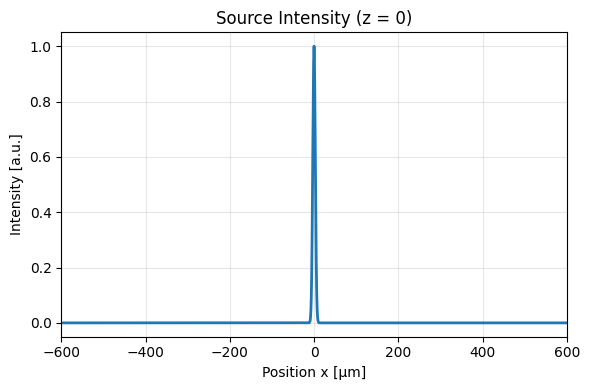

In [7]:
# Gaussian source field at z = 0 (sigma defined in Physical Parameters)
E_source     = gaussfunc(x_m, mean_x=0, sigma_x=source_sigma_m)
I_source     = np.abs(E_source)**2
phase_source = np.angle(E_source)

print(f"Source beam at z = 0:")
print(f"  FWHM:  {source_fwhm_m*1e6:.1f} μm")
print(f"  Sigma: {source_sigma_m*1e6:.2f} μm")

plt.figure(figsize=(6, 4))
plt.plot(x_m*1e6, I_source, lw=2)
plt.xlabel('Position x [μm]')
plt.ylabel('Intensity [a.u.]')
plt.title('Source Intensity (z = 0)')
plt.xlim(-600, 600)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Beam at grating (z = 2.0 m):
  FWHM (expected): 219.1 μm
  Peak intensity:  0.023 a.u.


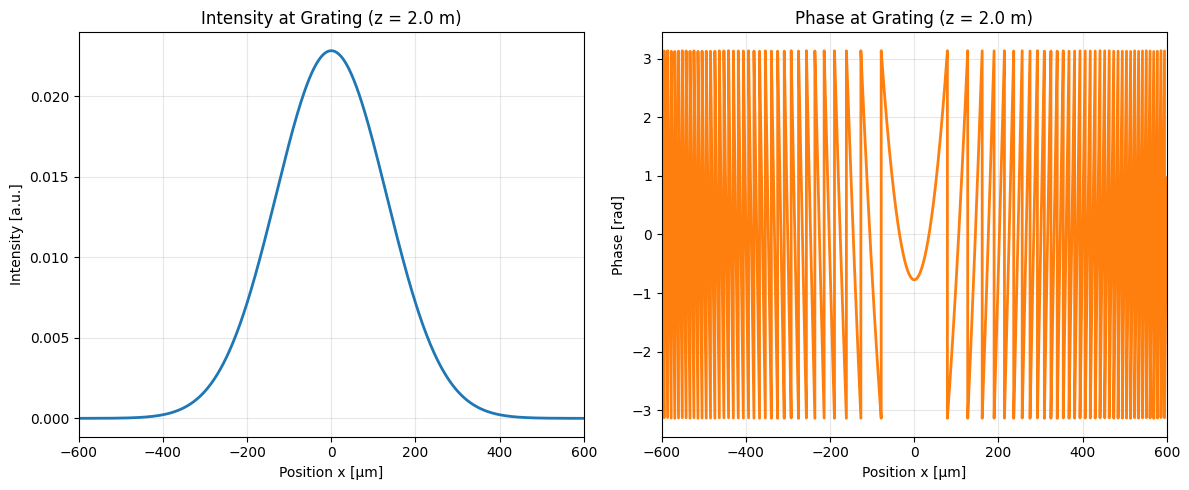

In [8]:
# Propagate source → grating (Transfer Function method)
E_at_grating     = propTF(E_source, L_m, wavelength_m, z_to_grating_m)
I_at_grating     = np.abs(E_at_grating)**2
phase_at_grating = np.angle(E_at_grating)

print(f"Beam at grating (z = {z_to_grating_m} m):")
print(f"  FWHM (expected): {beam_fwhm_grating_m*1e6:.1f} μm")
print(f"  Peak intensity:  {np.max(I_at_grating):.3f} a.u.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_m*1e6, I_at_grating, lw=2)
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel('Intensity [a.u.]')
axes[0].set_title(f'Intensity at Grating (z = {z_to_grating_m} m)')
axes[0].set_xlim(-600, 600)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, phase_at_grating, lw=2, color='C1')
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('Phase [rad]')
axes[1].set_title(f'Phase at Grating (z = {z_to_grating_m} m)')
axes[1].set_xlim(-600, 600)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

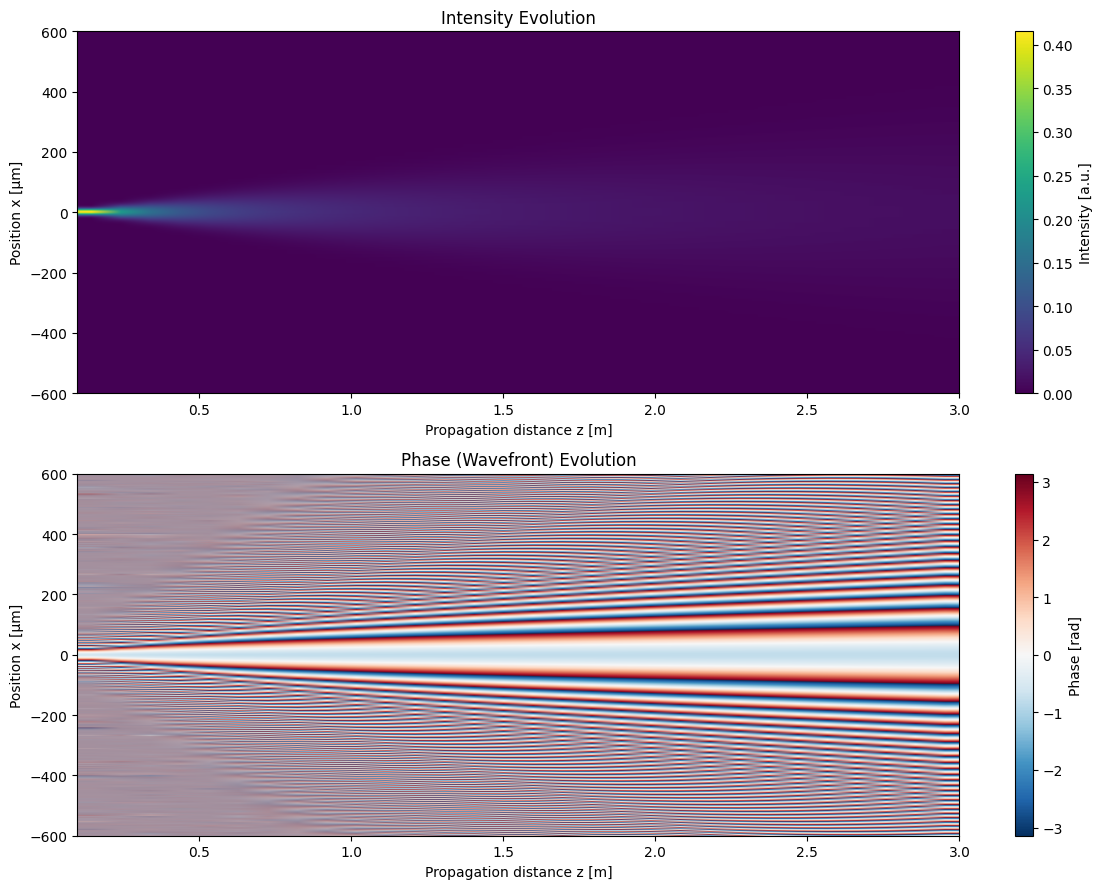

In [9]:
# Free-space evolution, source → grating: propagate to a range of z and
# assemble a 2D map of intensity and phase.
z_array = np.linspace(0.1, 3.0, 30)   # [m]
E_list  = [propTF(E_source, L_m, wavelength_m, z) for z in z_array]

I_matrix     = np.abs(np.array(E_list).T)**2
phase_matrix = np.angle(np.array(E_list).T)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
extent = [z_array[0], z_array[-1], x_m[0]*1e6, x_m[-1]*1e6]

im1 = ax1.imshow(I_matrix, extent=extent, aspect='auto',
                 origin='lower', interpolation='bilinear')
ax1.set_xlabel('Propagation distance z [m]')
ax1.set_ylabel('Position x [μm]')
ax1.set_title('Intensity Evolution')
ax1.set_ylim(-600, 600)
plt.colorbar(im1, ax=ax1, label='Intensity [a.u.]')

im2 = ax2.imshow(phase_matrix, extent=extent, aspect='auto',
                 origin='lower', cmap='RdBu_r',
                 interpolation='bilinear', vmin=-np.pi, vmax=np.pi)
ax2.set_xlabel('Propagation distance z [m]')
ax2.set_ylabel('Position x [μm]')
ax2.set_title('Phase (Wavefront) Evolution')
ax2.set_ylim(-600, 600)
plt.colorbar(im2, ax=ax2, label='Phase [rad]')

plt.tight_layout()
plt.show()

### Ground Truth Wavefront

Compute the reference wavefront against which the reconstruction will be 
compared. We evaluate it at the **detector plane** 
($z = z_\text{to grating} + z_T$), because the practical reconstruction — 
which uses the actual grating pitch $p$ in its formulas — recovers $W(x)$ 
at this plane. Evaluating ground truth and reconstruction on the same 
plane avoids a systematic curvature offset between them.

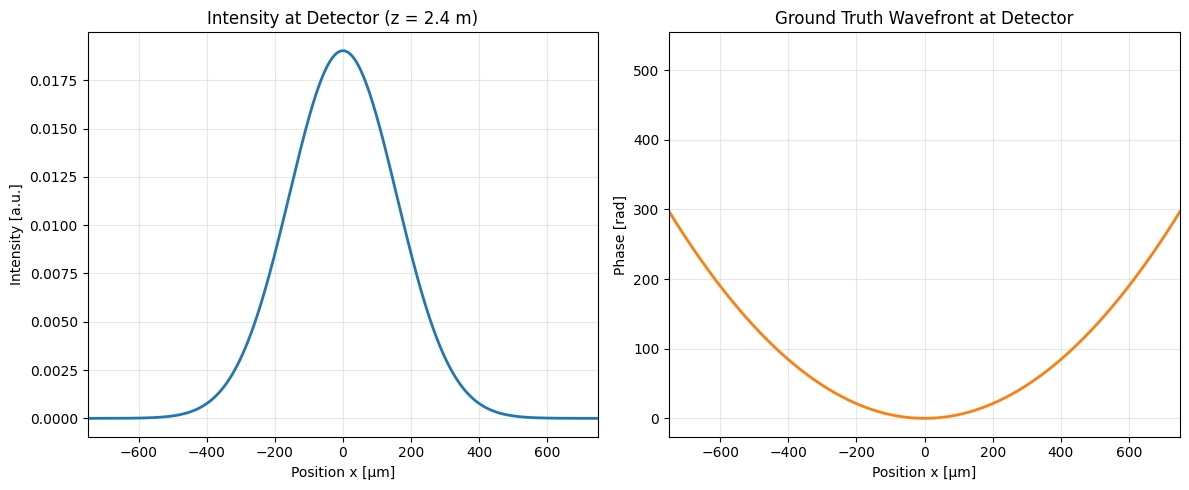

In [10]:
# Ground-truth field and wavefront at the detector plane
E_ground_truth_detector = propTF(E_source, L_m, wavelength_m,
                                 z_to_grating_m + z_T_m)

# Unwrapped, centered phase
phase_gt = np.unwrap(np.angle(E_ground_truth_detector))
phase_ground_truth_centered_detector = phase_gt - phase_gt[M//2]

# Plot intensity and wavefront
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_m*1e6, np.abs(E_ground_truth_detector)**2, lw=2, color='C0')
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel('Intensity [a.u.]')
axes[0].set_title(f'Intensity at Detector (z = {z_to_grating_m + z_T_m:.1f} m)')
axes[0].set_xlim(-750, 750)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, phase_ground_truth_centered_detector, lw=2, color='C1')
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('Phase [rad]')
axes[1].set_title('Ground Truth Wavefront at Detector')
axes[1].set_xlim(-750, 750)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Applying the Shearing Grating

Multiply the field at the grating plane by a binary amplitude grating of 
pitch $p \approx 31.5$ μm. The grating diffracts the beam into multiple 
orders (DC, $\pm 1$, $\pm 3$, …); downstream, the overlapping orders 
produce the interference fringes that encode the wavefront slope.

The pitch was chosen in Physical Parameters so that the grating-to-detector 
distance equals the plane-wave Talbot length, $z_T = p^2 / \lambda = 0.4$ m, 
where fringe contrast is maximized (matching the Wojdyla 2018 geometry).


Grating pitch: 31.49 μm


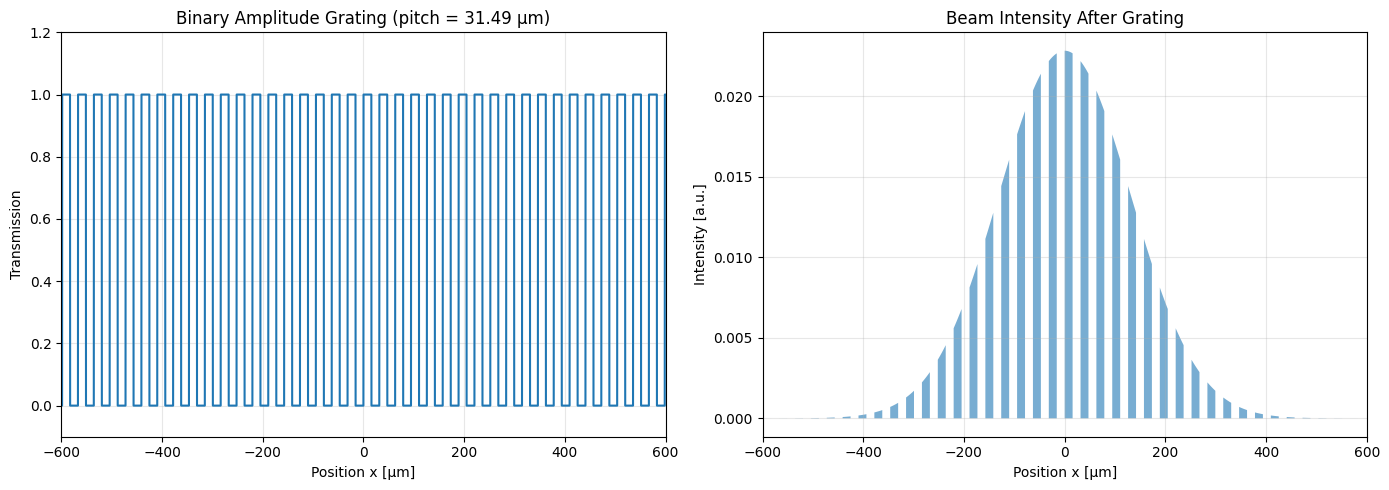

In [11]:
# Binary amplitude grating: transmission alternates 0 / 1 with pitch p
grating_pattern = (np.sign(np.sin(2*np.pi*x_m/grating_pitch_m)) + 1) / 2

# Apply to the field at the grating plane
E_modulated = E_at_grating * grating_pattern
I_modulated = np.abs(E_modulated)**2

print(f"Grating pitch: {grating_pitch_m*1e6:.2f} μm")
# print(f"Samples per period: {grating_pitch_m/dx_m:.1f}")

# Plot: grating pattern (zoomed) and modulated beam intensity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_m*1e6, grating_pattern, lw=1.5)
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel('Transmission')
axes[0].set_title(f'Binary Amplitude Grating (pitch = {grating_pitch_m*1e6:.2f} μm)')
axes[0].set_xlim(-600, 600)
axes[0].set_ylim(-0.1, 1.2)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(x_m*1e6, 0, I_modulated, alpha=0.6)
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('Intensity [a.u.]')
axes[1].set_title('Beam Intensity After Grating')
axes[1].set_xlim(-600, 600)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Fringe Formation and Detection

### Propagation to the Talbot Plane

After the grating, the diffracted orders propagate and overlap, producing 
interference fringes that self-image. For a plane wave this recurs 
periodically at integer multiples of the Talbot distance 
$z_T = p^2/\lambda$. Here the beam is diverging, so the fringes magnify 
as they propagate and the plane of maximum contrast shifts slightly from 
$z_T$ toward a curvature-corrected distance $z_C$. The 2D map below shows 
the first self-image forming near $z_T = 0.4$ m and broadening beyond it.

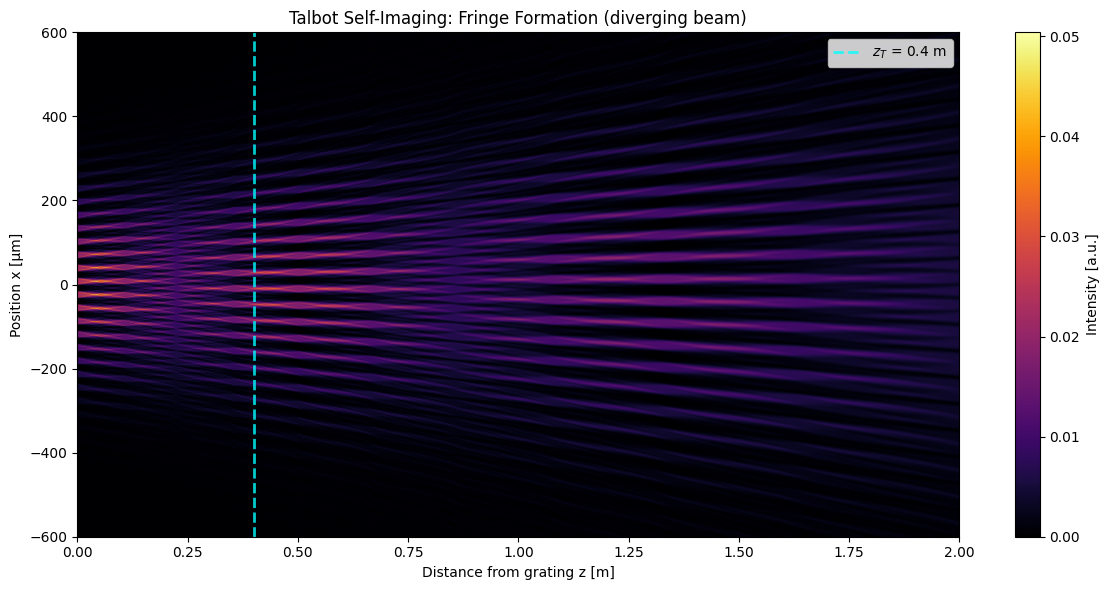

In [12]:
# Propagate the grating-modulated field over several Talbot lengths
n_steps      = 200
z_array_post = np.linspace(0, 5*z_T_m, n_steps)   # 0 → 1.2 m (~3 z_T)
E_list_post  = [propTF(E_modulated, L_m, wavelength_m, z) for z in z_array_post]

I_matrix_post = np.abs(np.array(E_list_post).T)**2

fig, ax = plt.subplots(figsize=(12, 6))
extent = [z_array_post[0], z_array_post[-1], x_m[0]*1e6, x_m[-1]*1e6]

im = ax.imshow(I_matrix_post, extent=extent, aspect='auto',
               origin='lower', cmap='inferno')
ax.set_xlabel('Distance from grating z [m]')
ax.set_ylabel('Position x [μm]')
ax.set_title('Talbot Self-Imaging: Fringe Formation (diverging beam)')
ax.set_ylim(-600, 600)   # zoom to the beam core where fringes are visible

ax.axvline(z_T_m, color='cyan', ls='--', lw=2, alpha=0.8,
           label=f'$z_T$ = {z_T_m} m')
ax.legend(loc='upper right', fontsize=10)

plt.colorbar(im, ax=ax, label='Intensity [a.u.]')
plt.tight_layout()
plt.show()

> **Note — curvature-corrected Talbot distance.** For a diverging beam 
> the curved wavefront shifts the plane of maximum fringe contrast from 
> the plane-wave value $z_T$ to $z_C$, where 
> $1/z_C = 1/z_T - 1/R$ and $R = z\,[1 + (z_R/z)^2]$ is the beam's radius 
> of curvature at the grating ($R > 0$ for a diverging beam, i.e. the 
> distance back to the apparent source). For this geometry 
> $R \approx 2.0$ m gives $z_C \approx 0.50$ m, matching the contrast 
> peak in the curve above. We reconstruct at the hardware-fixed 
> $z_T = 0.4$ m; the $\sim$ 1% contrast penalty (see printout) is negligible.

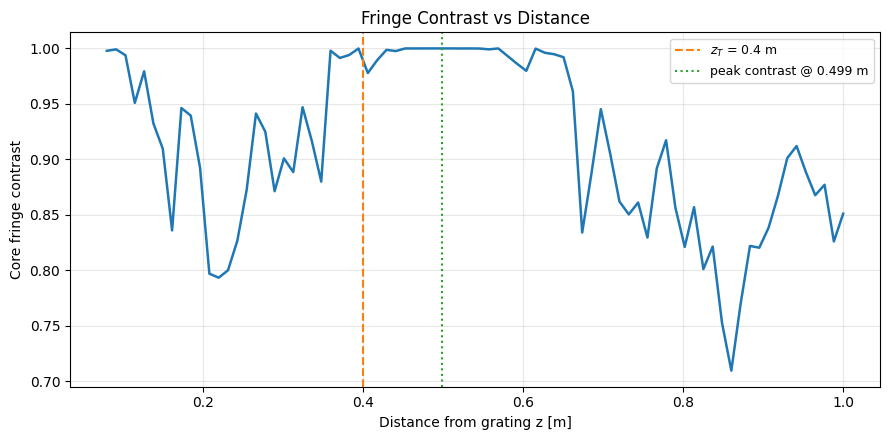

z_T:                 0.4000 m
Peak-contrast plane: 0.4992 m
Contrast at z_T:     0.9999
Peak contrast:       1.0000


In [13]:
# Fringe contrast vs propagation distance — where does contrast peak?
def fringe_contrast(E, half_width_m=100e-6):
    I = np.abs(E)**2
    core = I[np.abs(x_m) < half_width_m]
    return (core.max() - core.min()) / (core.max() + core.min())

z_scan = np.linspace(0.2*z_T_m, 2.5*z_T_m, 80)   # [m]
contrast_scan = np.array([
    fringe_contrast(propTF(E_modulated, L_m, wavelength_m, z)) for z in z_scan
])

z_peak = z_scan[np.argmax(contrast_scan)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z_scan, contrast_scan, lw=1.8)
ax.axvline(z_T_m, color='C1', ls='--', lw=1.5, label=f'$z_T$ = {z_T_m} m')
ax.axvline(z_peak, color='C2', ls=':', lw=1.5,
           label=f'peak contrast @ {z_peak:.3f} m')
ax.set_xlabel('Distance from grating z [m]')
ax.set_ylabel('Core fringe contrast')
ax.set_title('Fringe Contrast vs Distance')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"z_T:                 {z_T_m:.4f} m")
print(f"Peak-contrast plane: {z_peak:.4f} m")
print(f"Contrast at z_T:     {contrast_scan[np.argmin(np.abs(z_scan - z_T_m))]:.4f}")
print(f"Peak contrast:       {contrast_scan.max():.4f}")

Radius of curvature at grating: 2.0042 m
z_T (plane-wave):               0.4000 m
z_C (curvature-corrected):      0.4997 m

Core fringe contrast at z_T: 0.9894
Core fringe contrast at z_C: 1.0000


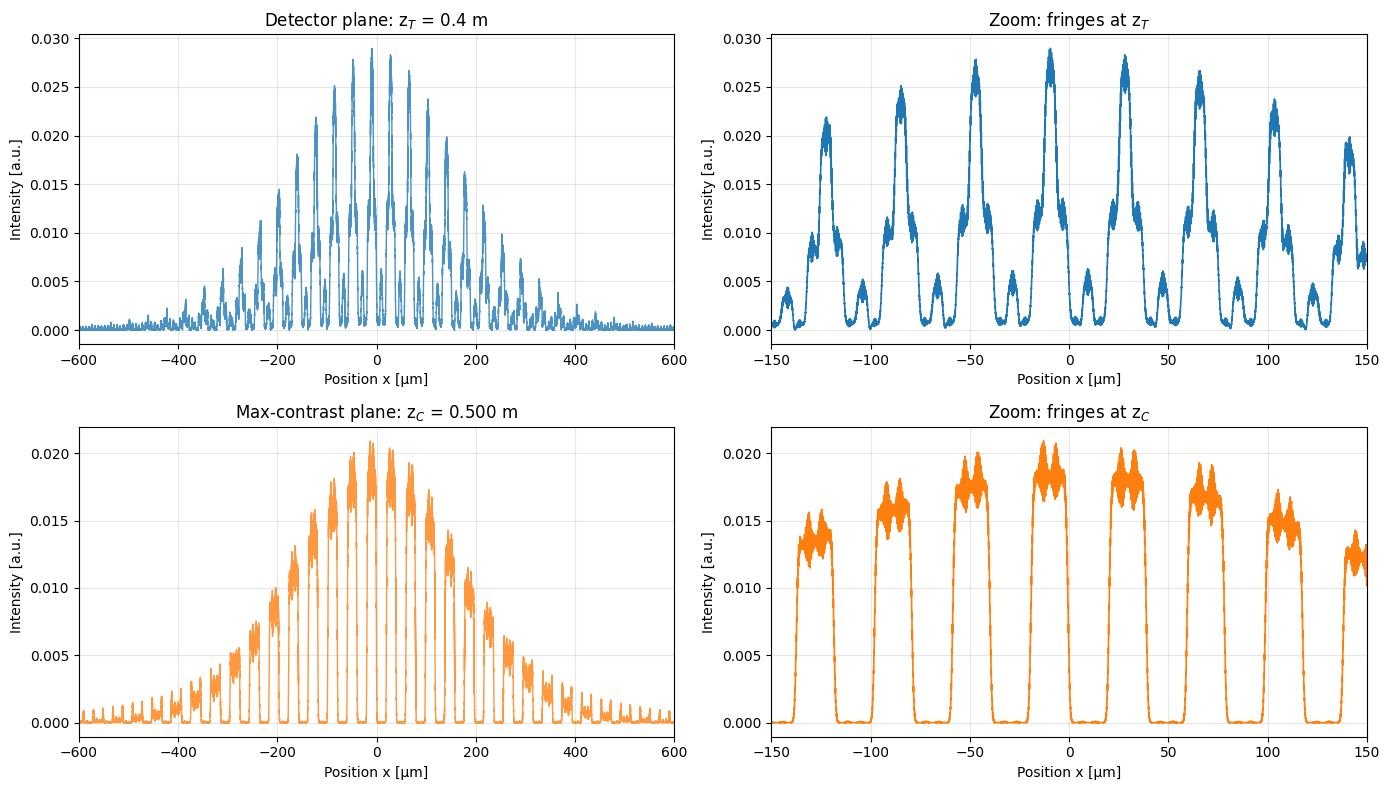

In [14]:
# Curvature-corrected Talbot distance (R > 0 for a diverging beam)
R_at_grating_m = z_to_grating_m * (1 + (z_rayleigh_m / z_to_grating_m)**2)
z_C_m          = 1 / (1/z_T_m - 1/R_at_grating_m)

print(f"Radius of curvature at grating: {R_at_grating_m:.4f} m")
print(f"z_T (plane-wave):               {z_T_m:.4f} m")
print(f"z_C (curvature-corrected):      {z_C_m:.4f} m")

# Interferogram at the detector (z_T) — input to the reconstruction
E_at_z_T = propTF(E_modulated, L_m, wavelength_m, z_T_m)
I_at_z_T = np.abs(E_at_z_T)**2

# Interferogram at z_C — for contrast comparison only
E_at_z_C = propTF(E_modulated, L_m, wavelength_m, z_C_m)
I_at_z_C = np.abs(E_at_z_C)**2

print(f"\nCore fringe contrast at z_T: {fringe_contrast(E_at_z_T):.4f}")
print(f"Core fringe contrast at z_C: {fringe_contrast(E_at_z_C):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top row: z_T (the plane we reconstruct at)
axes[0, 0].plot(x_m*1e6, I_at_z_T, lw=1, alpha=0.8)
axes[0, 0].set_title(f'Detector plane: z$_T$ = {z_T_m} m')
axes[0, 0].set_xlim(-600, 600)

axes[0, 1].plot(x_m*1e6, I_at_z_T, lw=1.2)
axes[0, 1].set_title('Zoom: fringes at z$_T$')
axes[0, 1].set_xlim(-150, 150)

# Bottom row: z_C (maximum contrast)
axes[1, 0].plot(x_m*1e6, I_at_z_C, lw=1, alpha=0.8, color='C1')
axes[1, 0].set_title(f'Max-contrast plane: z$_C$ = {z_C_m:.3f} m')
axes[1, 0].set_xlim(-600, 600)

axes[1, 1].plot(x_m*1e6, I_at_z_C, lw=1.2, color='C1')
axes[1, 1].set_title('Zoom: fringes at z$_C$')
axes[1, 1].set_xlim(-150, 150)

for ax in axes.flat:
    ax.set_xlabel('Position x [μm]')
    ax.set_ylabel('Intensity [a.u.]')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Wavefront Reconstruction

__Goal:__ Extract the wavefront $W(x)$ at the **detector plane** from the interference pattern.

__Physical Principle:__

For lateral shearing interferometry, the measured intensity is:
$$I(x) = I_0(x) + I_1(x) \cos[2\pi f_C x + \Delta\phi(x)]$$
where $f_C = 1/p$ is the carrier frequency set by the grating pitch $p$, and $\Delta\phi(x)$ is the differential phase between the interfering ±1 orders. The differential phase relates to the wavefront slope through the shear distance $s = \lambda z_T / p$ (Momose 2003):
$$\Delta\phi(x) = \frac{\lambda z_T}{p}\,\frac{\partial W}{\partial x} \;\;\Longrightarrow\;\; W(x) = \frac{p}{\lambda z_T}\int \Delta\phi(x)\,dx \quad [\text{rad}]$$

___

__A note on the reconstruction plane:__

We use the **ideal pitch $p$** in the formulas, which recovers $W$ at the **detector plane** (Gaussian curvature + aberrations included). This choice is robust because $p$ is known precisely from fabrication, while the FFT-measured carrier is a noisy peak fit.

**Important:** the carrier ramp to subtract before integration is always $2\pi f_C^\text{ideal} x = 2\pi (1/p)\, x$. The FFT-measured carrier sits slightly off $1/p$ because the diverging-beam curvature shifts it; that shift *is* the wavefront information. Subtracting the *measured* carrier would also remove the linear contribution from the wavefront curvature, leaving $\Delta\phi \approx 0$.

___

__Reconstruction Strategy:__

1. **FFT** $I(x)$ → frequency domain. Locate the +1 order peak (sits near $1/p$).
2. **Bandpass filter**: isolate the +1 order with a Gaussian centered at the detected peak.
3. **IFFT**: angle of the complex result is $2\pi (1/p) x + \Delta\phi(x)$, wrapped.
4. **Unwrap and re-center** at $x = 0$.
5. **Carrier removal**: subtract $2\pi (1/p)\,x$ to isolate $\Delta\phi(x)$.
6. **Integrate** with scaling $p/(\lambda z_T)$ to get $W(x)$ at the detector.

__Underlying math:__

The interference pattern can be written as:
$$ I(x) = I_0(x) + I_1(x)\cos[2\pi (1/p)\, x + \Delta\phi(x)] $$

Filtering the +1 peak of $\mathcal{F}\{I\}$ and inverse-transforming gives a complex envelope:
$$ s(x) = \tfrac{1}{2} I_1(x)\, e^{i\Delta\phi(x)}\, e^{2\pi i (1/p) x} $$
whose angle is the carrier ramp plus the differential phase:
$$ \angle s(x) = 2\pi (1/p)\, x + \Delta\phi(x) $$

The carrier ramp $2\pi (1/p)\, x$ is removed before integration to recover $W(x)$.


Carrier detection:
  Ideal  (1/p):       31.75 cyc/mm
  Measured (+1 peak): 26.50 cyc/mm
  Search band:        [21.2, 47.6] cyc/mm


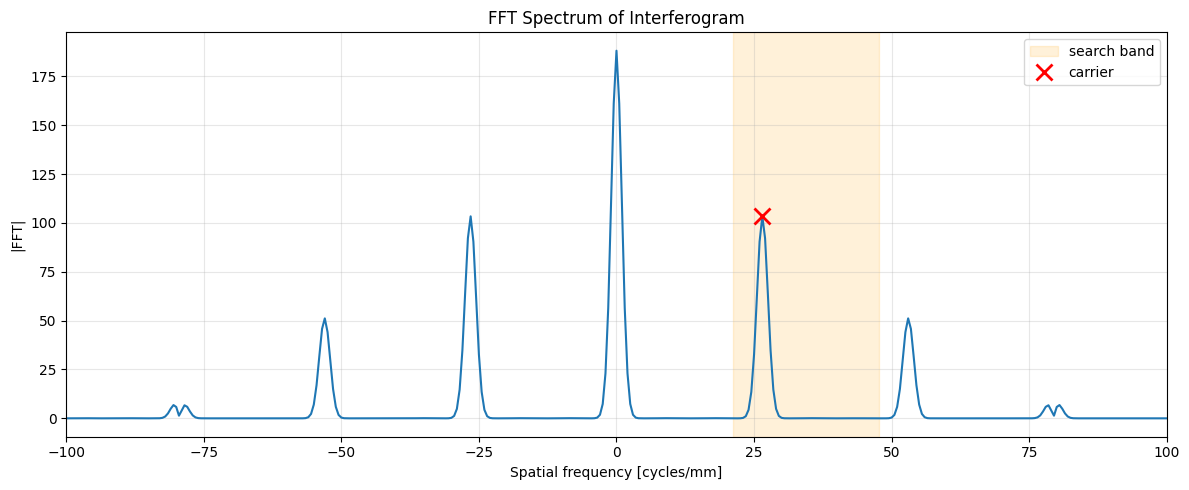

In [15]:
# FFT of the interferogram
fft_avg = np.fft.fftshift(np.fft.fft(I_at_z_T))
freq    = np.fft.fftshift(np.fft.fftfreq(M, dx_m))   # [cyc/m]

# Carrier detection: argmax over a band around 1/p (matches wfs_live.find_carrier)
k_ideal     = 1.0 / grating_pitch_m
band_factor = 1.5
band_lo, band_hi = k_ideal / band_factor, k_ideal * band_factor
search_mask = (freq >= band_lo) & (freq <= band_hi)

carrier_idx           = np.argmax(np.abs(fft_avg) * search_mask)
carrier_freq_measured = freq[carrier_idx]

print("Carrier detection:")
print(f"  Ideal  (1/p):       {k_ideal*1e-3:.2f} cyc/mm")
print(f"  Measured (+1 peak): {carrier_freq_measured*1e-3:.2f} cyc/mm")
print(f"  Search band:        [{band_lo*1e-3:.1f}, {band_hi*1e-3:.1f}] cyc/mm")

# Spectrum
plt.figure(figsize=(12, 5))
plt.plot(freq*1e-3, np.abs(fft_avg), lw=1.5)
plt.axvspan(band_lo*1e-3, band_hi*1e-3, color='orange', alpha=0.15, label='search band')
plt.plot(carrier_freq_measured*1e-3, np.abs(fft_avg[carrier_idx]),
         'rx', ms=12, mew=2, label='carrier')
plt.xlabel('Spatial frequency [cycles/mm]')
plt.ylabel('|FFT|')
plt.title('FFT Spectrum of Interferogram')
plt.xlim(-100, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

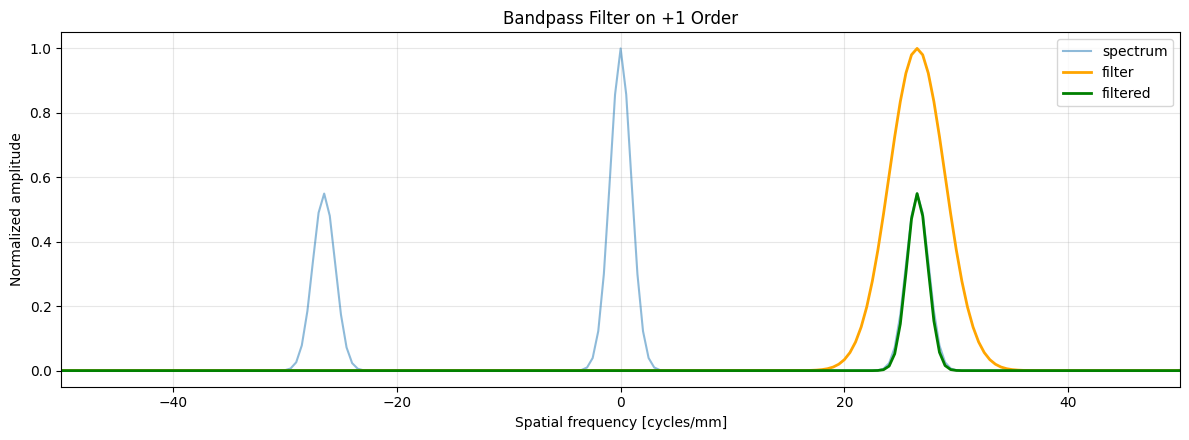

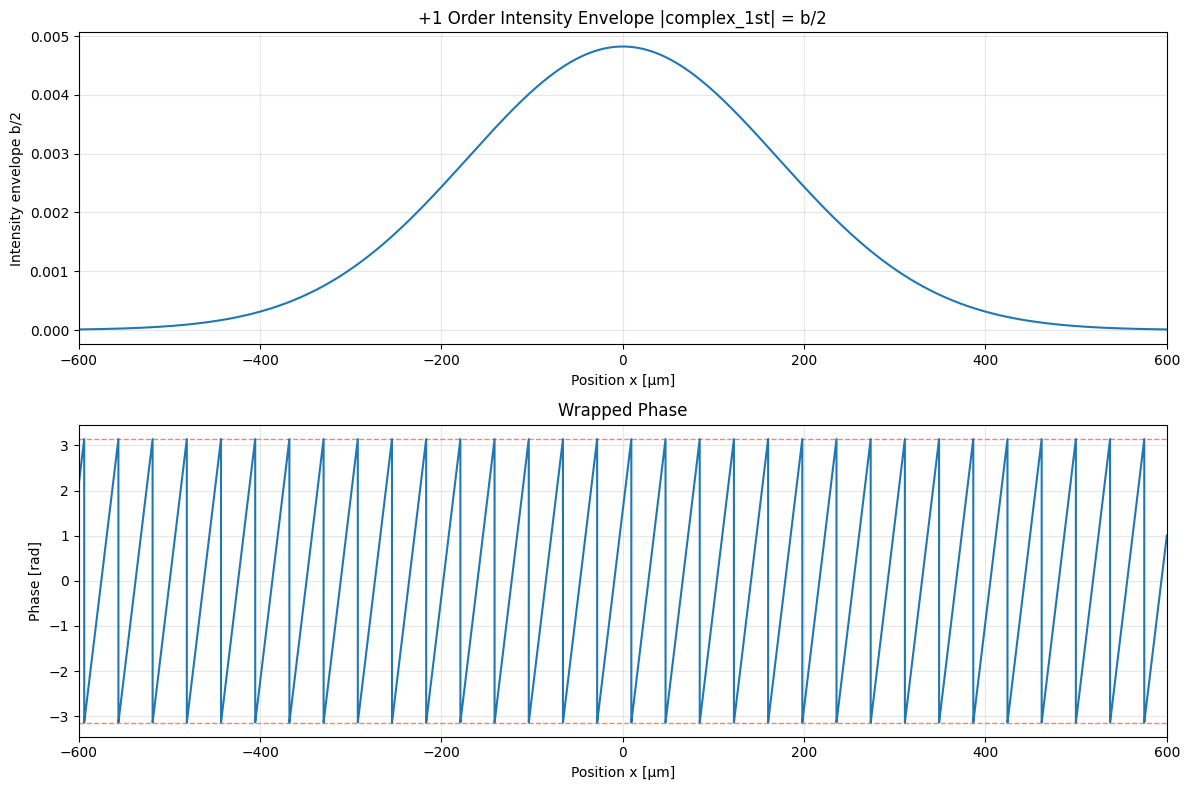

In [16]:
# Bandpass filter on the +1 order, centered at the measured carrier
filter_width_bins = 5.0                       # Gaussian sigma [bins]
bins              = np.arange(M)
gaussian_filter   = np.exp(-0.5 * ((bins - carrier_idx) / filter_width_bins)**2)
fft_filtered      = fft_avg * gaussian_filter

# Show the filter on the spectrum
fft_mag_norm  = np.abs(fft_avg) / np.abs(fft_avg).max()
fft_filt_norm = np.abs(fft_filtered) / np.abs(fft_avg).max()

plt.figure(figsize=(12, 4.5))
plt.plot(freq*1e-3, fft_mag_norm,  alpha=0.5, label='spectrum')
plt.plot(freq*1e-3, gaussian_filter, color='orange', lw=2, label='filter')
plt.plot(freq*1e-3, fft_filt_norm, color='green', lw=2, label='filtered')
plt.xlabel('Spatial frequency [cycles/mm]')
plt.ylabel('Normalized amplitude')
plt.title('Bandpass Filter on +1 Order')
plt.xlim(-50, 50)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# IFFT → complex field; extract amplitude and wrapped phase
complex_field = np.fft.ifft(np.fft.ifftshift(fft_filtered))
amplitude     = np.abs(complex_field)         # = b/2, intensity envelope (NOT a field amplitude)
phase_wrapped = np.angle(complex_field)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(x_m*1e6, amplitude, lw=1.5)
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel('Intensity envelope b/2')
axes[0].set_title('+1 Order Intensity Envelope |complex_1st| = b/2')
axes[0].set_xlim(-600, 600)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, phase_wrapped, lw=1.5)
axes[1].axhline(np.pi,  color='r', ls='--', alpha=0.5, lw=1)
axes[1].axhline(-np.pi, color='r', ls='--', alpha=0.5, lw=1)
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('Phase [rad]')
axes[1].set_title('Wrapped Phase')
axes[1].set_xlim(-600, 600)
axes[1].set_ylim(-np.pi*1.1, np.pi*1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Note — unwrapping and choice of phase center.** The complex field's 
> phase is wrapped to $[-\pi, \pi)$. We unwrap it with `np.unwrap` 
> (left-to-right), then subtract the unwrapped value at a chosen 
> reference pixel so the centered phase is zero there.
>
> The reference is **not** the array midpoint but the **beam centroid** 
> $x_c$, following `wfs_live`. We extract the 0th-order envelope 
> $I_0(x)$ (the intensity envelope $a(x)$ of the interferogram) by 
> low-pass filtering the FFT around DC, build a beam mask at 
> $I_0 > e^{-2}\,\max I_0$ (the $1/e^2$ intensity radius), and take 
> the centroid weighted by $A_1$ inside that mask. Referencing the 
> wavefront to the beam — rather than to a fixed detector pixel — 
> removes a spurious tilt when the beam is off-center, which matters 
> once an off-axis aberration is injected. For this on-axis test 
> $x_c$ sits essentially at the midpoint, but we use the same method 
> throughout.

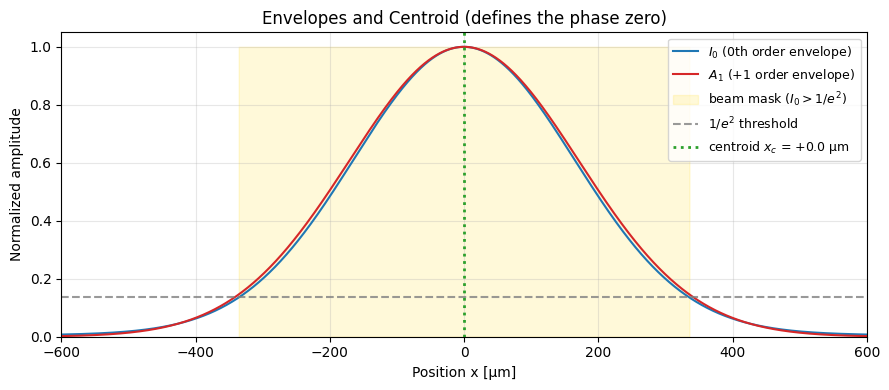

Beam centroid x_c: pixel 50000  (x = +0.0 μm)
Array midpoint:    pixel 50000  (x = +0.0 μm)


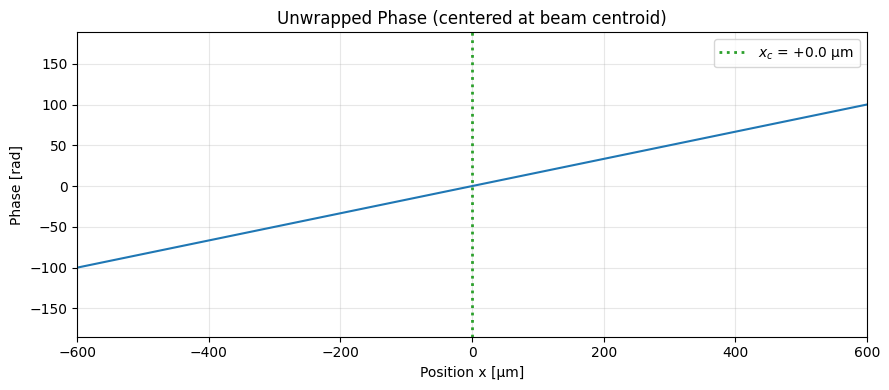

In [17]:
# --- 0th-order envelope I_0(x): low-pass the FFT around DC ---
# (the +1-order envelope A_1 = |complex_field| was found in the IFFT cell)
sigma_0_bins = filter_width_bins * 2        # wider than the +1 bandpass
lowpass      = np.exp(-0.5 * (bins - M//2)**2 / sigma_0_bins**2)  # centered at f=0
complex_0th  = np.fft.ifft(np.fft.ifftshift(fft_avg * lowpass))
I0           = np.abs(complex_0th)          # intensity envelope a(x), linear (post May 2026 rename)
A1           = amplitude                    # |+1-order| = b/2, intensity envelope of the fringes

# --- Beam centroid x_c: A1-weighted, inside the I0 > 1/e² mask ---
# A1 (not A1**2) — weighting by intensity gives the standard intensity-weighted centroid.
threshold = np.exp(-2)
beam_mask = I0 > threshold * I0.max()        # 1/e² of the linear intensity envelope
x_idx     = np.arange(M)
x_c       = int(np.average(x_idx[beam_mask], weights=A1[beam_mask]))

# --- Show the envelopes and how the centroid is found ---
I0_norm = I0 / I0.max()
A1_norm = A1 / A1.max()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_m*1e6, I0_norm, 'C0', lw=1.5, label=r'$I_0$ (0th order envelope)')
ax.plot(x_m*1e6, A1_norm, 'C3', lw=1.5, label=r'$A_1$ (+1 order envelope)')

# 1/e² mask region used for the centroid
ax.fill_between(x_m*1e6, 0, 1, where=beam_mask, color='gold', alpha=0.15,
                label=r'beam mask ($I_0 > 1/e^2$)')
ax.axhline(threshold, color='gray', ls='--', lw=1.5, alpha=0.8,
           label=r'$1/e^2$ threshold')

# Centroid line
ax.axvline(x_m[x_c]*1e6, color='C2', ls=':', lw=2,
           label=f'centroid $x_c$ = {x_m[x_c]*1e6:+.1f} μm')

ax.set_xlabel('Position x [μm]')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Envelopes and Centroid (defines the phase zero)')
ax.set_xlim(-600, 600)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Beam centroid x_c: pixel {x_c}  (x = {x_m[x_c]*1e6:+.1f} μm)")
print(f"Array midpoint:    pixel {M//2}  (x = {x_m[M//2]*1e6:+.1f} μm)")

# --- Unwrap and center at x_c ---
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered  = phase_unwrapped - phase_unwrapped[x_c]

plt.figure(figsize=(9, 4))
plt.plot(x_m*1e6, phase_centered, lw=1.5)
plt.axvline(x_m[x_c]*1e6, color='C2', ls=':', lw=2,
            label=f'$x_c$ = {x_m[x_c]*1e6:+.1f} μm')
plt.xlabel('Position x [μm]')
plt.ylabel('Phase [rad]')
plt.title('Unwrapped Phase (centered at beam centroid)')
plt.xlim(-600, 600)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Note — carrier removal and integration.** The centered phase is 
> $2\pi(1/p)\,x + \Delta\phi(x)$: the grating carrier ramp plus the 
> wavefront-slope differential phase. We subtract the **ideal** carrier 
> ramp $2\pi(1/p)\,(x - x_{c})$ — using the fabrication pitch $p$, *not* 
> the FFT-measured frequency — to isolate $\Delta\phi(x)$, then integrate 
> with the scaling $p/(\lambda z_T)$:
> $$W(x) = \frac{p}{\lambda z_T}\int \Delta\phi(x)\,dx \quad [\text{rad}].$$
> The ramp is referenced to $x_c$ (the same beam centroid used for 
> centering), and $W(x)$ is re-centered at $x_c$ afterward to remove the 
> integration constant (piston). The full derivation is in the 
> reconstruction note above.

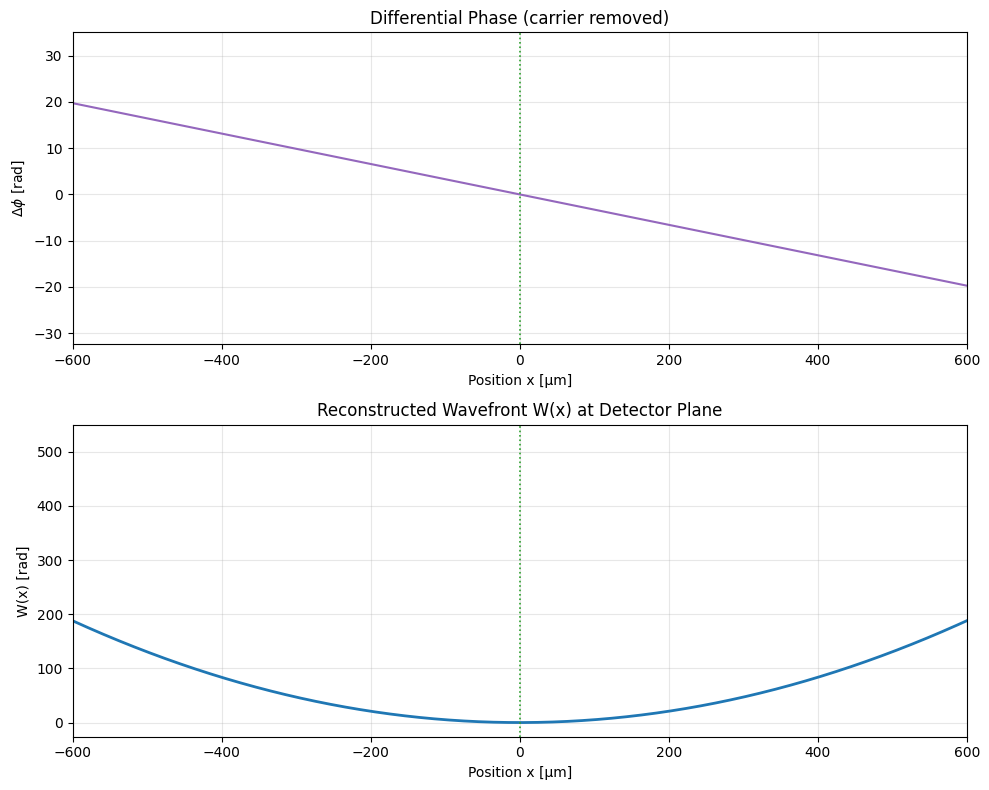

In [18]:
# Step 1: remove the ideal carrier ramp (2π/p · x), referenced to x_c.
# Using the FFT-measured frequency here would zero out the wavefront curvature.
carrier_ramp = 2*np.pi * (1/grating_pitch_m) * x_m
carrier_ramp = carrier_ramp - carrier_ramp[x_c]      # reference to centroid
delta_phi    = phase_centered - carrier_ramp

# Step 2: integrate to get W(x) at the detector plane
#   W(x) = (p / λ z_T) ∫ Δφ dx   [rad]
wavefront_temp = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T_m

# Step 3: re-center at x_c to remove the integration constant (piston)
wavefront_reconstructed = wavefront_temp - wavefront_temp[x_c]

# Plot Δφ and the reconstructed wavefront
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(x_m*1e6, delta_phi, lw=1.5, color='C4')
axes[0].axvline(x_m[x_c]*1e6, color='C2', ls=':', lw=1.2)
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel(r'$\Delta\phi$ [rad]')
axes[0].set_title('Differential Phase (carrier removed)')
axes[0].set_xlim(-600, 600)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, wavefront_reconstructed, lw=2)
axes[1].axvline(x_m[x_c]*1e6, color='C2', ls=':', lw=1.2)
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('W(x) [rad]')
axes[1].set_title('Reconstructed Wavefront W(x) at Detector Plane')
axes[1].set_xlim(-600, 600)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Reconstruction, defocus-removed (real-data convention):
  Defocus coeff:               2.0609e+08 nm/m²
  Focal-length magnitude |f|:  2.4262 m
  Residual RMS (non-defocus):  0.0001 nm


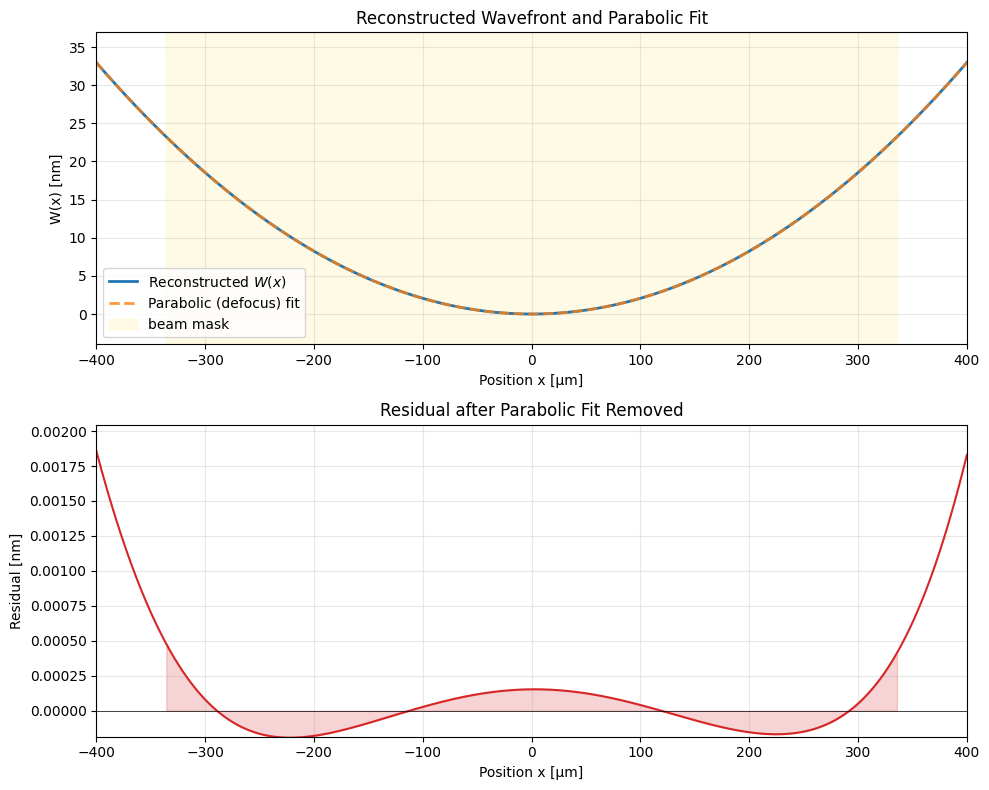

In [19]:
# Reconstructed wavefront in nm (OPL): W_OPL = W_rad · λ/(2π)
to_nm      = wavelength_m / (2*np.pi) * 1e9
W_recon_nm = wavefront_reconstructed * to_nm

# Parabolic (defocus) fit over the beam mask. x_m in meters → coeff in nm/m².
xm_mask      = x_m[beam_mask]
p_recon      = np.polyfit(xm_mask, W_recon_nm[beam_mask], 2)
fit_recon_nm = np.polyval(p_recon, x_m)

resid_recon_nm = W_recon_nm - fit_recon_nm
rms_recon      = np.sqrt(np.mean(resid_recon_nm[beam_mask]**2))

# Focal-length magnitude from the defocus coeff: W_nm = 1e9·x²/(2f) ⇒ f = 1e9/(2a)
f_mag_m = abs(1e9 / (2 * p_recon[0])) if p_recon[0] != 0 else np.inf

print("Reconstruction, defocus-removed (real-data convention):")
print(f"  Defocus coeff:               {p_recon[0]:.4e} nm/m²")
print(f"  Focal-length magnitude |f|:  {f_mag_m:.4f} m")
print(f"  Residual RMS (non-defocus):  {rms_recon:.4f} nm")

x_view = 400e-6
view   = np.abs(x_m) < x_view

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top: reconstruction with its parabolic fit
axes[0].plot(x_m*1e6, W_recon_nm,   lw=2, label='Reconstructed $W(x)$')
axes[0].plot(x_m*1e6, fit_recon_nm, lw=2, ls='--', alpha=0.8, label='Parabolic (defocus) fit')
axes[0].axvspan(xm_mask[0]*1e6, xm_mask[-1]*1e6, color='gold', alpha=0.1, label='beam mask')
axes[0].set_xlabel('Position x [μm]')
axes[0].set_ylabel('W(x) [nm]')
axes[0].set_title('Reconstructed Wavefront and Parabolic Fit')
axes[0].set_xlim(-x_view*1e6, x_view*1e6)
w_hi, w_lo = W_recon_nm[view].max(), W_recon_nm[view].min()
axes[0].set_ylim(w_lo - 0.12*(w_hi-w_lo), w_hi + 0.12*(w_hi-w_lo))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Bottom: defocus-removed residual
axes[1].plot(x_m*1e6, resid_recon_nm, lw=1.5, color='C3')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].fill_between(x_m*1e6, 0, resid_recon_nm, where=beam_mask, alpha=0.2, color='C3')
axes[1].set_xlabel('Position x [μm]')
axes[1].set_ylabel('Residual [nm]')
axes[1].set_title(f'Residual after Parabolic Fit Removed')
axes[1].set_xlim(-x_view*1e6, x_view*1e6)
r_max = np.abs(resid_recon_nm[view]).max()
axes[1].set_ylim(-0.1*r_max, 1.1*r_max)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Validation vs ground truth:
  Raw residual RMS:           0.1094 nm
  Defocus coeff recon / GT:   2.0609e+08 / 2.0825e+08 nm/m²
  Defocus coeff ratio:        0.9896
  Defocus-removed RMS recon:  0.0001 nm
  Defocus-removed RMS GT:     0.0000 nm


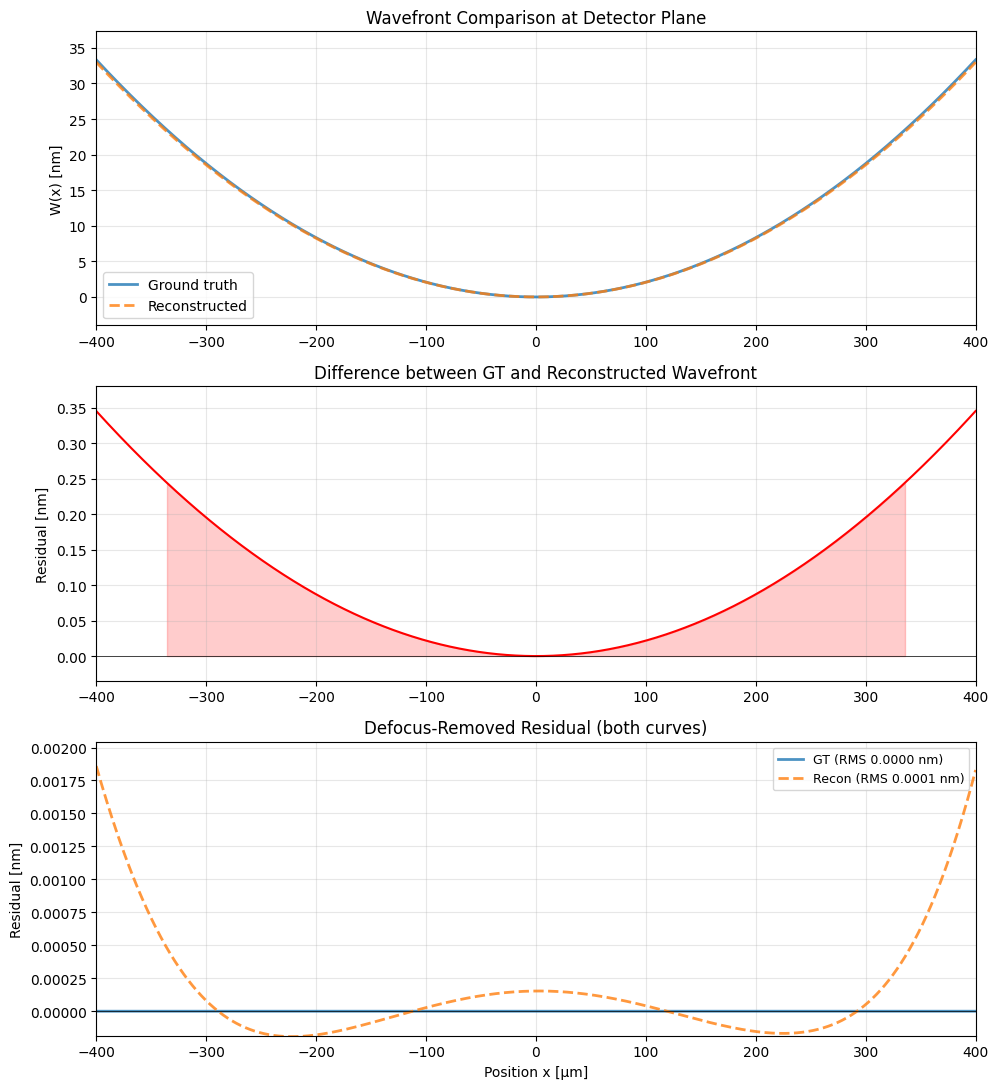

In [20]:
# Depends on to_nm, W_recon_nm, p_recon, fit_recon_nm, xm_mask from the previous cell.
W_gt_nm = (phase_ground_truth_centered_detector
           - phase_ground_truth_centered_detector[x_c]) * to_nm

# Raw residual
residual_nm = W_gt_nm - W_recon_nm
rms_raw     = np.sqrt(np.mean(residual_nm[beam_mask]**2))

# Defocus-removed: fit & subtract a parabola from each (over the mask)
p_gt           = np.polyfit(xm_mask, W_gt_nm[beam_mask], 2)
fit_gt_nm      = np.polyval(p_gt, x_m)
resid_gt_dr    = W_gt_nm    - fit_gt_nm
resid_recon_dr = W_recon_nm - fit_recon_nm
rms_gt_dr      = np.sqrt(np.mean(resid_gt_dr[beam_mask]**2))
rms_recon_dr   = np.sqrt(np.mean(resid_recon_dr[beam_mask]**2))

print("Validation vs ground truth:")
print(f"  Raw residual RMS:           {rms_raw:.4f} nm")
print(f"  Defocus coeff recon / GT:   {p_recon[0]:.4e} / {p_gt[0]:.4e} nm/m²")
print(f"  Defocus coeff ratio:        {p_recon[0]/p_gt[0]:.4f}")
print(f"  Defocus-removed RMS recon:  {rms_recon_dr:.4f} nm")
print(f"  Defocus-removed RMS GT:     {rms_gt_dr:.4f} nm")

x_view = 400e-6
view   = np.abs(x_m) < x_view

fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# (1) Overlay
axes[0].plot(x_m*1e6, W_gt_nm,    lw=2, alpha=0.8, label='Ground truth')
axes[0].plot(x_m*1e6, W_recon_nm, lw=2, ls='--', alpha=0.8, label='Reconstructed')
axes[0].set_ylabel('W(x) [nm]')
axes[0].set_title('Wavefront Comparison at Detector Plane')
axes[0].set_xlim(-x_view*1e6, x_view*1e6)
w_hi, w_lo = W_gt_nm[view].max(), W_gt_nm[view].min()
axes[0].set_ylim(w_lo - 0.12*(w_hi-w_lo), w_hi + 0.12*(w_hi-w_lo))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# (2) Raw residual
axes[1].plot(x_m*1e6, residual_nm, lw=1.5, color='red')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].fill_between(x_m*1e6, 0, residual_nm, where=beam_mask, alpha=0.2, color='red')
axes[1].set_ylabel('Residual [nm]')
axes[1].set_title(f'Difference between GT and Reconstructed Wavefront')
axes[1].set_xlim(-x_view*1e6, x_view*1e6)
r_max = np.abs(residual_nm[view]).max()
axes[1].set_ylim(-0.1*r_max, 1.1*r_max)
axes[1].grid(True, alpha=0.3)

# (3) Defocus-removed, both
axes[2].plot(x_m*1e6, resid_gt_dr,    lw=2, alpha=0.8, label=f'GT (RMS {rms_gt_dr:.4f} nm)')
axes[2].plot(x_m*1e6, resid_recon_dr, lw=2, ls='--', alpha=0.8, label=f'Recon (RMS {rms_recon_dr:.4f} nm)')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_xlabel('Position x [μm]')
axes[2].set_ylabel('Residual [nm]')
axes[2].set_title('Defocus-Removed Residual (both curves)')
axes[2].set_xlim(-x_view*1e6, x_view*1e6)
rr = max(np.abs(resid_gt_dr[view]).max(), np.abs(resid_recon_dr[view]).max())
axes[2].set_ylim(-0.1*rr, 1.1*rr)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Note — two ways to assess the reconstruction.**
>
> **(a) Real-data convention.** Fit a parabola to the reconstructed $W(x)$ 
> over the beam mask and subtract it; the residual is the non-defocus 
> aberration content. This is all we can measure on real data, where 
> defocus is a bender set-point (not an optic aberration) and there is no 
> ground truth. Matches the "defocus removed" metric of Wojdyla 2018 and 
> Goldberg 2023.
>
> **(b) Validation against ground truth (simulation only).** Compare 
> reconstruction and known truth directly: overlay, raw residual, and 
> parabolic-fit-removed residual. The raw residual carries a small (~1%) 
> systematic in the *absolute* defocus coefficient — a curvature-scale 
> effect of the diverging beam on the $p/(\lambda z_T)$ scaling (its size 
> is the "defocus coeff ratio" printed above). It is purely quadratic, so 
> it cancels under parabola removal and does not affect focus-finding, 
> which is shape-driven.

### Caustic: Propagating to the Focus

With the wavefront $W(x)$ reconstructed at the detector, we build the 
complex field $E(x) = A(x)\,e^{iW(x)}$ and Fresnel-propagate it over a 
range of $z$ to locate the focus — the plane where the RMS beam size 
$\sigma_\text{rms}(z)$ is minimum. The detector is at $z = 0$, so the 
focus of this diverging beam lies upstream at 
$z \approx -(z_\text{to grating} + z_T) = -2.4$ m.

**Choice of amplitude $A(x)$.** The phase sets *where* the focus lands; 
the amplitude sets the *shape* of the converging beam and hence the 
quality of the $\sigma_\text{rms}$ minimum. We compare two options:

- $A = \sqrt{I_0}$ — the **field envelope** $\sqrt{a(x)}$ of the beam, 
  from the 0th-order intensity envelope $I_0 = a(x)$. Default choice: 
  it is the physical beam, tapers softly on its own, and is not 
  contrast-weighted.
- $A = \sqrt{I_0}\cdot \mathbb{1}_{V > V_\text{thr}}$ — the field 
  envelope restricted to the region of high fringe visibility, with 
  interior gaps filled. Useful for real data where fringes are only 
  meaningful over a subset of the beam; the hard edge introduces some 
  diffraction (visible in the caustic) but ensures only the trustworthy 
  region contributes to the focus measurement.

For this clean simulation both give the same focus position to within the 
$z$-step ($-2.421$ m, $0.9$% from the expected $-2.4$ m); the gated 
version has a larger $\sigma_\text{focus}$ due to edge diffraction. The 
position agreement is the validation: amplitude choice does not bias 
$z_\text{focus}$, only $\sigma_\text{focus}$.

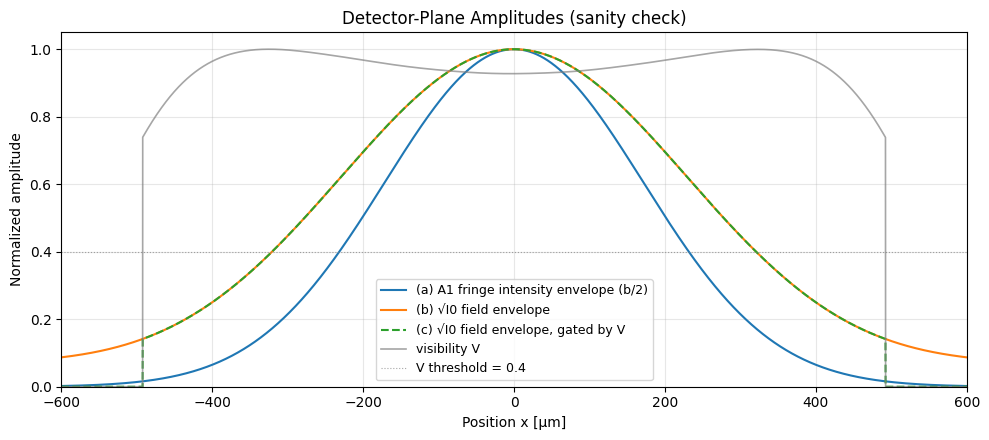

In [21]:
# --- Three amplitude choices for the detector-plane field ---
A_fringe = amplitude                          # (a) A1 = b/2 — fringe intensity envelope (NOT a field amplitude); kept for comparison
A_sqrtI0 = np.sqrt(I0)                        # (b) √I0 = √a — field envelope of the beam (physically correct field amplitude)

threshold = 0.02
beam_mask = I0 > threshold * I0.max()

# Visibility V = b/a = 2·A1/I0 — dimensionless, normalized to peak within beam mask
V          = np.zeros_like(I0)
V[beam_mask] = (2 * A1[beam_mask]) / I0[beam_mask]
V         /= V[beam_mask].max()

# Trust region: V above threshold, with interior dips filled so the
# beam core is included (the central V dip is a sampling artifact, not
# a real loss of contrast).
def fill_mask_gaps(mask):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return mask.copy()
    i_first = np.argmax(mask)
    i_last  = len(mask) - 1 - np.argmax(mask[::-1])
    filled = mask.copy()
    filled[i_first:i_last + 1] = True
    return filled

V_threshold = 0.4
trust_mask  = fill_mask_gaps(V > V_threshold)
A_real      = np.sqrt(I0) * trust_mask        # (c) field envelope × trust mask — masks low-contrast regions

# Sanity check: the candidate detector-plane amplitudes
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(x_m*1e6, A_fringe / A_fringe.max(), lw=1.5, label='(a) A1 fringe intensity envelope (b/2)')
ax.plot(x_m*1e6, A_sqrtI0 / A_sqrtI0.max(), lw=1.5, label='(b) √I0 field envelope')
ax.plot(x_m*1e6, A_real   / A_real.max(),   lw=1.5, ls='--', label='(c) √I0 field envelope, gated by V')
ax.plot(x_m*1e6, V,                          lw=1.2, color='gray', alpha=0.7, label='visibility V')
ax.axhline(V_threshold, color='gray', ls=':', lw=0.8, alpha=0.7,
           label=f'V threshold = {V_threshold}')

ax.set_xlabel('Position x [μm]')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Detector-Plane Amplitudes (sanity check)')
ax.set_xlim(-600, 600)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

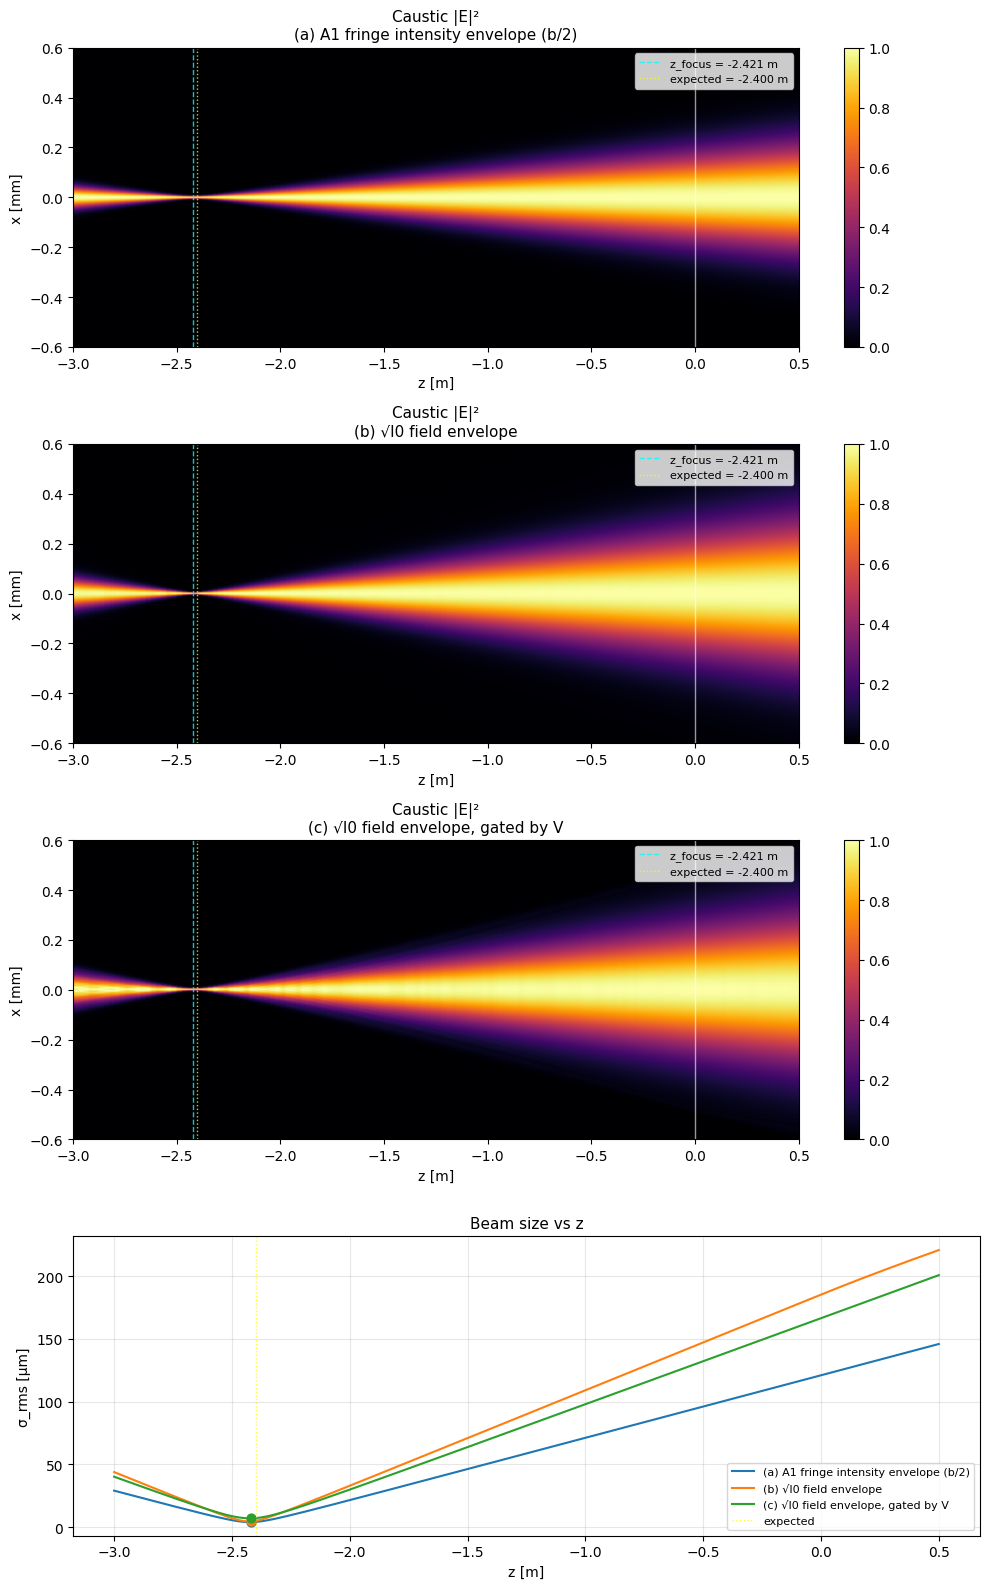

Expected focus: -2.400 m

(a) A1 fringe intensity envelope (b/2)
  z_focus = -2.421 m  (error -20.9 mm, +0.87%)
  σ_focus = 3.96 µm

(b) √I0 field envelope
  z_focus = -2.421 m  (error -20.9 mm, +0.87%)
  σ_focus = 4.50 µm

(c) √I0 field envelope, gated by V
  z_focus = -2.421 m  (error -20.9 mm, +0.87%)
  σ_focus = 6.97 µm



In [22]:
amp_options = {
    '(a) A1 fringe intensity envelope (b/2)': A_fringe,
    '(b) √I0 field envelope'                : A_sqrtI0,
    '(c) √I0 field envelope, gated by V'    : A_real,
}                          

# --- Backward sweep for each amplitude choice ---
z_range_m  = np.linspace(-3.0, 0.5, 140)
Z          = len(z_range_m)
z_expected = -(z_to_grating_m + z_T_m)

results = {}
for label, A in amp_options.items():
    E_det     = A * np.exp(1j * wavefront_reconstructed)
    E_caustic = np.zeros((M, Z), dtype=complex)
    for i_z, z in enumerate(z_range_m):
        E_caustic[:, i_z] = propTF(E_det, L_m, wavelength_m, z)
    sigma_rms = secondmomt(Z, x_m, E_caustic)
    i_focus   = np.argmin(sigma_rms)
    results[label] = dict(
        I_caustic=np.abs(E_caustic)**2, sigma_rms=sigma_rms,
        z_focus=z_range_m[i_focus], sigma_focus=sigma_rms[i_focus],
    )

# --- Caustics side by side + σ_rms(z) overlay ---
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for ax, (label, r) in zip(axes[:3], results.items()):
    I_norm = r['I_caustic'] / np.max(r['I_caustic'], axis=0, keepdims=True)
    im = ax.imshow(I_norm,
                   extent=(z_range_m[0], z_range_m[-1], x_m[0]*1e3, x_m[-1]*1e3),
                   aspect='auto', origin='lower', cmap='inferno')
    ax.axvline(0,            color='white',  lw=1, alpha=0.6)
    ax.axvline(r['z_focus'], color='cyan',   lw=1, ls='--', alpha=0.8,
               label=f"z_focus = {r['z_focus']:+.3f} m")
    ax.axvline(z_expected,   color='yellow', lw=1, ls=':',  alpha=0.8,
               label=f"expected = {z_expected:+.3f} m")
    ax.set_xlabel('z [m]'); ax.set_ylabel('x [mm]')
    ax.set_title(f'Caustic |E|²\n{label}', fontsize=11)
    ax.set_ylim(-0.6, 0.6)
    ax.legend(fontsize=8, loc='upper right')
    plt.colorbar(im, ax=ax)

ax = axes[3]
for label, r in results.items():
    ax.plot(z_range_m, r['sigma_rms']*1e6, lw=1.5, label=label)
    ax.scatter([r['z_focus']], [r['sigma_focus']*1e6], s=40, zorder=5)
ax.axvline(z_expected, color='yellow', lw=1, ls=':', alpha=0.8, label='expected')
ax.set_xlabel('z [m]'); ax.set_ylabel('σ_rms [µm]')
ax.set_title('Beam size vs z', fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Report ---
print(f"Expected focus: {z_expected:+.3f} m\n")
for label, r in results.items():
    err_mm = (r['z_focus'] - z_expected) * 1e3
    err_pct = 100 * (r['z_focus'] - z_expected) / z_expected
    print(f"{label}")
    print(f"  z_focus = {r['z_focus']:+.3f} m  "
          f"(error {err_mm:+.1f} mm, {err_pct:+.2f}%)")
    print(f"  σ_focus = {r['sigma_focus']*1e6:.2f} µm\n")

## Aberration Injection

Push the validation harder by injecting two effects that the simple Test 1
geometry doesn't exercise:

1. **Beam off-center at the grating** — shift the field by `x_offset = −100 µm`
   via `np.roll`. This mocks the real-data situation where the monochromator
   does not land the beam exactly on the array midpoint, and forces the
   pipeline's centroid logic (`x_c_phase`) to do real work.
2. **Cubic aberration on top of the parabolic curvature** — multiply the
   shifted field by `exp(i · a₃ · ((x − x_offset) / x_norm)³)`, with the
   cubic centered on the shifted beam and `a₃` chosen to give ~5 nm RMS
   over the beam FWHM at the grating.

Both perturbations are applied to `E_at_grating`; the rest of the pipeline
(grating modulation → propagation to detector → FFT reconstruction → caustic)
is unchanged. Ground truth at the detector is computed by propagating the
*pristine* shifted+aberrated reference field (no grating) forward to the
detector, so we can compare `W_recon` and the residual `W_recon − parabola`
against known answers.

Checks:
- `x_c_phase` ≈ `x_offset` (centroid recovery)
- `W_recon` matches the propagated ground-truth wavefront over the beam region
- `W_recon − parabolic_fit` matches the known cubic aberration (PV, RMS, shape)
- `z_focus` from caustic still ≈ −(z_to_grating + z_T) (parabolic component unchanged)

In [ ]:
# Parameters 
x_offset_m = -100e-6                            # beam shift at grating [m]
n_shift    = int(round(x_offset_m / dx_m))      # shift in pixels (negative = leftward)
target_rms_aberration_m = 0.5e-9                  # 5 nm RMS over beam region

# Beam half-width at grating (use FWHM/2 from the existing analytic estimate)
x_norm_m = beam_fwhm_grating 

# Beam region for RMS calculation: |x − x_offset| < x_norm (FWHM at grating)
beam_region_mask = np.abs(x_m - x_offset_m) < x_norm_m

# Build unit-amplitude cubic profile, then scale to hit target RMS
cubic_shape = ((x_m - x_offset_m) / x_norm_m)**3
cubic_rms_in_beam = np.std(cubic_shape[beam_region_mask])
# Convert target OPL [m] to phase [rad] using current wavelength
target_rms_rad = target_rms_aberration_m * (2*np.pi) / wavelength_m
a_3 = target_rms_rad / cubic_rms_in_beam

phi_aberration = a_3 * cubic_shape

# Apply shift then aberration to the grating-plane field
E_at_grating_aberrated = np.roll(E_at_grating, n_shift) * np.exp(1j * phi_aberration)

# Diagnostics
phi_rms_check_nm = np.std(phi_aberration[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9
print(f"Beam shift:        {x_offset_m*1e6:+.1f} µm ({n_shift:+d} pixels)")
print(f"Beam half-width:   {x_norm_m*1e6:.1f} µm (= FWHM/2 at grating)")
print(f"Cubic a_3:         {a_3:.3f} rad")
print(f"Aberration RMS:    {phi_rms_check_nm:.3f} nm (target {target_rms_aberration_m*1e9:.1f} nm)")
print(f"Aberration PV:     {np.ptp(phi_aberration[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9:.3f} nm")

# Visualize: aberration profile + shifted+aberrated intensity at grating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
phi_aberration_nm = phi_aberration * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, phi_aberration_nm, 'C3', lw=1.5)
ax.fill_between(x_m*1e6, np.min(phi_aberration_nm[beam_region_mask]),
                np.max(phi_aberration_nm[beam_region_mask]),
                where=beam_region_mask, color='gray', alpha=0.15, label='beam region')
ax.axvline(x_offset_m*1e6, color='gray', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Aberration phase [nm OPL]', fontsize=12)
ax.set_title(f'Injected cubic aberration (centered on shifted beam)', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-20, 20)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
I_at_grating_aberrated = np.abs(E_at_grating_aberrated)**2
ax.plot(x_m*1e6, I_at_grating,           'C0', lw=1.2, alpha=0.5, label='original (on-axis)')
ax.plot(x_m*1e6, I_at_grating_aberrated, 'C1', lw=1.5,           label='shifted + aberrated')
ax.axvline(0,             color='gray', ls=':', alpha=0.4)
ax.axvline(x_offset_m*1e6, color='C1',  ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Intensity at grating (shift = {x_offset_m*1e6:+.0f} µm)', fontsize=13)
ax.set_xlim(-600, 600)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# Apodize the cubic with a Gaussian envelope centered on x_offset.
# This keeps the in-beam aberration intact but suppresses the divergent tails
# that np.unwrap and the FFT-based recon don't handle gracefully.

apod_sigma_m  = 2*beam_fwhm_grating              # 1σ width matched to beam FWHM
apodization   = np.exp(-0.5 * ((x_m - x_offset_m) / apod_sigma_m)**2)
phi_aberration_apod = phi_aberration * apodization

# Renormalize so the apodized RMS still hits the target within the beam region
apod_rms_in_beam = np.std(phi_aberration_apod[beam_region_mask])
scale_factor     = np.std(phi_aberration[beam_region_mask]) / apod_rms_in_beam
phi_aberration_apod *= scale_factor

# Overwrite the field at the grating with the apodized aberration
E_at_grating_aberrated = np.roll(E_at_grating, n_shift) * np.exp(1j * phi_aberration_apod)

# Diagnostics
phi_apod_rms_check_nm = np.std(phi_aberration_apod[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9
phi_apod_pv_check_nm  = np.ptp(phi_aberration_apod[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9
print(f"Apodization σ:         {apod_sigma_m*1e6:.1f} µm (= beam FWHM)")
print(f"Renormalization scale: {scale_factor:.3f}")
print(f"Apodized RMS in beam:  {phi_apod_rms_check_nm:.3f} nm (target 0.5 nm)")
print(f"Apodized PV  in beam:  {phi_apod_pv_check_nm:.3f} nm")

# Compare before/after apodization
fig, ax = plt.subplots(figsize=(10, 5))
phi_orig_nm  = phi_aberration       * wavelength_m / (2*np.pi) * 1e9
phi_apod_nm  = phi_aberration_apod  * wavelength_m / (2*np.pi) * 1e9

ax.plot(x_m*1e6, phi_orig_nm, 'C3',     lw=1.0, alpha=0.5, label='original cubic (diverging)')
ax.plot(x_m*1e6, phi_apod_nm, 'C3',     lw=1.8,            label='apodized cubic')
ax.fill_between(x_m*1e6,
                np.min(phi_apod_nm[beam_region_mask]) - 2,
                np.max(phi_apod_nm[beam_region_mask]) + 2,
                where=beam_region_mask, color='gray', alpha=0.15, label='beam region')
ax.axvline(x_offset_m*1e6, color='gray', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Aberration phase [nm OPL]', fontsize=12)
ax.set_title('Cubic aberration: original vs Gaussian-apodized', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-60, 60)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 1.2 
 
# Replace phi_aberration with the apodized version for all downstream cells
phi_aberration = phi_aberration_apod.copy()

# Apply shift then aberration to the grating-plane field (using the apodized phase)
E_at_grating_aberrated = np.roll(E_at_grating, n_shift) * np.exp(1j * phi_aberration)

# Diagnostics
phi_rms_check_nm = np.std(phi_aberration[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9
phi_pv_check_nm  = np.ptp(phi_aberration[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9
print(f"Using apodized cubic for downstream cells.")
print(f"  RMS (in beam region):  {phi_rms_check_nm:.3f} nm")
print(f"  PV  (in beam region):  {phi_pv_check_nm:.3f} nm")

# Visualize: aberration profile + shifted+aberrated intensity at grating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
phi_aberration_nm = phi_aberration * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, phi_aberration_nm, 'C3', lw=1.5)
ax.fill_between(x_m*1e6,
                np.min(phi_aberration_nm[beam_region_mask]) - 2,
                np.max(phi_aberration_nm[beam_region_mask]) + 2,
                where=beam_region_mask, color='gray', alpha=0.15, label='beam region')
ax.axvline(x_offset_m*1e6, color='gray', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Aberration phase [nm OPL]', fontsize=12)
ax.set_title('Apodized cubic aberration (active version)', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-5, 5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
I_at_grating_aberrated = np.abs(E_at_grating_aberrated)**2
ax.plot(x_m*1e6, I_at_grating,           'C0', lw=1.2, alpha=0.5, label='original (on-axis)')
ax.plot(x_m*1e6, I_at_grating_aberrated, 'C1', lw=1.5,           label='shifted + aberrated')
ax.axvline(0,              color='gray', ls=':', alpha=0.4)
ax.axvline(x_offset_m*1e6, color='C1',   ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Intensity at grating (shift = {x_offset_m*1e6:+.0f} µm)', fontsize=13)
ax.set_xlim(-600, 600)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Apply grating to the shifted+aberrated field, propagate to detector
E_modulated_aberrated = E_at_grating_aberrated * grating_pattern
E_at_z_T_aberrated    = propTF(E_modulated_aberrated, L_m, wavelength_m, z_T_m)
I_at_z_T_aberrated    = np.abs(E_at_z_T_aberrated)**2

# Ground truth: propagate the PRISTINE shifted+aberrated reference (no grating)
# from grating plane to detector. This is what W_recon should recover.
E_reference_at_detector = propTF(E_at_grating_aberrated, L_m, wavelength_m, z_T_m)
phase_gt_aberrated      = np.unwrap(np.angle(E_reference_at_detector))
phase_gt_aberrated     -= phase_gt_aberrated[M//2]

# Mask out low-intensity regions where np.unwrap produces noise-driven artifacts.
# Keep only the region where the reference field has meaningful amplitude.
I_reference_at_detector = np.abs(E_reference_at_detector)**2
gt_display_mask = I_reference_at_detector > np.exp(-2) * np.max(I_reference_at_detector)
phase_gt_aberrated_display = np.where(gt_display_mask, phase_gt_aberrated, np.nan)

# Visualize: interferogram at detector (zoom on shifted beam) + ground-truth wavefront
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_m*1e6, I_at_z_T_aberrated, 'C0', lw=1.0)
ax.axvline(x_offset_m*1e6, color='C1', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Interferogram at detector (z = z_T = {z_T_m} m)', fontsize=13)
ax.set_xlim(x_offset_m*1e6 - 500, x_offset_m*1e6 + 500)   # zoom on fringes near beam center
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
phase_gt_aberrated_nm = phase_gt_aberrated * wavelength_m / (2*np.pi) * 1e9
phase_gt_aberrated_nm = phase_gt_aberrated_display * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, phase_gt_aberrated_nm, 'C2', lw=1.5, label='ground truth (1/e² beam region)')
ax.plot(x_m*1e6, phase_ground_truth_centered_detector * wavelength_m / (2*np.pi) * 1e9,
        'C0', lw=1.0, alpha=0.5, label='Test 1 (no shift, no aberration)')
ax.axvline(x_offset_m*1e6, color='gray', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('W [nm OPL]', fontsize=12)
ax.set_title('Ground-truth wavefront at detector', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-20, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Test 2 reconstruction (mirrors run_pipeline structure 

# FFT of interferogram
freq      = np.fft.fftshift(np.fft.fftfreq(M, dx_m))
fft_T2    = np.fft.fftshift(np.fft.fft(I_at_z_T_aberrated))

# +1-order peak (filter centering)
carrier_freq_ideal = 1 / grating_pitch_m
search_band = (freq > 0.5 * carrier_freq_ideal) & (freq < 1.5 * carrier_freq_ideal)
k_peak_T2 = freq[np.argmax(np.abs(fft_T2) * search_band)]

# Envelopes: σ_0th = k/5 for I₀, σ_+1 = k/10 for A_+1
sigma_0th = k_peak_T2 / 5
sigma_1st = k_peak_T2 / 10

gauss_lp_T2    = np.exp(-0.5 * (freq / sigma_0th)**2)
complex_0th_T2 = np.fft.ifft(np.fft.ifftshift(fft_T2 * gauss_lp_T2))
I0_T2          = np.abs(complex_0th_T2)**2

gauss_bp_T2    = np.exp(-0.5 * ((freq - k_peak_T2) / sigma_1st)**2)
complex_1st_T2 = np.fft.ifft(np.fft.ifftshift(fft_T2 * gauss_bp_T2))
A1_T2          = np.abs(complex_1st_T2)

# Beam mask (1/e² of I₀ peak) — use wfu.fill_mask_gaps if available, else manual
beam_mask_T2 = I0_T2 > np.exp(-2) * np.max(I0_T2)
# Fill any interior gaps
idx_true = np.where(beam_mask_T2)[0]
if len(idx_true) > 0:
    beam_mask_T2 = np.zeros_like(beam_mask_T2)
    beam_mask_T2[idx_true[0]:idx_true[-1]+1] = True

# Centroid: |A_+1|² weighted, within beam mask
x_idx        = np.arange(M)
x_c_phase_T2 = int(np.average(x_idx[beam_mask_T2], weights=A1_T2[beam_mask_T2]**2))

# Wavefront reconstruction with x_c_phase centering
phase_unwrapped_T2 = np.unwrap(np.angle(complex_1st_T2))
phase_centered_T2  = phase_unwrapped_T2 - phase_unwrapped_T2[x_c_phase_T2]
carrier_ramp_T2    = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp_T2    = carrier_ramp_T2 - carrier_ramp_T2[x_c_phase_T2]
delta_phi_T2       = phase_centered_T2 - carrier_ramp_T2
W_temp_T2          = -np.cumsum(delta_phi_T2) * dx_m * grating_pitch_m / wavelength_m / z_T_m
wavefront_recon_T2 = W_temp_T2 - W_temp_T2[x_c_phase_T2]

# Quick sanity plot: I₀, A_+1, x_c_phase, and W_recon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_m*1e6, I0_T2 / np.max(I0_T2),         'C0', lw=1.5, label='I₀ (norm)')
ax.plot(x_m*1e6, A1_T2**2 / np.max(A1_T2**2),   'C3', lw=1.5, label='|A_+1|² (norm)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6,
           label=f'x_c_phase = {x_m[x_c_phase_T2]*1e6:+.1f} µm')
ax.axvline(x_offset_m*1e6,        color='C1',   ls=':', alpha=0.6,
           label=f'x_offset = {x_offset_m*1e6:+.1f} µm')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Normalized intensity', fontsize=12)
ax.set_title('Envelopes and centroid', fontsize=13)
ax.set_xlim(-600, 400)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
wavefront_recon_T2_nm = wavefront_recon_T2 * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, wavefront_recon_T2_nm, 'C3', lw=1.5, label='W_recon (T2)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('W [nm OPL]', fontsize=12)
ax.set_title('Reconstructed wavefront', fontsize=13)
ax.set_xlim(-600, 400)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"k_peak       = {k_peak_T2*1e-3:.2f} cyc/mm "
      f"(ideal {carrier_freq_ideal*1e-3:.2f})")
print(f"x_c_phase    = pixel {x_c_phase_T2}, x = {x_m[x_c_phase_T2]*1e6:+.1f} µm")
print(f"x_offset     = {x_offset_m*1e6:+.1f} µm")
print(f"centroid err = {(x_m[x_c_phase_T2] - x_offset_m)*1e6:+.2f} µm "
      f"({(x_m[x_c_phase_T2] - x_offset_m)/dx_m:+.1f} px)")

In [ ]:
# --- Parabolic fit on a 5% intensity mask ---
mask_fit_T2 = I0_T2 > 0.05 * np.max(I0_T2)
idx_true = np.where(mask_fit_T2)[0]
mask_fit_T2 = np.zeros_like(mask_fit_T2)
mask_fit_T2[idx_true[0]:idx_true[-1]+1] = True

poly_T2 = np.polyfit(x_m[mask_fit_T2], wavefront_recon_T2[mask_fit_T2], 2)
a2_T2   = poly_T2[0]
k_1_m   = 2*np.pi / wavelength_m
f_pred_T2 = -k_1_m / (2 * a2_T2)

W_para_T2  = np.polyval(poly_T2, x_m)
W_resid_T2 = wavefront_recon_T2 - W_para_T2
W_resid_T2_nm = W_resid_T2 * wavelength_m / (2*np.pi) * 1e9

# Injected aberration in nm (for comparison)
phi_aberration_nm = phi_aberration * wavelength_m / (2*np.pi) * 1e9

# Stats within fit region
resid_rms_nm = np.std(W_resid_T2_nm[mask_fit_T2])
resid_pv_nm  = np.ptp(W_resid_T2_nm[mask_fit_T2])
inj_rms_nm   = np.std(phi_aberration_nm[mask_fit_T2])
inj_pv_nm    = np.ptp(phi_aberration_nm[mask_fit_T2])

# --- Caustic propagation (Path D) ---
E_det_T2 = A1_T2 * np.exp(1j * wavefront_recon_T2)
z_range_m = np.linspace(-3.0, 0.5, 71)
Z = len(z_range_m)
E_caustic_T2 = np.zeros((M, Z), dtype=complex)
for i_z, z in enumerate(z_range_m):
    E_caustic_T2[:, i_z] = propTF(E_det_T2, L_m, wavelength_m, z)
I_caustic_T2 = np.abs(E_caustic_T2)**2
sigma_rms_T2 = secondmomt(Z, x_m, E_caustic_T2)

i_focus_T2     = np.argmin(sigma_rms_T2)
z_focus_T2     = z_range_m[i_focus_T2]
sigma_focus_T2 = sigma_rms_T2[i_focus_T2]
z_expected     = -(z_to_grating_m + z_T_m)

# --- 2×2 verification panel ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: W_recon vs parabolic fit
ax = axes[0, 0]
W_para_nm = W_para_T2 * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, wavefront_recon_T2_nm, 'C3', lw=1.5, label='W_recon')
ax.plot(x_m*1e6, W_para_nm,             'k--', lw=1,
        label=f'parabolic fit (f={f_pred_T2:+.3f} m)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.fill_between(x_m*1e6, np.min(wavefront_recon_T2_nm[mask_fit_T2]) - 2,
                np.max(wavefront_recon_T2_nm[mask_fit_T2]) + 2,
                where=mask_fit_T2, color='gray', alpha=0.15, label='fit region')
ax.set_xlabel('Position x [µm]'); ax.set_ylabel('W [nm OPL]')
ax.set_title('Wavefront and parabolic fit')
ax.set_xlim(-600, 400); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Top-right: residual vs injected aberration
ax = axes[0, 1]
ax.plot(x_m*1e6, np.where(mask_fit_T2, W_resid_T2_nm,    np.nan),
        'C4', lw=1.5, label='W_recon − parabola (residual)')
ax.plot(x_m*1e6, np.where(mask_fit_T2, phi_aberration_nm, np.nan),
        'C2', lw=1.2, ls='--', label='Injected aberration')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Position x [µm]'); ax.set_ylabel('OPL [nm]')
ax.set_title(f'Residual vs injected cubic '
             f'(resid RMS {resid_rms_nm:.2f} nm, inj RMS {inj_rms_nm:.2f} nm)')
ax.set_xlim(-600, 400); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Bottom-left: caustic
ax = axes[1, 0]
I_caustic_norm = I_caustic_T2 / np.max(I_caustic_T2, axis=0, keepdims=True)
im = ax.imshow(I_caustic_norm,
               extent=(z_range_m[0], z_range_m[-1], x_m[0]*1e3, x_m[-1]*1e3),
               aspect='auto', origin='lower', cmap='inferno')
ax.axvline(0,          color='white',  lw=1, ls='-',  alpha=0.6, label='detector (z=0)')
ax.axvline(z_focus_T2, color='cyan',   lw=1, ls='--', alpha=0.8, label=f'z_focus  {z_focus_T2:+.3f} m')
ax.axvline(z_expected, color='yellow', lw=1, ls=':',  alpha=0.8, label=f'expected {z_expected:+.3f} m')
ax.set_xlabel('z [m]'); ax.set_ylabel('x [mm]')
ax.set_title('Caustic |E(x,z)|² (Path D)')
ax.set_ylim(-0.75, 0.75); ax.legend(fontsize=9, loc='upper right')
plt.colorbar(im, ax=ax)

# Bottom-right: σ_rms(z)
ax = axes[1, 1]
ax.plot(z_range_m, sigma_rms_T2*1e6, 'C0', lw=1.5)
ax.axvline(0,          color='gray',   lw=1, ls='-',  alpha=0.5)
ax.axvline(z_focus_T2, color='cyan',   lw=1, ls='--', alpha=0.8)
ax.axvline(z_expected, color='yellow', lw=1, ls=':',  alpha=0.8)
ax.scatter([z_focus_T2], [sigma_focus_T2*1e6], color='red', s=40, zorder=5,
           label=f'min: σ={sigma_focus_T2*1e6:.1f} µm at z={z_focus_T2:+.3f} m')
ax.set_xlabel('z [m]'); ax.set_ylabel('σ_rms [µm]')
ax.set_title('Beam size vs z')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary ---
print(f"=== Test 2 verification ===")
print(f"Centroid:")
print(f"  x_c_phase     = {x_m[x_c_phase_T2]*1e6:+.2f} µm")
print(f"  x_offset      = {x_offset_m*1e6:+.2f} µm")
print(f"  error         = {(x_m[x_c_phase_T2] - x_offset_m)*1e6:+.2f} µm")
print(f"Focal length:")
print(f"  f_pred        = {f_pred_T2:+.3f} m")
print(f"  expected      = {z_expected:+.3f} m")
print(f"  error         = {(f_pred_T2 - z_expected)*1e3:+.1f} mm "
      f"({100*(f_pred_T2 - z_expected)/z_expected:+.2f}%)")
print(f"  z_focus       = {z_focus_T2:+.3f} m (σ_rms minimum)")
print(f"Residual (W_recon − parabolic_fit):")
print(f"  RMS           = {resid_rms_nm:.3f} nm  (injected: {inj_rms_nm:.3f} nm)")
print(f"  PV            = {resid_pv_nm:.3f} nm  (injected: {inj_pv_nm:.3f} nm)")

## Aberration Injection #2



In [ ]:
# ── Cell 1A: build aberration levels ──────────────────────────────────────

rms_levels_m  = np.array([1/25, 1/10, 1/5, 1/2, 1]) * wavelength_m
level_labels  = ['λ/25', 'λ/10', 'λ/5', 'λ/2', 'λ']

apod_sigma_m  = beam_fwhm_grating/2

# Unit cubic (centered on shifted beam, normalized by beam FWHM at grating)
cubic_shape        = ((x_m - x_offset_m) / x_norm_m)**3
cubic_rms_in_beam  = np.std(cubic_shape[beam_region_mask])

# Gaussian apodization envelope (same for all levels)
apodization = np.exp(-0.5 * ((x_m - x_offset_m) / apod_sigma_m)**2)

phi_levels_raw  = []
phi_levels_apod = []

print(f"{'Level':>6}  {'Target RMS':>12}  {'Raw RMS':>11}  {'Raw PV':>11}  "
      f"{'Apod RMS':>11}  {'Apod PV':>11}  {'Scale':>7}")
print('-' * 85)

for label, target_m in zip(level_labels, rms_levels_m):
    target_rad = target_m * 2*np.pi / wavelength_m
    a_3        = target_rad / cubic_rms_in_beam
    phi_raw    = a_3 * cubic_shape

    phi_ap     = phi_raw * apodization
    scale      = np.std(phi_raw[beam_region_mask]) / np.std(phi_ap[beam_region_mask])
    phi_ap    *= scale

    phi_levels_raw.append(phi_raw)
    phi_levels_apod.append(phi_ap)

    to_nm = wavelength_m / (2*np.pi) * 1e9
    print(f"{label:>6}  {target_m*1e9:>9.3f} nm  "
          f"{np.std(phi_raw[beam_region_mask])*to_nm:>8.3f} nm  "
          f"{np.ptp(phi_raw[beam_region_mask])*to_nm:>8.3f} nm  "
          f"{np.std(phi_ap[beam_region_mask])*to_nm:>8.3f} nm  "
          f"{np.ptp(phi_ap[beam_region_mask])*to_nm:>8.3f} nm  "
          f"{scale:>7.3f}")


In [ ]:
# ── Cell 1B: visualize all aberration levels ───────────────────────────────

colors = ['C0', 'C1', 'C2', 'C3', 'C4']
to_nm  = wavelength_m / (2*np.pi) * 1e9

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for phi_raw, phi_ap, label, c in zip(phi_levels_raw, phi_levels_apod, level_labels, colors):
    rms_raw = np.std(phi_raw[beam_region_mask]) * to_nm
    rms_ap  = np.std(phi_ap[beam_region_mask])  * to_nm
    axes[0].plot(x_m*1e6, phi_raw*to_nm, color=c, lw=1.5,
                 label=f'{label}  ({rms_raw:.2f} nm RMS)')
    axes[1].plot(x_m*1e6, phi_ap*to_nm,  color=c, lw=1.5,
                 label=f'{label}  ({rms_ap:.2f} nm RMS)')

for ax, title in zip(axes, ['Raw cubic aberrations', 'Apodized cubic aberrations']):
    ax.fill_between(x_m*1e6, -30, 30, where=beam_region_mask,
                    color='gray', alpha=0.10, label='beam region')
    ax.axvline(x_offset_m*1e6, color='gray', ls=':', lw=1, alpha=0.7,
               label=f'x_offset = {x_offset_m*1e6:+.0f} µm')
    ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Position x [µm]', fontsize=12)
    ax.set_ylabel('Aberration phase [nm OPL]', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(-600, 400)
    if title == 'Raw cubic aberrations':
        ax.set_ylim(-10, 10)
    else:
        ax.set_ylim(-4, 4)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 2A-1: compute caustics + panels for all levels ───────────────────

n_z        = 61
z_back     = np.linspace(-2.5, 0.0, n_z)
i_designed = np.argmin(np.abs(z_back - (-z_to_grating_m)))

# Storage (used by 2A-2)
I_cubes_raw  = []
I_cubes_apod = []
sigmas_raw   = []
sigmas_apod  = []
z_foci_raw   = []
z_foci_apod  = []

print("Computing caustics... ")
for k, (phi_r, phi_a, label) in enumerate(
        zip(phi_levels_raw, phi_levels_apod, level_labels)):
    print(f"  {label} ...", end=' ', flush=True)
    for phi, store_I, store_sig, store_zf in [
            (phi_r, I_cubes_raw,  sigmas_raw,  z_foci_raw),
            (phi_a, I_cubes_apod, sigmas_apod, z_foci_apod)]:
        E_g   = np.roll(E_at_grating, n_shift) * np.exp(1j * phi)
        cube  = np.abs(
            np.stack([propTF(E_g, L_m, wavelength_m, z) for z in z_back], axis=1)
        )**2
        sig   = secondmomt(n_z, x_m,
                           np.stack([propTF(E_g, L_m, wavelength_m, z)
                                     for z in z_back], axis=1))
        store_I.append(cube)
        store_sig.append(sig)
        store_zf.append(z_back[np.argmin(sig)])
    print("done")

# ── Panels ─────────────────────────────────────────────────────────────────
for tag, phi_list, I_cubes, sigmas, z_foci in [
        ('Raw',      phi_levels_raw,  I_cubes_raw,  sigmas_raw,  z_foci_raw),
        ('Apodized', phi_levels_apod, I_cubes_apod, sigmas_apod, z_foci_apod)]:

    fig, axes = plt.subplots(5, 3, figsize=(18, 25))
    fig.suptitle(f'{tag} cubic aberrations — caustics and line cuts',
                 fontsize=14, y=1.001)

    for row, (phi, I_cube, sig, z_foc, label) in enumerate(
            zip(phi_list, I_cubes, sigmas, z_foci, level_labels)):

        i_foc  = np.argmin(sig)
        rms_nm = np.std(phi[beam_region_mask]) * wavelength_m / (2*np.pi) * 1e9

        # Col 0: 2D caustic
        ax = axes[row, 0]
        I_norm = I_cube / np.max(I_cube, axis=0, keepdims=True)
        ax.imshow(I_norm,
                  extent=(z_back[0], z_back[-1], x_m[0]*1e6, x_m[-1]*1e6),
                  aspect='auto', origin='lower', cmap='inferno')
        ax.axvline(-z_to_grating_m, color='C0', lw=1, ls=':', alpha=0.9,
                   label=f'designed {-z_to_grating_m:+.2f} m')
        ax.axvline(z_foc,           color='C1', lw=1, ls='--', alpha=0.9,
                   label=f'calc     {z_foc:+.3f} m')
        ax.set_xlabel('z [m]', fontsize=10)
        ax.set_ylabel('x [µm]', fontsize=10)
        ax.set_title(f'{label}  ({rms_nm:.3f} nm RMS)', fontsize=11)
        ax.set_ylim(-600, 400)
        ax.legend(fontsize=7, loc='upper right')

        # Col 1: line cut at designed focus
        ax = axes[row, 1]
        I_des = I_cube[:, i_designed]
        ax.plot(x_m*1e6, I_des / np.max(I_des), 'C0', lw=1.5,
                label=f'z = {-z_to_grating_m:+.2f} m  (designed)')
        ax.axvline(x_offset_m*1e6, color='gray', lw=1, ls=':', alpha=0.7)
        ax.set_xlabel('x [µm]', fontsize=10)
        ax.set_ylabel('Intensity (norm)', fontsize=10)
        ax.set_title('Line cut — designed focus', fontsize=11)
        ax.set_xlim(-600, 400)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # Col 2: line cut at calculated focus
        ax = axes[row, 2]
        I_foc    = I_cube[:, i_foc]
        shift_mm = (z_foc + z_to_grating_m) * 1e3
        ax.plot(x_m*1e6, I_foc / np.max(I_foc), 'C1', lw=1.5,
                label=f'z = {z_foc:+.3f} m  (Δ{shift_mm:+.1f} mm)')
        ax.axvline(x_offset_m*1e6, color='gray', lw=1, ls=':', alpha=0.7)
        ax.set_xlabel('x [µm]', fontsize=10)
        ax.set_ylabel('Intensity (norm)', fontsize=10)
        ax.set_title('Line cut — calculated focus', fontsize=11)
        ax.set_xlim(-600, 400)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Cell 2A-2: σ_rms(z) summary — raw vs apodized ─────────────────────────

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sigmas, z_foci, title in [
        (axes[0], sigmas_raw,  z_foci_raw,  'Raw cubic aberrations'),
        (axes[1], sigmas_apod, z_foci_apod, 'Apodized cubic aberrations')]:

    for sig, z_foc, label, c in zip(sigmas, z_foci, level_labels, colors):
        ax.plot(z_back, sig*1e6, color=c, lw=1.5, label=label)
        ax.scatter([z_foc], [sig[np.argmin(sig)]*1e6],
                   color=c, s=30, zorder=5)

    ax.axvline(-z_to_grating_m, color='gray', lw=1, ls=':', alpha=0.8,
               label=f'designed  {-z_to_grating_m:+.2f} m')
    ax.set_xlabel('z [m]', fontsize=12)
    ax.set_ylabel('σ_rms [µm]', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


We'll be using apodized aberrations with sigma no larger than $\lambda/5$ in the following reconstructions.


In [ ]:
# ── Cell 2B: apply grating, propagate to Talbot plane (active levels only) ─

active_idx    = [0, 1, 2]   # λ/25, λ/10, λ/5
active_labels = [level_labels[i] for i in active_idx]
active_phi    = [phi_levels_apod[i] for i in active_idx]

I_at_z_T_list = []

for phi in active_phi:
    E_g   = np.roll(E_at_grating, n_shift) * np.exp(1j * phi)
    E_mod = E_g * grating_pattern
    E_det = propTF(E_mod, L_m, wavelength_m, z_T_m)
    I_at_z_T_list.append(np.abs(E_det)**2)

# ── Plot: 3 interferograms ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, I, label in zip(axes, I_at_z_T_list, active_labels):
    rms_nm = np.std(phi_levels_apod[active_labels.index(label)][beam_region_mask]) \
             * wavelength_m / (2*np.pi) * 1e9
    ax.plot(x_m*1e6, I, 'C0', lw=0.8)
    ax.axvline(x_offset_m*1e6, color='C1', lw=1, ls=':', alpha=0.7,
               label=f'x_offset = {x_offset_m*1e6:+.0f} µm')
    ax.set_xlabel('Position x [µm]', fontsize=11)
    ax.set_ylabel('Intensity [a.u.]', fontsize=11)
    ax.set_title(f'{label}  ({rms_nm:.2f} nm RMS)', fontsize=12)
    ax.set_xlim(x_offset_m*1e6 - 500, x_offset_m*1e6 + 500)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Interferograms at Talbot plane (apodized, σ ≤ λ/5)', fontsize=13)#, y=1)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 3: wavefront reconstruction via wfs_live.reconstruct_single ───────
from wfs_live import reconstruct_single

results_list = []

for I, label in zip(I_at_z_T_list, active_labels):
    r = reconstruct_single(
        I, dx_m, grating_pitch_m, wavelength_m, z_T_m,
        verbose=True,
    )
    r['label'] = label
    results_list.append(r)

# ── Summary table ──────────────────────────────────────────────────────────
print()
print(f"{'Level':>6}  {'k_peak [cyc/mm]':>16}  {'x_c [µm]':>10}  "
      f"{'f_pred [m]':>12}  {'resid RMS [nm]':>15}")
print('-' * 68)
for r in results_list:
    x_c_um = x_m[r['x_c']] * 1e6
    print(f"{r['label']:>6}  {r['k_peak']*1e-3:>16.2f}  {x_c_um:>+10.1f}  "
          f"{r['f_pred']:>+12.3f}  {r['rms_resid_nm']:>15.4f}")

# ── Plot: reconstructed wavefronts ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Reconstructed wavefronts (apodized, σ ≤ λ/5)', fontsize=13)

for ax, r in zip(axes, results_list):
    # Shift x back to global coordinates for comparison with injected aberration
    x_global_mm = (r['x_m'] + x_m[r['x_c']]) * 1e6   # µm

    m = r['beam_mask']
    ax.plot(x_global_mm, np.where(m, r['W_nm'], np.nan), 'C0', lw=1.5,
            label='W_recon')
    ax.plot(x_global_mm, np.where(m, r['W_nm'] - r['W_resid_rad'] *
            wavelength_m / (2*np.pi) * 1e9, np.nan),
            'k--', lw=1, alpha=0.7, label=f'parabolic fit (f={r["f_pred"]:+.3f} m)')
    ax.axvline(x_m[r['x_c']]*1e6, color='gray', lw=1, ls=':', alpha=0.7,
               label=f'x_c = {x_m[r["x_c"]]*1e6:+.1f} µm')
    ax.axvline(x_offset_m*1e6, color='C1', lw=1, ls=':', alpha=0.6,
               label=f'x_offset = {x_offset_m*1e6:+.0f} µm')
    ax.set_xlabel('Position x [µm]', fontsize=11)
    ax.set_ylabel('W [nm OPL]', fontsize=11)
    ax.set_title(f"{r['label']}  (f_pred = {r['f_pred']:+.3f} m)", fontsize=12)
    ax.set_xlim(-600, 400)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 3: wavefront reconstruction ──────────────────────────────────────
from wfs_live import quick_look

results_list = []

for I, label in zip(I_at_z_T_list, active_labels):
    r = quick_look(
        I, dx_m, grating_pitch_m, wavelength_m, z_T_m,
        title=label, propagate=True, 
        k_amp_bad=0, k_amp_good=1,   # disable quality flag for simulation data
    )
    r['label'] = label
    results_list.append(r)

In [ ]:
# ── Cell 4: grating-plane aberration recovery ─────────────────────────────

active_phi_apod = [phi_levels_apod[i] for i in active_idx]
to_nm = wavelength_m / (2*np.pi) * 1e9

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Grating-plane aberration recovery', fontsize=14)

print(f"{'Level':>6}  {'Injected RMS':>14}  {'Recovered RMS':>15}  "
      f"{'Ratio':>7}  {'Diff RMS':>10}")
print('-' * 60)

for row, (r, phi_inj, label) in enumerate(
        zip(results_list, active_phi_apod, active_labels)):

    # ── Back-propagate reconstructed field to grating plane ───────────────
    E_det  = r['A1'] * np.exp(1j * r['W_rad'])
    E_back = propTF(E_det, L_m, wavelength_m, -z_T_m)

    # Phase: unwrap, center at x_c
    phase_back  = np.unwrap(np.angle(E_back))
    phase_back -= phase_back[r['x_c']]

    # Beam mask at grating plane (1/e² of back-prop intensity)
    I_back     = np.abs(E_back)**2
    mask_back  = I_back > np.exp(-2) * np.max(I_back)
    idx_true   = np.where(mask_back)[0]
    mask_back  = np.zeros(M, dtype=bool)
    mask_back[idx_true[0]:idx_true[-1]+1] = True

    # Subtract parabola (refit at grating plane)
    poly_back    = np.polyfit(x_m[mask_back], phase_back[mask_back], 2)
    resid_back   = phase_back - np.polyval(poly_back, x_m)
    resid_back_nm = resid_back * to_nm

    # Injected cubic in nm (apodized, already centered on x_offset)
    phi_inj_nm   = phi_inj * to_nm

    # Stats within beam_region_mask
    inj_rms    = np.std(phi_inj_nm[beam_region_mask])
    rec_rms    = np.std(resid_back_nm[beam_region_mask])
    ratio      = rec_rms / inj_rms if inj_rms > 0 else np.nan
    diff_nm    = resid_back_nm - phi_inj_nm
    diff_rms   = np.std(diff_nm[beam_region_mask])

    print(f"{label:>6}  {inj_rms:>12.4f} nm  {rec_rms:>13.4f} nm  "
          f"{ratio:>7.3f}  {diff_rms:>8.4f} nm")

    # ── Left: overlay ─────────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(x_m*1e6, np.where(mask_back,        resid_back_nm, np.nan),
            'C0', lw=1.5, label=f'Recovered  (RMS {rec_rms:.4f} nm)')
    ax.plot(x_m*1e6, np.where(beam_region_mask, phi_inj_nm,    np.nan),
            'C3--', lw=1.2, label=f'Injected   (RMS {inj_rms:.4f} nm)')
    ax.axvline(x_offset_m*1e6, color='gray', lw=1, ls=':', alpha=0.6)
    ax.set_xlabel('Position x [µm]', fontsize=11)
    ax.set_ylabel('OPL [nm]', fontsize=11)
    ax.set_title(f'{label} — recovered vs injected', fontsize=12)
    ax.set_xlim(-600, 400)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Right: difference ─────────────────────────────────────────────────
    ax = axes[row, 1]
    ax.plot(x_m*1e6, np.where(beam_region_mask, diff_nm, np.nan),
            'C1', lw=1.5)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.fill_between(x_m*1e6, -diff_rms, +diff_rms,
                    color='C1', alpha=0.15, label=f'±1σ = ±{diff_rms:.4f} nm')
    ax.axvline(x_offset_m*1e6, color='gray', lw=1, ls=':', alpha=0.6)
    ax.set_xlabel('Position x [µm]', fontsize=11)
    ax.set_ylabel('Difference [nm]', fontsize=11)
    ax.set_title(f'{label} — (recovered − injected)  diff RMS {diff_rms:.4f} nm',
                 fontsize=12)
    ax.set_xlim(-600, 400)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Diagnostic: ground-truth cubic at detector plane vs W_resid from sensor ──

to_nm = wavelength_m / (2*np.pi) * 1e9

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ground-truth detector-plane cubic vs reconstructed residual', fontsize=13)

for ax, r, phi_inj, label in zip(axes, results_list, active_phi_apod, active_labels):

    # Ground truth: propagate aberrated field (no grating) to detector plane
    E_g      = np.roll(E_at_grating, n_shift) * np.exp(1j * phi_inj)
    E_gt_det = propTF(E_g, L_m, wavelength_m, z_T_m)

    # Phase, centered at x_c
    phase_gt = np.unwrap(np.angle(E_gt_det))
    phase_gt = phase_gt - phase_gt[r['x_c']]

    # Subtract parabola (fit in r['x_m'] coords to match sensor convention)
    poly_gt = np.polyfit(r['x_m'][r['beam_mask']], phase_gt[r['beam_mask']], 2)
    resid_gt = phase_gt - np.polyval(poly_gt, r['x_m'])

    gt_rms_nm    = np.std(resid_gt[r['beam_mask']]) * to_nm
    sensor_rms_nm = r['rms_resid_nm']

    ax.plot(r['x_m']*1e6, resid_gt      * to_nm, 'C2', lw=1.5,
            label=f'GT (detector)  RMS {gt_rms_nm:.4f} nm')
    ax.plot(r['x_m']*1e6, r['W_resid_rad'] * to_nm, 'C3--', lw=1.5,
            label=f'W_resid (sensor) RMS {sensor_rms_nm:.4f} nm')
    ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
    ax.set_xlabel('Position x [mm]', fontsize=11)
    ax.set_ylabel('OPL [nm]', fontsize=11)
    ax.set_title(f'{label}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Apply grating to the shifted+aberrated field, propagate to detector
E_modulated_aberrated = E_at_grating_aberrated * grating_pattern
E_at_z_T_aberrated    = propTF(E_modulated_aberrated, L_m, wavelength_m, z_T_m)
I_at_z_T_aberrated    = np.abs(E_at_z_T_aberrated)**2

# Ground truth: propagate the PRISTINE shifted+aberrated reference (no grating)
# from grating plane to detector. This is what W_recon should recover.
E_reference_at_detector = propTF(E_at_grating_aberrated, L_m, wavelength_m, z_T_m)
phase_gt_aberrated      = np.unwrap(np.angle(E_reference_at_detector))
phase_gt_aberrated     -= phase_gt_aberrated[M//2]

# Mask out low-intensity regions where np.unwrap produces noise-driven artifacts.
# Keep only the region where the reference field has meaningful amplitude.
I_reference_at_detector = np.abs(E_reference_at_detector)**2
gt_display_mask = I_reference_at_detector > np.exp(-2) * np.max(I_reference_at_detector)
phase_gt_aberrated_display = np.where(gt_display_mask, phase_gt_aberrated, np.nan)

# Visualize: interferogram at detector (zoom on shifted beam) + ground-truth wavefront
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_m*1e6, I_at_z_T_aberrated, 'C0', lw=1.0)
ax.axvline(x_offset_m*1e6, color='C1', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Intensity [a.u.]', fontsize=12)
ax.set_title(f'Interferogram at detector (z = z_T = {z_T_m} m)', fontsize=13)
ax.set_xlim(x_offset_m*1e6 - 500, x_offset_m*1e6 + 500)   # zoom on fringes near beam center
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
phase_gt_aberrated_nm = phase_gt_aberrated * wavelength_m / (2*np.pi) * 1e9
phase_gt_aberrated_nm = phase_gt_aberrated_display * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, phase_gt_aberrated_nm, 'C2', lw=1.5, label='ground truth (1/e² beam region)')
ax.plot(x_m*1e6, phase_ground_truth_centered_detector * wavelength_m / (2*np.pi) * 1e9,
        'C0', lw=1.0, alpha=0.5, label='Test 1 (no shift, no aberration)')
ax.axvline(x_offset_m*1e6, color='gray', ls=':', alpha=0.6, label='x_offset')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('W [nm OPL]', fontsize=12)
ax.set_title('Ground-truth wavefront at detector', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-20, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Reconstruction of wavefront from interferogram, following the same steps as in run_pipeline

# FFT of interferogram
freq      = np.fft.fftshift(np.fft.fftfreq(M, dx_m))
fft_T2    = np.fft.fftshift(np.fft.fft(I_at_z_T_aberrated))

# +1-order peak (filter centering)
carrier_freq_ideal = 1 / grating_pitch_m
search_band = (freq > 0.5 * carrier_freq_ideal) & (freq < 1.5 * carrier_freq_ideal)
k_peak_T2 = freq[np.argmax(np.abs(fft_T2) * search_band)]

# Envelopes: σ_0th = k/5 for I₀, σ_+1 = k/10 for A_+1
sigma_0th = k_peak_T2 / 5
sigma_1st = k_peak_T2 / 10

gauss_lp_T2    = np.exp(-0.5 * (freq / sigma_0th)**2)
complex_0th_T2 = np.fft.ifft(np.fft.ifftshift(fft_T2 * gauss_lp_T2))
I0_T2          = np.abs(complex_0th_T2)**2

gauss_bp_T2    = np.exp(-0.5 * ((freq - k_peak_T2) / sigma_1st)**2)
complex_1st_T2 = np.fft.ifft(np.fft.ifftshift(fft_T2 * gauss_bp_T2))
A1_T2          = np.abs(complex_1st_T2)

# Beam mask (1/e² of I₀ peak) — use wfu.fill_mask_gaps if available, else manual
beam_mask_T2 = I0_T2 > np.exp(-2) * np.max(I0_T2)
# Fill any interior gaps
idx_true = np.where(beam_mask_T2)[0]
if len(idx_true) > 0:
    beam_mask_T2 = np.zeros_like(beam_mask_T2)
    beam_mask_T2[idx_true[0]:idx_true[-1]+1] = True

# Centroid: |A_+1|² weighted, within beam mask
x_idx        = np.arange(M)
x_c_phase_T2 = int(np.average(x_idx[beam_mask_T2], weights=A1_T2[beam_mask_T2]**2))

# Wavefront reconstruction with x_c_phase centering
phase_unwrapped_T2 = np.unwrap(np.angle(complex_1st_T2))
phase_centered_T2  = phase_unwrapped_T2 - phase_unwrapped_T2[x_c_phase_T2]
carrier_ramp_T2    = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp_T2    = carrier_ramp_T2 - carrier_ramp_T2[x_c_phase_T2]
delta_phi_T2       = phase_centered_T2 - carrier_ramp_T2
W_temp_T2          = -np.cumsum(delta_phi_T2) * dx_m * grating_pitch_m / wavelength_m / z_T_m
wavefront_recon_T2 = W_temp_T2 - W_temp_T2[x_c_phase_T2]

# Quick sanity plot: I₀, A_+1, x_c_phase, and W_recon
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_m*1e6, I0_T2 / np.max(I0_T2),         'C0', lw=1.5, label='I₀ (norm)')
ax.plot(x_m*1e6, A1_T2**2 / np.max(A1_T2**2),   'C3', lw=1.5, label='|A_+1|² (norm)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6,
           label=f'x_c_phase = {x_m[x_c_phase_T2]*1e6:+.1f} µm')
ax.axvline(x_offset_m*1e6,        color='C1',   ls=':', alpha=0.6,
           label=f'x_offset = {x_offset_m*1e6:+.1f} µm')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Normalized intensity', fontsize=12)
ax.set_title('Envelopes and centroid', fontsize=13)
ax.set_xlim(-600, 400)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
wavefront_recon_T2_nm = wavefront_recon_T2 * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, wavefront_recon_T2_nm, 'C3', lw=1.5, label='W_recon (T2)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('W [nm OPL]', fontsize=12)
ax.set_title('Reconstructed wavefront', fontsize=13)
ax.set_xlim(-600, 400)
ax.set_ylim(-10, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"k_peak       = {k_peak_T2*1e-3:.2f} cyc/mm "
      f"(ideal {carrier_freq_ideal*1e-3:.2f})")
print(f"x_c_phase    = pixel {x_c_phase_T2}, x = {x_m[x_c_phase_T2]*1e6:+.1f} µm")
print(f"x_offset     = {x_offset_m*1e6:+.1f} µm")
print(f"centroid err = {(x_m[x_c_phase_T2] - x_offset_m)*1e6:+.2f} µm "
      f"({(x_m[x_c_phase_T2] - x_offset_m)/dx_m:+.1f} px)")

In [ ]:
# --- Parabolic fit on a 5% intensity mask ---
mask_fit_T2 = I0_T2 > 0.05 * np.max(I0_T2)
idx_true = np.where(mask_fit_T2)[0]
mask_fit_T2 = np.zeros_like(mask_fit_T2)
mask_fit_T2[idx_true[0]:idx_true[-1]+1] = True

poly_T2 = np.polyfit(x_m[mask_fit_T2], wavefront_recon_T2[mask_fit_T2], 2)
a2_T2   = poly_T2[0]
k_1_m   = 2*np.pi / wavelength_m
f_pred_T2 = -k_1_m / (2 * a2_T2)

W_para_T2  = np.polyval(poly_T2, x_m)
W_resid_T2 = wavefront_recon_T2 - W_para_T2
W_resid_T2_nm = W_resid_T2 * wavelength_m / (2*np.pi) * 1e9

# Injected aberration in nm (for comparison)
phi_aberration_nm = phi_aberration * wavelength_m / (2*np.pi) * 1e9

# Stats within fit region
resid_rms_nm = np.std(W_resid_T2_nm[mask_fit_T2])
resid_pv_nm  = np.ptp(W_resid_T2_nm[mask_fit_T2])
inj_rms_nm   = np.std(phi_aberration_nm[mask_fit_T2])
inj_pv_nm    = np.ptp(phi_aberration_nm[mask_fit_T2])

# --- Caustic propagation (Path D) ---
E_det_T2 = A1_T2 * np.exp(1j * wavefront_recon_T2)
z_range_m = np.linspace(-3.0, 0.5, 71)
Z = len(z_range_m)
E_caustic_T2 = np.zeros((M, Z), dtype=complex)
for i_z, z in enumerate(z_range_m):
    E_caustic_T2[:, i_z] = propTF(E_det_T2, L_m, wavelength_m, z)
I_caustic_T2 = np.abs(E_caustic_T2)**2
sigma_rms_T2 = secondmomt(Z, x_m, E_caustic_T2)

i_focus_T2     = np.argmin(sigma_rms_T2)
z_focus_T2     = z_range_m[i_focus_T2]
sigma_focus_T2 = sigma_rms_T2[i_focus_T2]
z_expected     = -(z_to_grating_m + z_T_m)

# --- 2×2 verification panel ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: W_recon vs parabolic fit
ax = axes[0, 0]
W_para_nm = W_para_T2 * wavelength_m / (2*np.pi) * 1e9
ax.plot(x_m*1e6, wavefront_recon_T2_nm, 'C3', lw=1.5, label='W_recon')
ax.plot(x_m*1e6, W_para_nm,             'k--', lw=1,
        label=f'parabolic fit (f={f_pred_T2:+.3f} m)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.fill_between(x_m*1e6, np.min(wavefront_recon_T2_nm[mask_fit_T2]) - 2,
                np.max(wavefront_recon_T2_nm[mask_fit_T2]) + 2,
                where=mask_fit_T2, color='gray', alpha=0.15, label='fit region')
ax.set_xlabel('Position x [µm]'); ax.set_ylabel('W [nm OPL]')
ax.set_title('Wavefront and parabolic fit')
ax.set_xlim(-600, 400); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Top-right: residual vs injected aberration
ax = axes[0, 1]
ax.plot(x_m*1e6, np.where(mask_fit_T2, W_resid_T2_nm,    np.nan),
        'C4', lw=1.5, label='W_recon − parabola (residual)')
ax.plot(x_m*1e6, np.where(mask_fit_T2, phi_aberration_nm, np.nan),
        'C2', lw=1.2, ls='--', label='Injected aberration')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', alpha=0.6)
ax.set_xlabel('Position x [µm]'); ax.set_ylabel('OPL [nm]')
ax.set_title(f'Residual vs injected cubic '
             f'(resid RMS {resid_rms_nm:.2f} nm, inj RMS {inj_rms_nm:.2f} nm)')
ax.set_xlim(-600, 400); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Bottom-left: caustic
ax = axes[1, 0]
I_caustic_norm = I_caustic_T2 / np.max(I_caustic_T2, axis=0, keepdims=True)
im = ax.imshow(I_caustic_norm,
               extent=(z_range_m[0], z_range_m[-1], x_m[0]*1e3, x_m[-1]*1e3),
               aspect='auto', origin='lower', cmap='inferno')
ax.axvline(0,          color='white',  lw=1, ls='-',  alpha=0.6, label='detector (z=0)')
ax.axvline(z_focus_T2, color='cyan',   lw=1, ls='--', alpha=0.8, label=f'z_focus  {z_focus_T2:+.3f} m')
ax.axvline(z_expected, color='yellow', lw=1, ls=':',  alpha=0.8, label=f'expected {z_expected:+.3f} m')
ax.set_xlabel('z [m]'); ax.set_ylabel('x [mm]')
ax.set_title('Caustic |E(x,z)|² (Path D)')
ax.set_ylim(-0.75, 0.75); ax.legend(fontsize=9, loc='upper right')
plt.colorbar(im, ax=ax)

# Bottom-right: σ_rms(z)
ax = axes[1, 1]
ax.plot(z_range_m, sigma_rms_T2*1e6, 'C0', lw=1.5)
ax.axvline(0,          color='gray',   lw=1, ls='-',  alpha=0.5)
ax.axvline(z_focus_T2, color='cyan',   lw=1, ls='--', alpha=0.8)
ax.axvline(z_expected, color='yellow', lw=1, ls=':',  alpha=0.8)
ax.scatter([z_focus_T2], [sigma_focus_T2*1e6], color='red', s=40, zorder=5,
           label=f'min: σ={sigma_focus_T2*1e6:.1f} µm at z={z_focus_T2:+.3f} m')
ax.set_xlabel('z [m]'); ax.set_ylabel('σ_rms [µm]')
ax.set_title('Beam size vs z')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary ---
print(f"=== Test 2 verification ===")
print(f"Centroid:")
print(f"  x_c_phase     = {x_m[x_c_phase_T2]*1e6:+.2f} µm")
print(f"  x_offset      = {x_offset_m*1e6:+.2f} µm")
print(f"  error         = {(x_m[x_c_phase_T2] - x_offset_m)*1e6:+.2f} µm")
print(f"Focal length:")
print(f"  f_pred        = {f_pred_T2:+.3f} m")
print(f"  expected      = {z_expected:+.3f} m")
print(f"  error         = {(f_pred_T2 - z_expected)*1e3:+.1f} mm "
      f"({100*(f_pred_T2 - z_expected)/z_expected:+.2f}%)")
print(f"  z_focus       = {z_focus_T2:+.3f} m (σ_rms minimum)")
print(f"Residual (W_recon − parabolic_fit):")
print(f"  RMS           = {resid_rms_nm:.3f} nm  (injected: {inj_rms_nm:.3f} nm)")
print(f"  PV            = {resid_pv_nm:.3f} nm  (injected: {inj_pv_nm:.3f} nm)")

In [ ]:
# ── Compare ground-truth wavefront vs reconstructed wavefront ──────────────

# Ground truth (from Cell 2) is currently centered at M//2 (x=0).
# Re-center it at x_c_phase_T2 to match W_recon's reference point.
phase_gt_T2 = phase_gt_aberrated - phase_gt_aberrated[x_c_phase_T2]

# Convert both to nm OPL
gt_nm    = phase_gt_T2             * wavelength_m / (2*np.pi) * 1e9
recon_nm = wavefront_recon_T2      * wavelength_m / (2*np.pi) * 1e9  # already computed above
diff     = wavefront_recon_T2 - phase_gt_T2                           # [rad]
diff_nm  = diff                    * wavelength_m / (2*np.pi) * 1e9

# Use beam_mask_T2 as the comparison region
diff_rms_nm = np.std(diff_nm[beam_mask_T2])
diff_pv_nm  = np.ptp(diff_nm[beam_mask_T2])
gt_rms_nm   = np.std(gt_nm[beam_mask_T2])

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top: overlay
ax = axes[0]
ax.plot(x_m*1e6, gt_nm,    'C2',  lw=1.5, label='Ground truth (detector plane)')
ax.plot(x_m*1e6, recon_nm, 'C3--', lw=1.5, label='W_recon (T2)')
ax.fill_between(x_m*1e6, np.nanmin(gt_nm[beam_mask_T2]) - 5,
                np.nanmax(gt_nm[beam_mask_T2]) + 5,
                where=beam_mask_T2, color='gray', alpha=0.12, label='beam mask (1/e²)')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', lw=1, alpha=0.7,
           label=f'x_c = {x_m[x_c_phase_T2]*1e6:+.1f} µm')
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('W [nm OPL]', fontsize=12)
ax.set_title('Wavefront comparison: ground truth vs reconstructed', fontsize=13)
ax.set_xlim(-600, 400)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Bottom: difference
ax = axes[1]
ax.plot(x_m*1e6, np.where(beam_mask_T2, diff_nm, np.nan), 'C1', lw=1.5)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(x_m*1e6, -diff_rms_nm, +diff_rms_nm,
                color='C1', alpha=0.15, label=f'±1σ = ±{diff_rms_nm:.3f} nm')
ax.axvline(x_m[x_c_phase_T2]*1e6, color='gray', ls=':', lw=1, alpha=0.7)
ax.set_xlabel('Position x [µm]', fontsize=12)
ax.set_ylabel('Difference [nm OPL]', fontsize=12)
ax.set_title(f'W_recon − ground truth  '
             f'(RMS = {diff_rms_nm:.3f} nm,  PV = {diff_pv_nm:.3f} nm)', fontsize=13)
ax.set_xlim(-600, 400)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Within beam mask (1/e² of I₀):")
print(f"  GT   RMS   = {gt_rms_nm:.3f} nm")
print(f"  Diff RMS   = {diff_rms_nm:.3f} nm  ({100*diff_rms_nm/gt_rms_nm:.1f}% of GT)")
print(f"  Diff PV    = {diff_pv_nm:.3f} nm")

## Building the Pipeline

In [111]:
# ── Cell 0: Grid, fixed hardware, simulation helpers ───────────────────────

M    = 100_000
L_m  = 2e-3
dx_m = L_m / M
x_m  = np.linspace(-L_m / 2, L_m / 2, M)

# Default hardware value; override in the parameter cell as needed.
z_T_m = 0.3    # grating → detector [m]

# ... (make_source and sim_setup unchanged)

# ── Helper: Gaussian source at beam waist ─────────────────────────────────
def make_source(x_m, source_fwhm_m):
    """
    Gaussian field at beam waist (z = 0).
    Zero phase curvature at z=0 → this plane IS the focus.
    sigma passed to gaussfunc is the intensity sigma.
    """
    sigma_m = source_fwhm_m / (2 * np.sqrt(2 * np.log(2)))
    return gaussfunc(x_m, mean_x=0, sigma_x=sigma_m)


# ── Helper: parameters → source, grating field, ground truth ──────────────
def sim_setup(energy_eV, f_m, source_fwhm_m, *, x_m, L_m, z_T_m):
    """
    Parameters → beam fields and ground-truth wavefront.

    Source is a Gaussian at its beam waist (= focus) at z = 0.
    f_m  : source-to-detector distance [m].  z0 = f_m - z_T_m.
    The reconstruction should recover f_pred ≈ -f_m (focus is upstream).

    Ground-truth phase is the free-space wavefront at the detector plane
    (direct propagation, bypassing the grating), centered at x = 0.

    Returns
    -------
    dict
        wavelength_m, z0_m,
        E_source, E_at_grating, E_at_detector,
        phase_gt  [rad, centered at x=0]
    """
    z0_m = f_m - z_T_m
    if z0_m == 0:
        raise ValueError(f"z0_m = 0 (source exactly at grating plane) is degenerate.")

    wavelength_m  = 1.23984e-6 / energy_eV
    z0_m          = f_m - z_T_m

    E_source      = make_source(x_m, source_fwhm_m)
    E_at_grating  = propTF(E_source, L_m, wavelength_m, z0_m)
    E_at_detector = propTF(E_source, L_m, wavelength_m, f_m)

    phi      = np.unwrap(np.angle(E_at_detector))
    phase_gt = phi - phi[len(x_m) // 2]    # center at x = 0

    return dict(
        wavelength_m  = wavelength_m,
        z0_m          = z0_m,
        E_source      = E_source,
        E_at_grating  = E_at_grating,
        E_at_detector = E_at_detector,
        phase_gt      = phase_gt,
    )

print(f"Grid: M={M}, L={L_m*1e3:.1f} mm, dx={dx_m*1e6:.3f} µm | z_T = {z_T_m} m")

Grid: M=100000, L=2.0 mm, dx=0.020 µm | z_T = 0.3 m


λ = 0.155 nm | z0 = 2.100 m | f_pred_expected ≈ -2.400 m


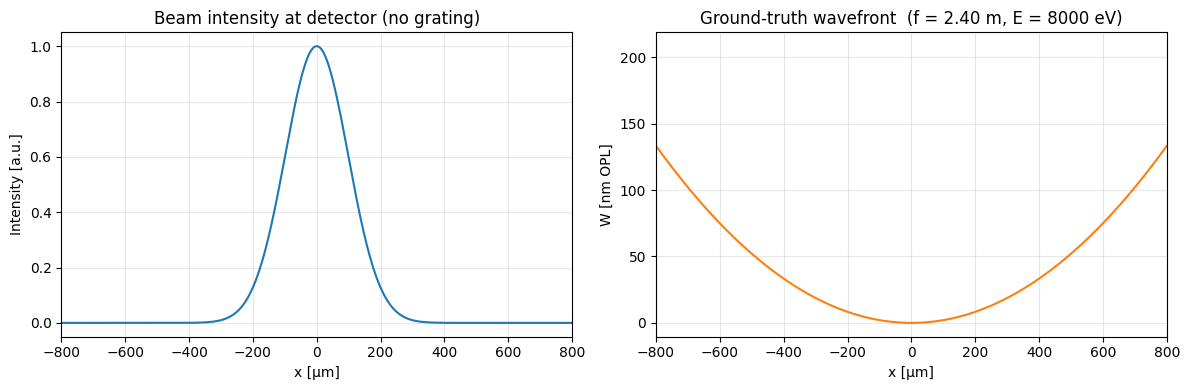

In [55]:
# ── Cell 1: Parameters → ground truth ─────────────────────────────────────
energy_eV     = 8000.0
f_m           = 2.4       # source-to-detector [m]
source_fwhm_m = 1e-6

gt = sim_setup(energy_eV, f_m, source_fwhm_m, x_m=x_m, L_m=L_m, z_T_m=z_T_m)

wavelength_m  = gt['wavelength_m']
z0_m          = gt['z0_m']
E_at_grating  = gt['E_at_grating']
phase_gt      = gt['phase_gt']

print(f"λ = {wavelength_m*1e9:.3f} nm | z0 = {z0_m:.3f} m | f_pred_expected ≈ {-f_m:.3f} m")

# ── Ground-truth diagnostic ────────────────────────────────────────────────
phase_gt_nm = phase_gt * wavelength_m / (2*np.pi) * 1e9
I_det       = np.abs(gt['E_at_detector'])**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_m*1e6, I_det / I_det.max(), lw=1.5)
axes[0].set_xlabel('x [µm]'); axes[0].set_ylabel('Intensity [a.u.]')
axes[0].set_title('Beam intensity at detector (no grating)')
axes[0].set_xlim(-800, 800); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, phase_gt_nm, lw=1.5, color='C1')
axes[1].set_xlabel('x [µm]'); axes[1].set_ylabel('W [nm OPL]')
axes[1].set_title(f'Ground-truth wavefront  (f = {f_m:.2f} m, E = {energy_eV:.0f} eV)')
axes[1].set_xlim(-800, 800); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Pitch: 31.5 µm (hardware) | Talbot z at this λ: 6.402 m | z_T (hardware): 0.3 m


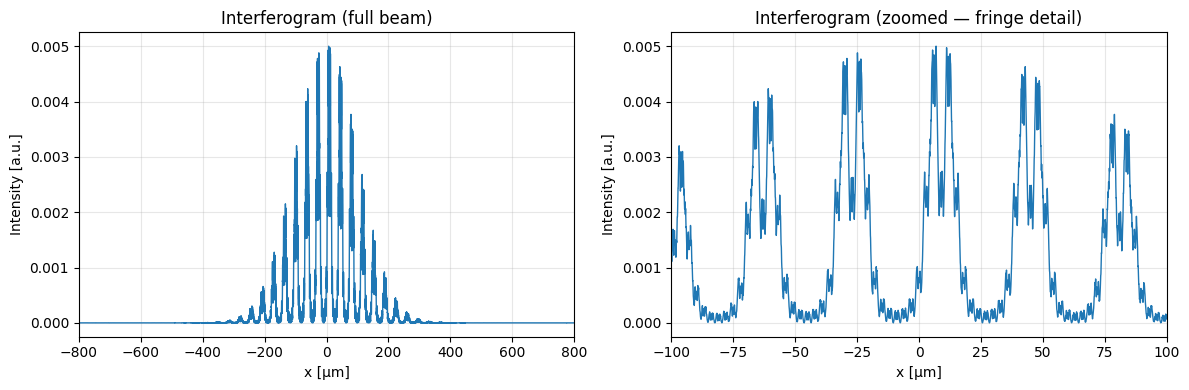

In [56]:
# ── Cell 2: Grating → interferogram ───────────────────────────────────────
# Hardware pitch — fixed by chip fabrication, not derived from Talbot.
grating_pitch_m = 31.5e-6    # [m]  chip1 hardware value

grating     = (np.sign(np.sin(2*np.pi * x_m / grating_pitch_m)) + 1) / 2
E_modulated = E_at_grating * grating
E_at_z_T    = propTF(E_modulated, L_m, wavelength_m, z_T_m)
I_sim       = np.abs(E_at_z_T)**2

print(f"Pitch: {grating_pitch_m*1e6:.1f} µm (hardware) | "
      f"Talbot z at this λ: {grating_pitch_m**2/wavelength_m:.3f} m | "
      f"z_T (hardware): {z_T_m} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_m*1e6, I_sim, lw=1)
axes[0].set_xlabel('x [µm]'); axes[0].set_ylabel('Intensity [a.u.]')
axes[0].set_title('Interferogram (full beam)')
axes[0].set_xlim(-800, 800); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_m*1e6, I_sim, lw=1)
axes[1].set_xlabel('x [µm]'); axes[1].set_ylabel('Intensity [a.u.]')
axes[1].set_title('Interferogram (zoomed — fringe detail)')
axes[1].set_xlim(-100, 100); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

[good]  λ=0.15nm  k_peak=28.0 cyc/mm  r_DC=1.6  SNR=4633.7  f_pred=-2.43m  RMS_W=2.6nm  RMS_resid=0.000nm


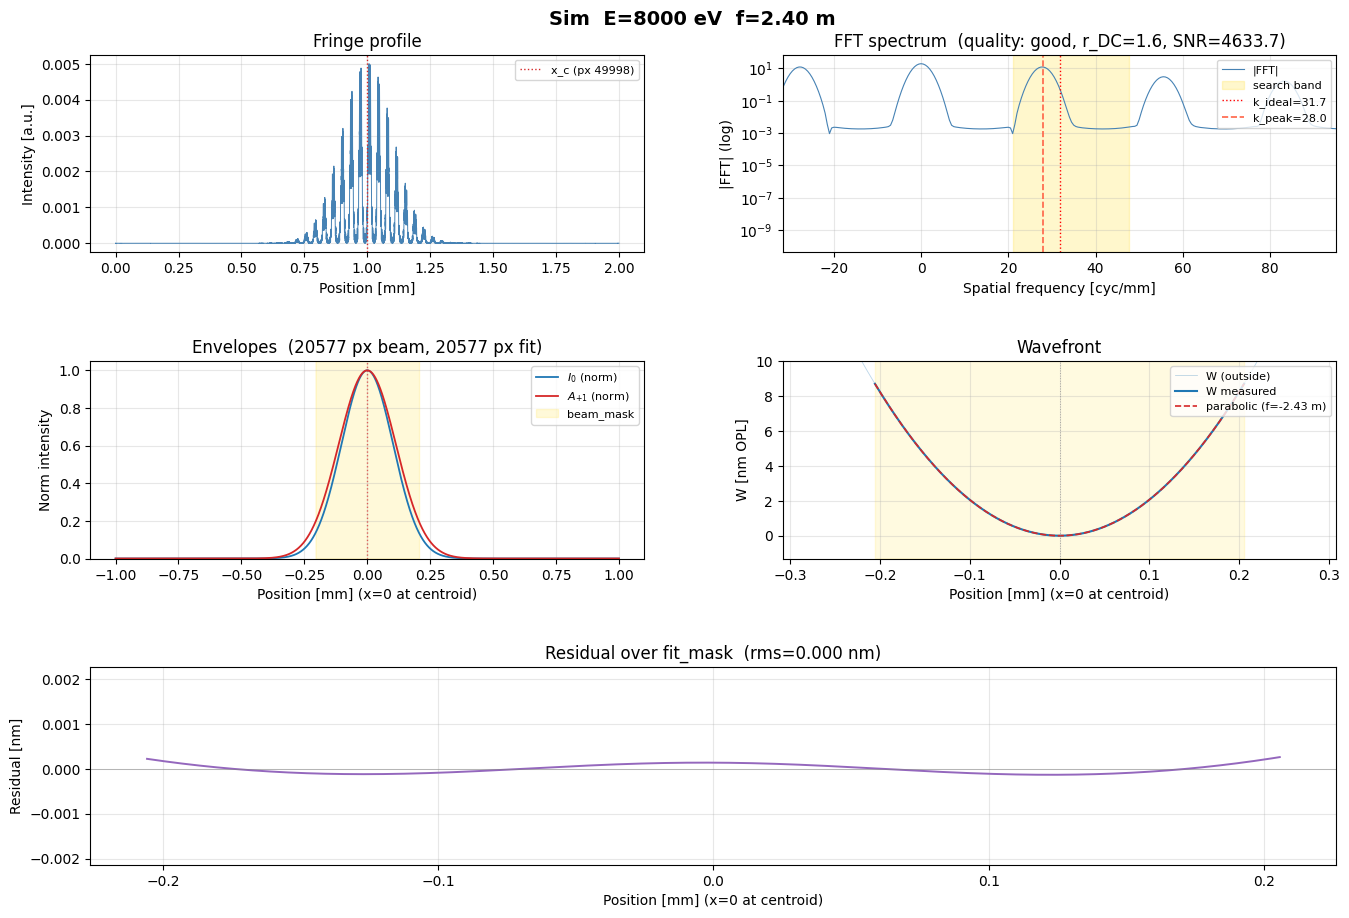


f_pred  = -2.4340 m   (expected -2.4000 m, error -34.0 mm)


In [57]:
# ── Cell 3: Reconstruct with wfs_live ─────────────────────────────────────
result = wfs.quick_look(
    I_sim, dx_m, grating_pitch_m, wavelength_m, z_T_m,
    title=f'Sim  E={energy_eV:.0f} eV  f={f_m:.2f} m'
)

print(f"\nf_pred  = {result['f_pred']:+.4f} m   (expected {-f_m:+.4f} m, "
      f"error {(result['f_pred'] - (-f_m))*1e3:+.1f} mm)")

In [58]:
# ── Cell 3.1: reconstruct_single, no plot ─────────────────────────────────
result = wfs.reconstruct_single(
    I_sim, dx_m, grating_pitch_m, wavelength_m, z_T_m,
    verbose=True,
)
print(f"f_pred  = {result['f_pred']:+.4f} m   (expected {-f_m:+.4f} m, "
      f"error {(result['f_pred'] - (-f_m))*1e3:+.1f} mm)")

[good]  λ=0.15nm  k_peak=28.0 cyc/mm  r_DC=1.6  SNR=4633.7  f_pred=-2.43m  RMS_W=2.6nm  RMS_resid=0.000nm
f_pred  = -2.4340 m   (expected -2.4000 m, error -34.0 mm)


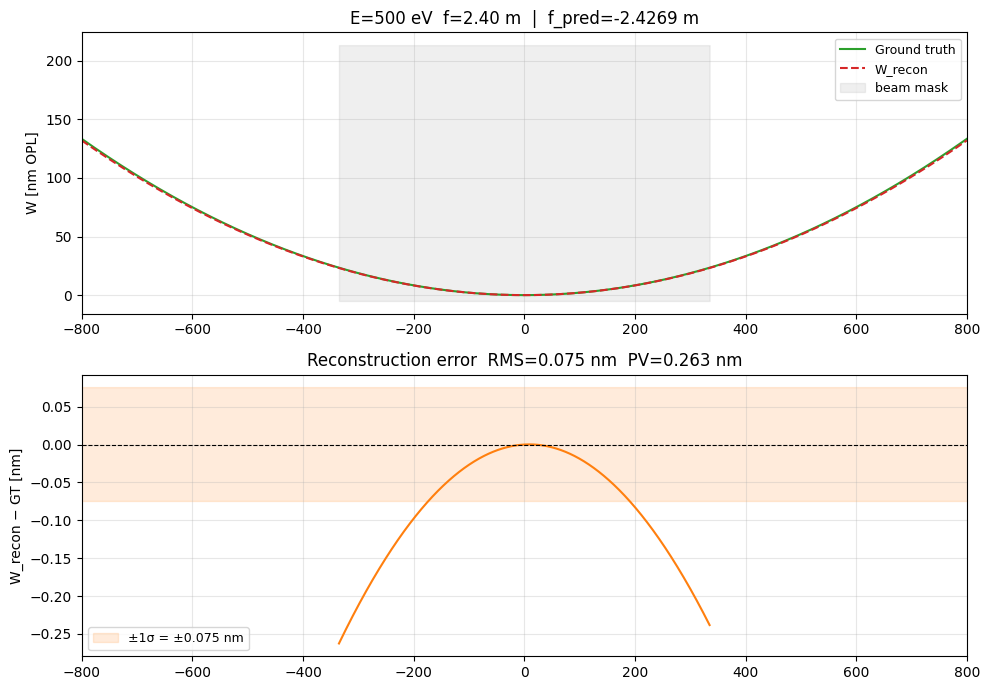

In [33]:
# ── Cell 4: Ground truth vs reconstructed wavefront ───────────────────────
x_c      = result['x_c']
to_nm    = wavelength_m / (2*np.pi) * 1e9
mask     = result['beam_mask']

gt_recentered = phase_gt - phase_gt[x_c]          # pin at same x_c as W_rad
diff          = result['W_rad'] - gt_recentered    # [rad]

gt_nm   = gt_recentered * to_nm
recon_nm = result['W_nm']
diff_nm  = diff * to_nm

diff_rms = np.std(diff_nm[mask])
diff_pv  = np.ptp(diff_nm[mask])

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

ax = axes[0]
ax.plot(x_m*1e6, gt_nm,    'C2',   lw=1.5, label='Ground truth')
ax.plot(x_m*1e6, recon_nm, 'C3--', lw=1.5, label='W_recon')
ax.fill_between(x_m*1e6, gt_nm.min()-5, gt_nm.max()+5,
                where=mask, color='gray', alpha=0.12, label='beam mask')
ax.set_xlim(-800, 800); ax.set_ylabel('W [nm OPL]')
ax.set_title(f'E={energy_eV:.0f} eV  f={f_m:.2f} m  |  '
             f'f_pred={result["f_pred"]:+.4f} m')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m*1e6, np.where(mask, diff_nm, np.nan), 'C1', lw=1.5)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.fill_between(x_m*1e6, -diff_rms, +diff_rms, color='C1', alpha=0.15,
                label=f'±1σ = ±{diff_rms:.3f} nm')
ax.set_xlim(-800, 800); ax.set_ylabel('W_recon − GT [nm]')
ax.set_title(f'Reconstruction error  RMS={diff_rms:.3f} nm  PV={diff_pv:.3f} nm')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [112]:
# ── Cell A: Simulation helper — parameters → interferogram ─────────────────

def sim_interferogram(energy_eV, f_m, grating_pitch_m,
                      source_fwhm_m=10e-6,
                      *, x_m, L_m, z_T_m, verbose=False):
    """
    Physical parameters → simulated interferogram + ground truth.

    Wraps sim_setup (Cell 0) + grating application + Talbot propagation.
    grating_pitch_m is a hardware constant, not derived from Talbot condition.

    Returns
    -------
    dict
        I_sim        : ndarray (M,)   interferogram intensity
        wavelength_m : float          derived from energy_eV
        phase_gt     : ndarray (M,)   free-space wavefront at detector [rad],
                                      centered at x_c = M//2
        z0_m         : float          source-to-grating distance
    """
    gt = sim_setup(energy_eV, f_m, source_fwhm_m, x_m=x_m, L_m=L_m, z_T_m=z_T_m)

    wavelength_m = gt['wavelength_m']

    grating     = (np.sign(np.sin(2*np.pi * x_m / grating_pitch_m)) + 1) / 2
    E_modulated = gt['E_at_grating'] * grating
    I_sim       = np.abs(propTF(E_modulated, L_m, wavelength_m, z_T_m))**2

    if verbose:
        z_T_nominal = grating_pitch_m**2 / wavelength_m
        print(f"E={energy_eV:.0f} eV | λ={wavelength_m*1e9:.3f} nm | "
              f"z0={gt['z0_m']:.3f} m | "
              f"Talbot z={z_T_nominal:.3f} m (hardware z_T={z_T_m} m)")

    return dict(
        I_sim        = I_sim,
        wavelength_m = wavelength_m,
        phase_gt     = gt['phase_gt'],
        z0_m         = gt['z0_m'],
    )

In [113]:
# ── Cell B: Test sim_interferogram + reconstruct_single ───────────────────

# ── Parameters ────────────────────────────────────────────────────────────
energy_eV       = 500.0
f_m             = -1
grating_pitch_m = 31.5e-6
z_T_m           = 0.4      # grating → detector [m]; tune here
source_fwhm_m   = 5e-6   # source FWHM [m]

# ── Simulate ───────────────────────────────────────────────────────────────
sim = sim_interferogram(energy_eV, f_m, grating_pitch_m, source_fwhm_m=source_fwhm_m,
                        x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=True)

# ── Reconstruct ───────────────────────────────────────────────────────────
result = wfs.reconstruct_single(
    sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m,
    verbose=True,
)

print(f"\nf_pred = {result['f_pred']:+.4f} m   "
      f"expected {-f_m:+.4f} m   "
      f"error {(result['f_pred'] - (-f_m))*1e3:+.2f} mm")

E=500 eV | λ=2.480 nm | z0=-1.400 m | Talbot z=0.400 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=44.0 cyc/mm  r_DC=4.8  SNR=4126.3  f_pred=+1.03m  RMS_W=11.2nm  RMS_resid=0.007nm

f_pred = +1.0335 m   expected +1.0000 m   error +33.51 mm


In [ ]:
# ── Cell B: Test sim_interferogram + reconstruct_single ───────────────────

# ── Parameters ────────────────────────────────────────────────────────────
energy_eV       = 8000.0
f_m             = 0.9
grating_pitch_m = 7e-6
z_T_m           = 0.3      # grating → detector [m]; tune here
source_fwhm_m   = 1e-6   # source FWHM [m]

# ── Simulate ───────────────────────────────────────────────────────────────
sim = sim_interferogram(energy_eV, f_m, grating_pitch_m, source_fwhm_m=source_fwhm_m,
                        x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=True)

# ── Reconstruct ───────────────────────────────────────────────────────────
result = wfs.reconstruct_single(
    sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m,
    verbose=True,
)

print(f"\nf_pred = {result['f_pred']:+.4f} m   "
      f"expected {-f_m:+.4f} m   "
      f"error {(result['f_pred'] - (-f_m))*1e3:+.2f} mm")

E=8000 eV | λ=0.155 nm | z0=0.600 m | Talbot z=0.316 m (hardware z_T=0.3 m)
[good]  λ=0.15nm  k_peak=190.5 cyc/mm  r_DC=3.2  SNR=29.1  f_pred=+0.90m  RMS_W=1.0nm  RMS_resid=0.000nm

f_pred = +0.9012 m   expected -0.9000 m   error +1801.17 mm


## Varying source distance


  f_m = 4 m
E=500 eV | λ=2.480 nm | z0=3.600 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=30.0 cyc/mm  r_DC=1.7  SNR=397.0  f_pred=-3.98m  RMS_W=37.5nm  RMS_resid=0.065nm


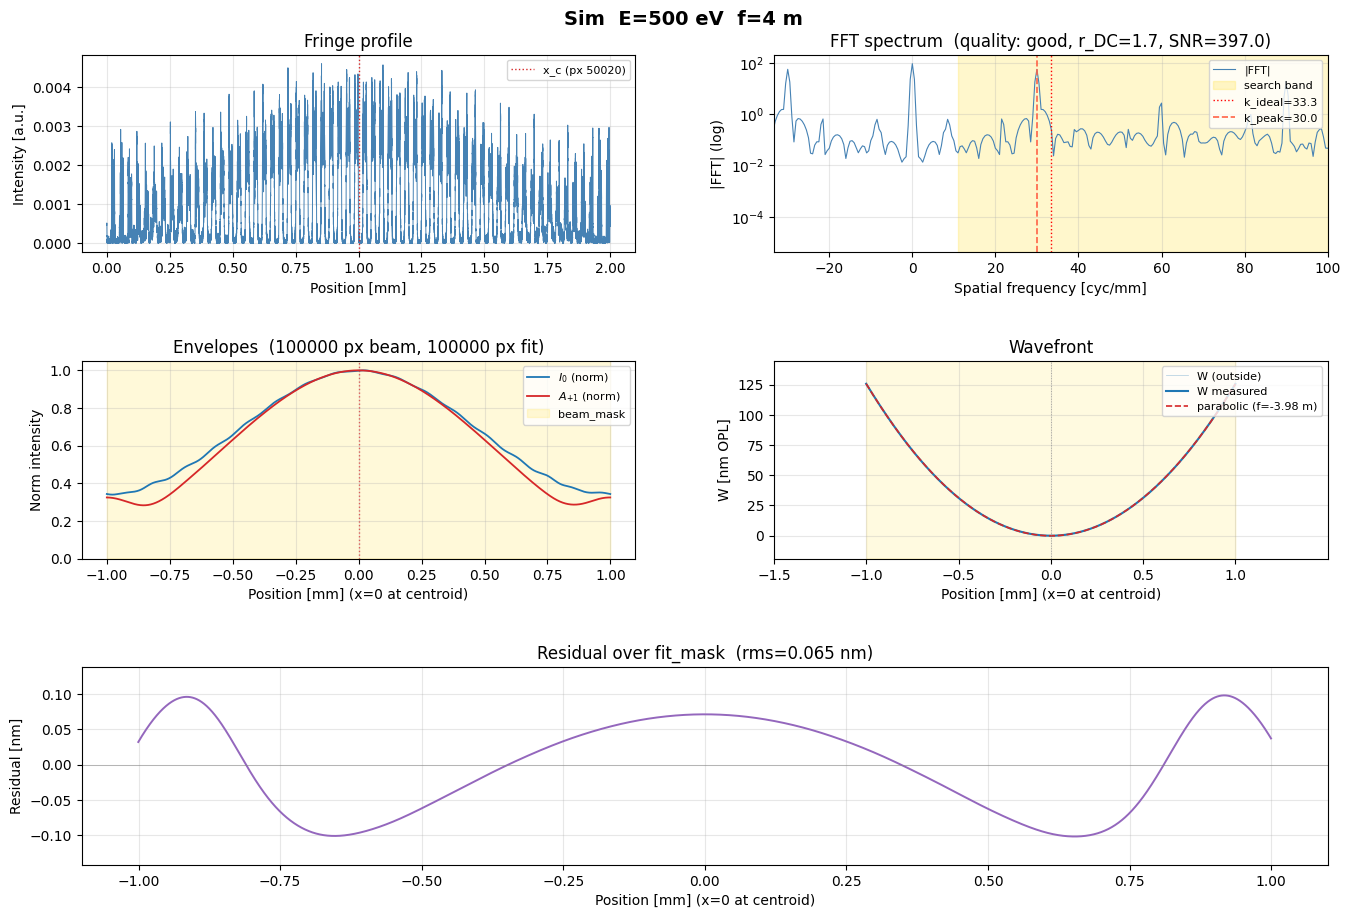

f_pred = -3.9784 m   expected -4.0000 m   error +21.59 mm

  f_m = 2 m
E=500 eV | λ=2.480 nm | z0=1.600 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=26.5 cyc/mm  r_DC=1.8  SNR=1495308.1  f_pred=-2.00m  RMS_W=22.1nm  RMS_resid=0.000nm


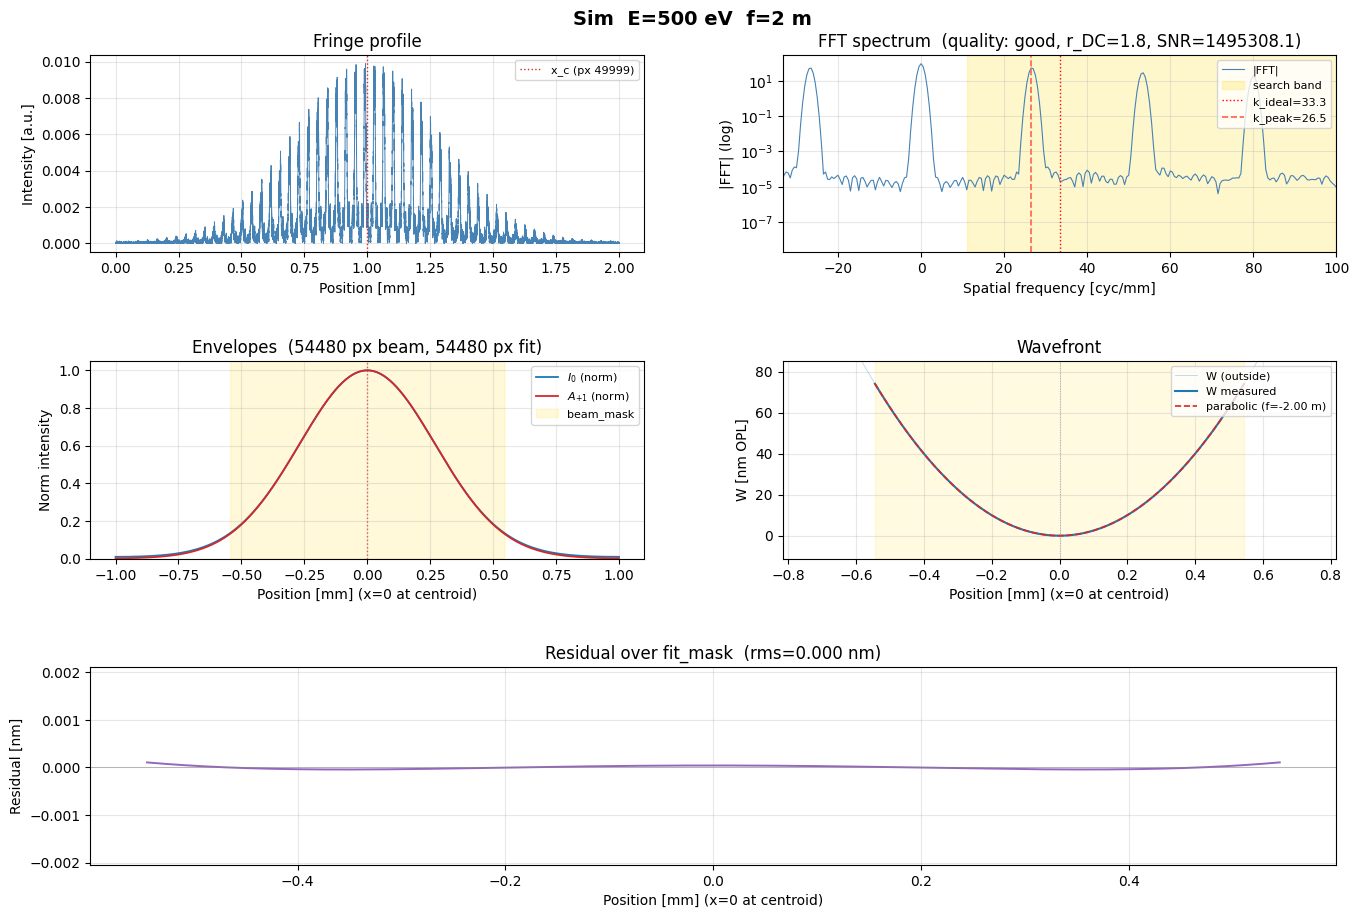

f_pred = -2.0018 m   expected -2.0000 m   error -1.82 mm

  f_m = 1.5 m
E=500 eV | λ=2.480 nm | z0=1.100 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=24.5 cyc/mm  r_DC=1.9  SNR=7937140.7  f_pred=-1.51m  RMS_W=17.0nm  RMS_resid=0.000nm


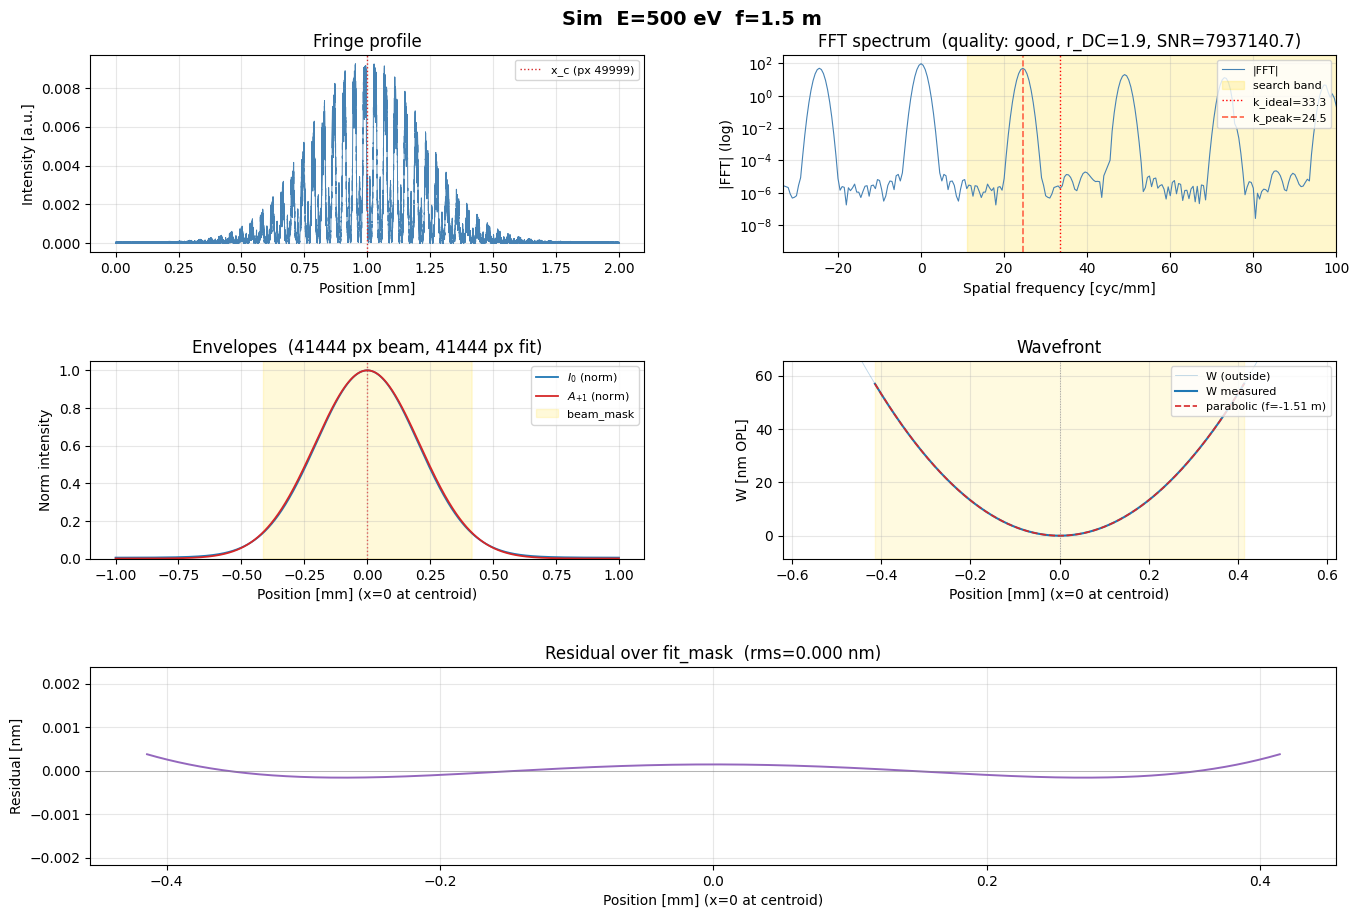

f_pred = -1.5081 m   expected -1.5000 m   error -8.08 mm

  f_m = 1 m
E=500 eV | λ=2.480 nm | z0=0.600 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=20.5 cyc/mm  r_DC=3.3  SNR=1191.7  f_pred=-1.02m  RMS_W=12.1nm  RMS_resid=0.001nm


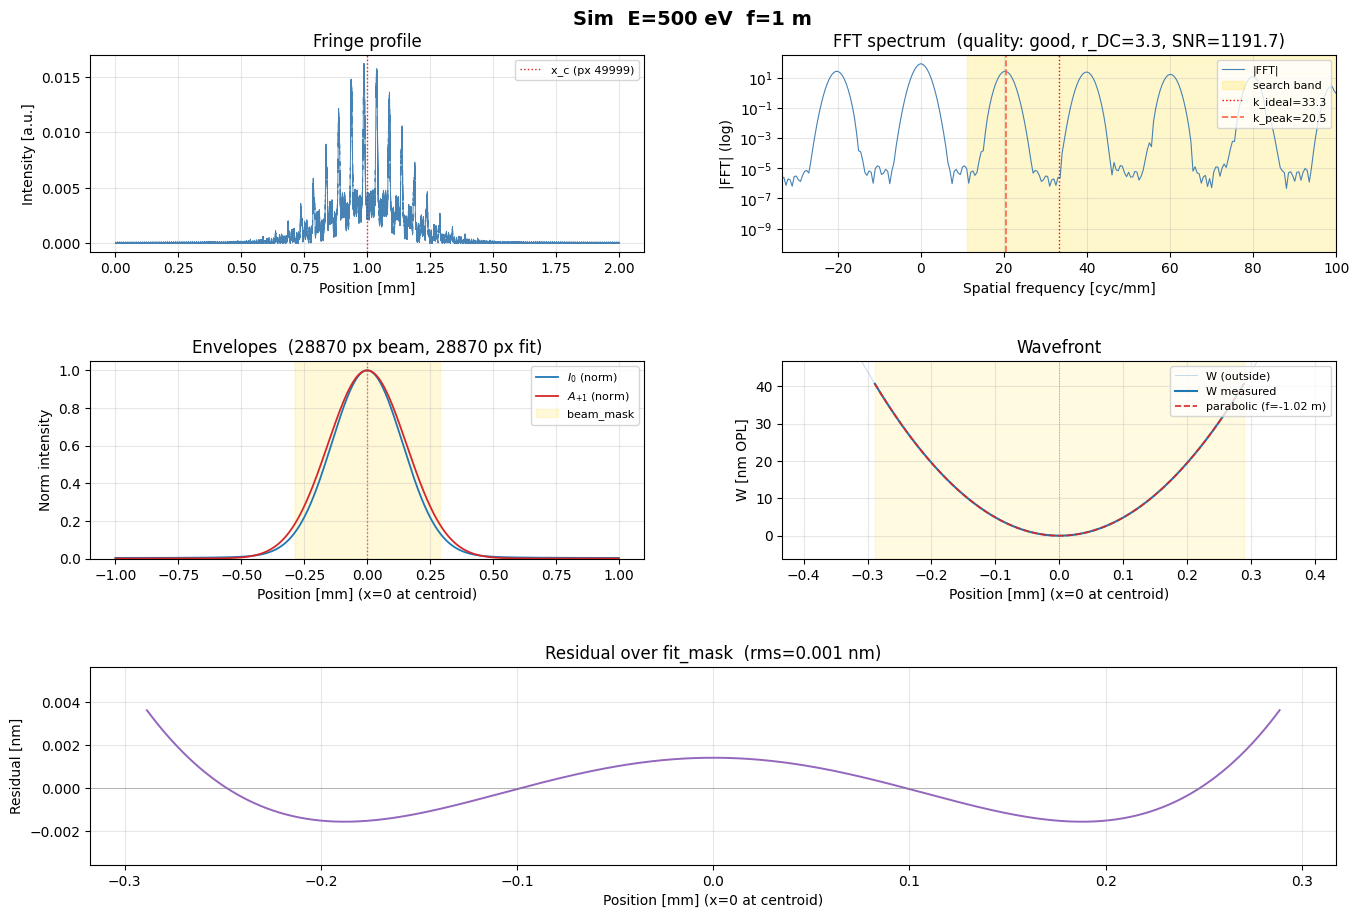

f_pred = -1.0248 m   expected -1.0000 m   error -24.84 mm


In [101]:
# ── Loop: vary f_m ────────────────────────────────────────────────────────

# ── Fixed parameters ──────────────────────────────────────────────────────
energy_eV       = 500.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

# ── Sweep ─────────────────────────────────────────────────────────────────
f_values  = [4, 2, 1.5, 1]     # source-to-detector [m]
results   = {}             # keyed by f_m for later use

for f_m in f_values:
    print(f"\n{'='*60}")
    print(f"  f_m = {f_m} m")
    print(f"{'='*60}")

    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=True)

    result = wfs.quick_look(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m, band_factor=3.0,
        title=f'Sim  E={energy_eV:.0f} eV  f={f_m} m',
    )

    print(f"f_pred = {result['f_pred']:+.4f} m   "
          f"expected {-f_m:+.4f} m   "
          f"error {(result['f_pred'] - (-f_m))*1e3:+.2f} mm")

    results[f_m] = dict(sim=sim, result=result)

In [118]:
# ── Loop: vary f_m ────────────────────────────────────────────────────────

energy_eV       = 500.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

f_values = [4, 3.5, 3, 2.5, 2, 1.5, 1]
results  = {}

for f_m in f_values:
    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=False)

    result = wfs.reconstruct_single(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m, band_factor=2.0,
        verbose=False,
    )

    results[f_m] = dict(sim=sim, result=result)

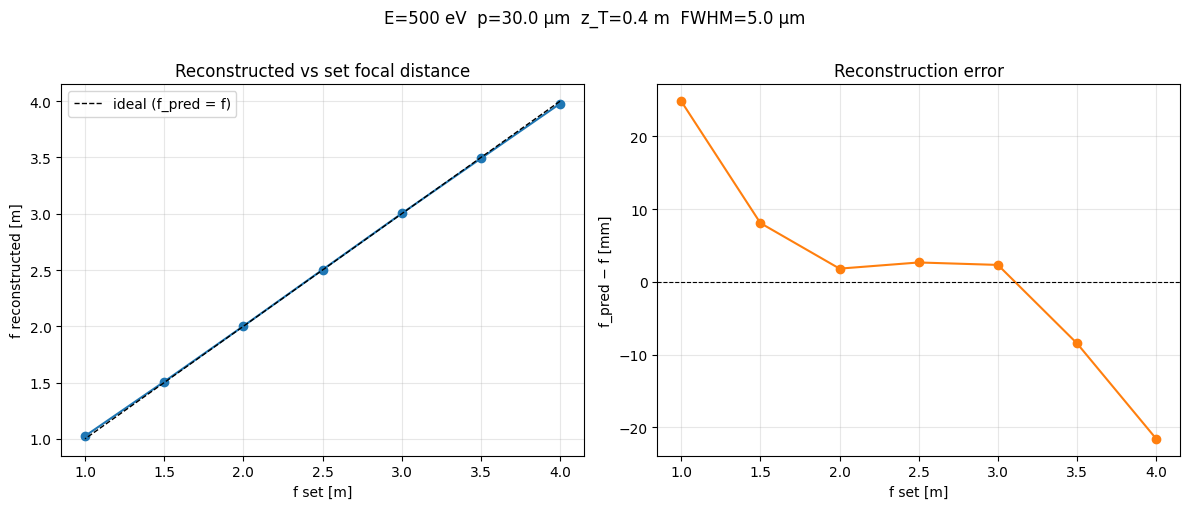

In [119]:
# ── Plot: f_pred vs f_m ───────────────────────────────────────────────────

f_set   = np.array(f_values)
f_pred  = np.array([-results[f]['result']['f_pred'] for f in f_values])
# f_pred negated: wfs convention is f_pred = -f (focus upstream)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(f_set, f_pred, 'o-', lw=1.5)
ax.plot(f_set, f_set, 'k--', lw=1, label='ideal (f_pred = f)')
ax.set_xlabel('f set [m]'); ax.set_ylabel('f reconstructed [m]')
ax.set_title('Reconstructed vs set focal distance')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(f_set, (f_pred - f_set)*1e3, 'o-', lw=1.5, color='C1')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('f set [m]'); ax.set_ylabel('f_pred − f [mm]')
ax.set_title('Reconstruction error')
ax.grid(True, alpha=0.3)

plt.suptitle(f'E={energy_eV:.0f} eV  p={grating_pitch_m*1e6:.1f} µm  '
             f'z_T={z_T_m} m  FWHM={source_fwhm_m*1e6:.1f} µm', y=1.01)
plt.tight_layout(); plt.show()


  f_m = -3.2 m
E=500 eV | λ=2.480 nm | z0=-3.600 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=37.5 cyc/mm  r_DC=2.3  SNR=224.2  f_pred=+3.21m  RMS_W=44.1nm  RMS_resid=0.029nm


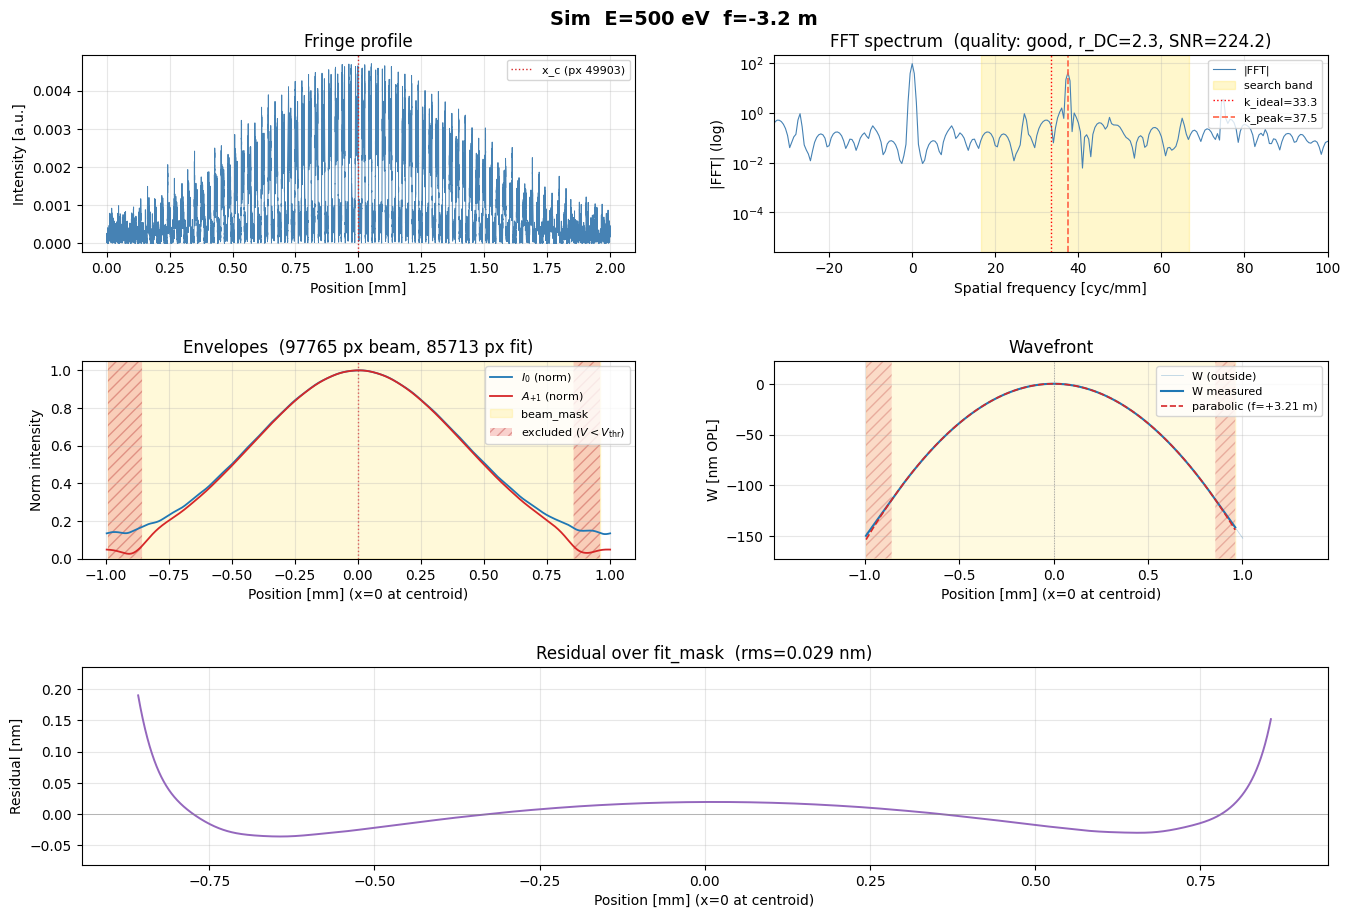

f_pred = +3.2142 m   expected +3.2000 m   error +14.22 mm

  f_m = -1.2 m
E=500 eV | λ=2.480 nm | z0=-1.600 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=44.0 cyc/mm  r_DC=12.3  SNR=153528.6  f_pred=+1.29m  RMS_W=12.8nm  RMS_resid=0.071nm


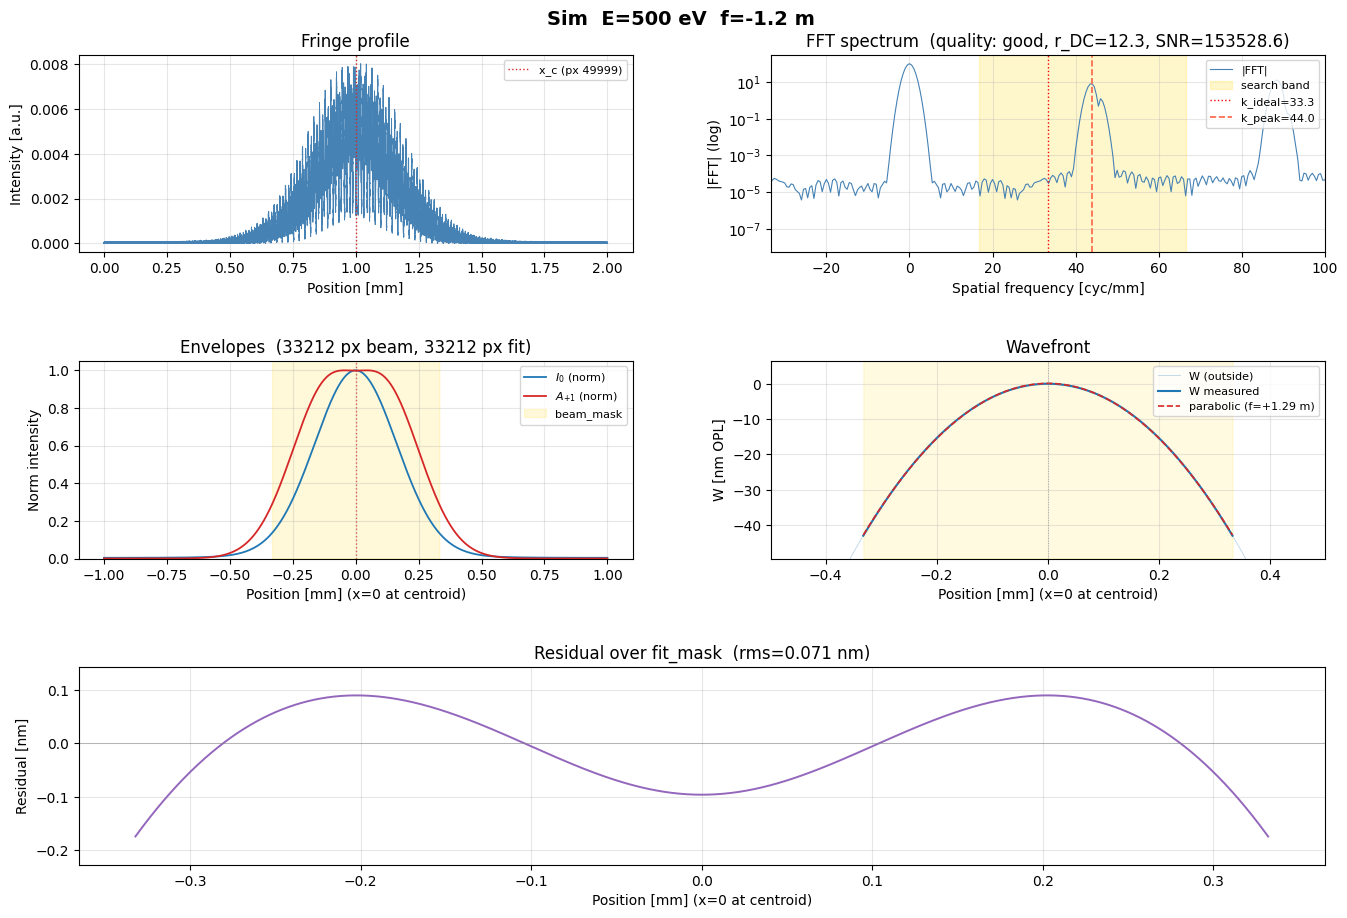

f_pred = +1.2855 m   expected +1.2000 m   error +85.46 mm

  f_m = -0.7 m
E=500 eV | λ=2.480 nm | z0=-1.100 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=52.5 cyc/mm  r_DC=2.4  SNR=13453280.7  f_pred=+0.69m  RMS_W=8.8nm  RMS_resid=0.002nm


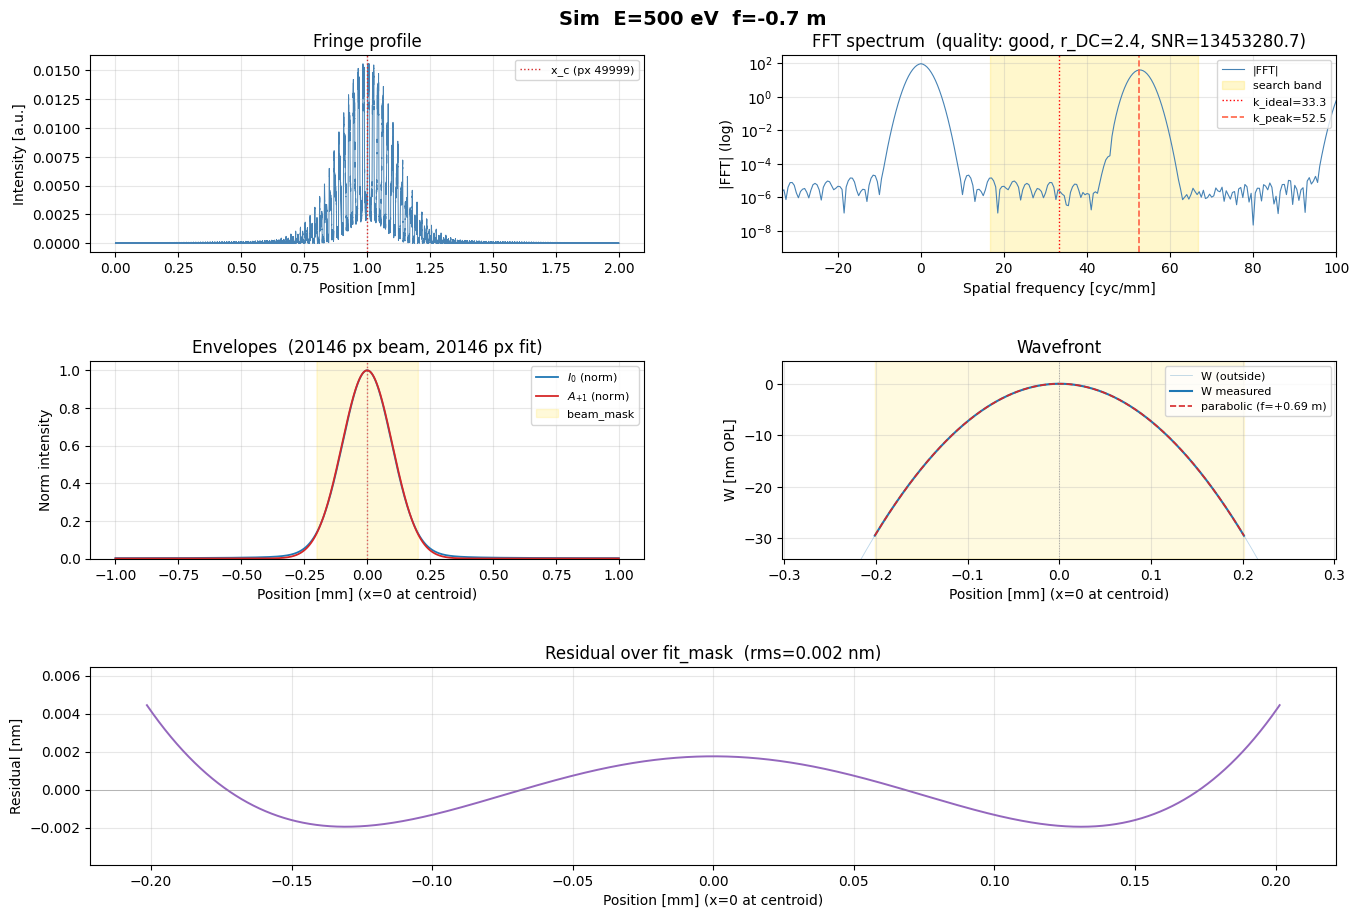

f_pred = +0.6888 m   expected +0.7000 m   error -11.18 mm

  f_m = -0.4 m
E=500 eV | λ=2.480 nm | z0=-0.800 m | Talbot z=0.363 m (hardware z_T=0.4 m)
[good]  λ=2.48nm  k_peak=66.0 cyc/mm  r_DC=2.0  SNR=609213.4  f_pred=+0.41m  RMS_W=5.6nm  RMS_resid=0.002nm


/Users/francisho/Library/CloudStorage/OneDrive-UCSanDiego/Research/Projects/nabla/wfs-als531/wfs_live.py:1023: UserWarning: k_peak=66.0 cyc/mm landed within 5% of k_ideal of a search-band edge [16.7, 66.7] cyc/mm. Consider increasing band_factor (currently 2.0).
  car = find_carrier(profile, dx, grating_pitch, band_factor=band_factor)


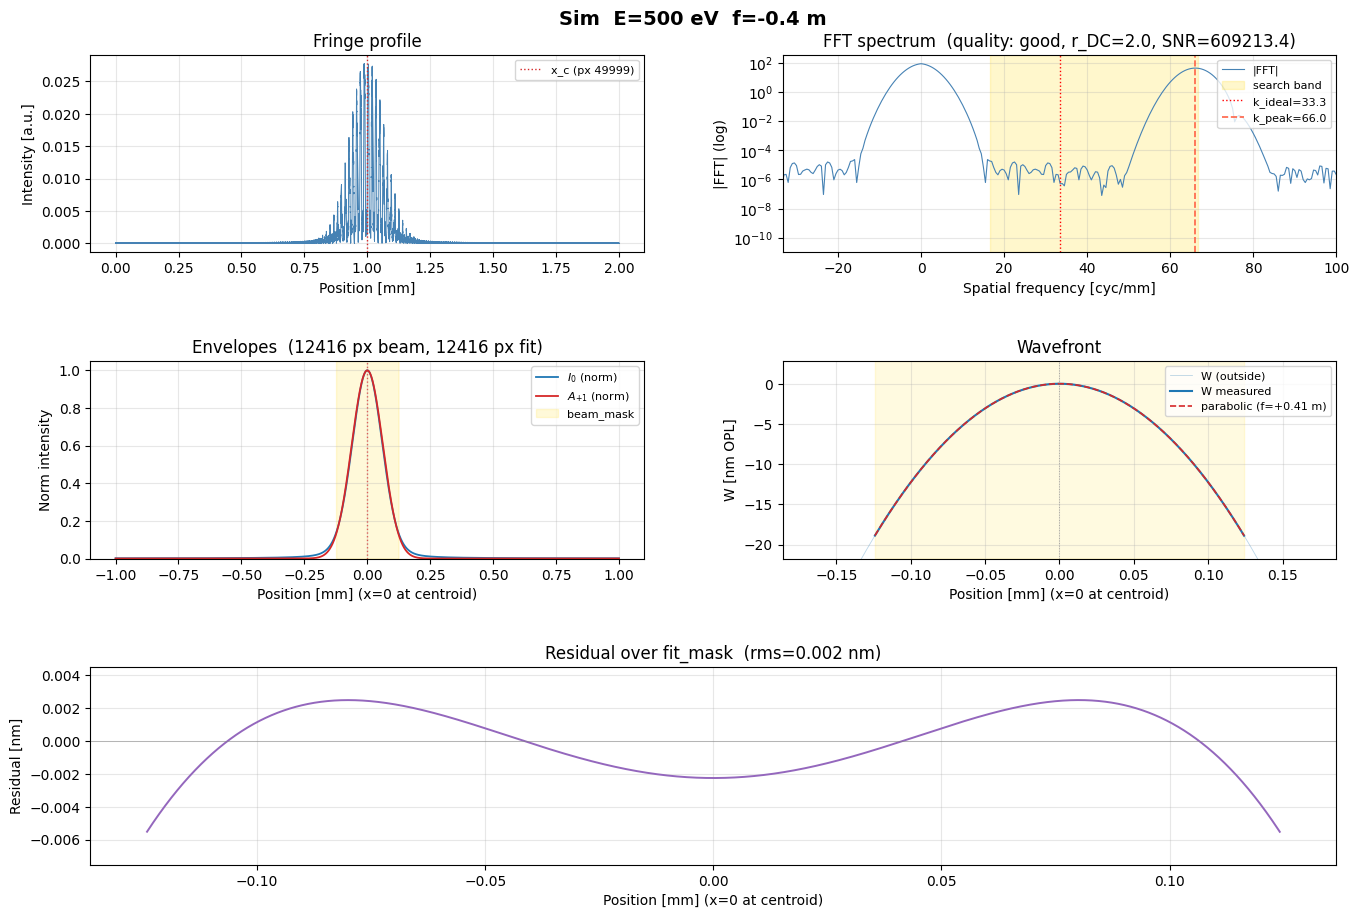

f_pred = +0.4082 m   expected +0.4000 m   error +8.17 mm


In [129]:
# ── Loop: vary f_m ────────────────────────────────────────────────────────

# ── Fixed parameters ──────────────────────────────────────────────────────
energy_eV       = 500.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

# ── Sweep ─────────────────────────────────────────────────────────────────
f_values = [-3.2, -1.2, -0.7, -0.4]     # source-to-detector [m]
results   = {}             # keyed by f_m for later use

for f_m in f_values:
    print(f"\n{'='*60}")
    print(f"  f_m = {f_m} m")
    print(f"{'='*60}")

    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=True)

    result = wfs.quick_look(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m, band_factor=2.0,
        title=f'Sim  E={energy_eV:.0f} eV  f={f_m} m',
    )

    print(f"f_pred = {result['f_pred']:+.4f} m   "
          f"expected {-f_m:+.4f} m   "
          f"error {(result['f_pred'] - (-f_m))*1e3:+.2f} mm")

    results[f_m] = dict(sim=sim, result=result)

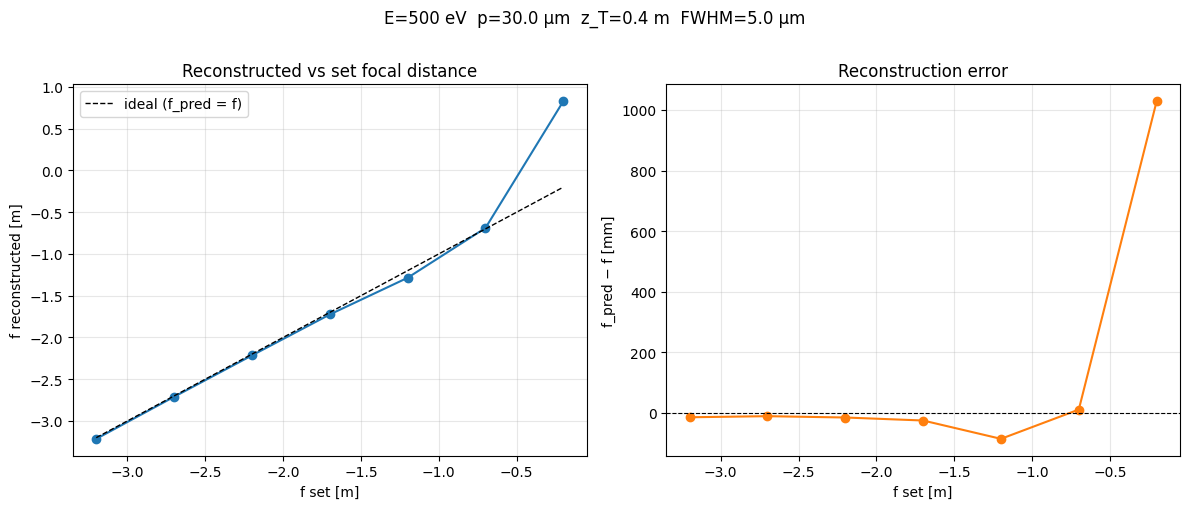

In [117]:
# ── Loop: vary f_m ────────────────────────────────────────────────────────

energy_eV       = 500.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

f_values = [-3.2, -2.7, -2.2, -1.7, -1.2, -0.7, -0.2]
results  = {}

for f_m in f_values:
    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=False)

    result = wfs.reconstruct_single(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m, band_factor=2.0,
        verbose=False,
    )

    results[f_m] = dict(sim=sim, result=result)

# ── Plot: f_pred vs f_m ───────────────────────────────────────────────────

f_set   = np.array(f_values)
f_pred  = np.array([-results[f]['result']['f_pred'] for f in f_values])
# f_pred negated: wfs convention is f_pred = -f (focus upstream)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(f_set, f_pred, 'o-', lw=1.5)
ax.plot(f_set, f_set, 'k--', lw=1, label='ideal (f_pred = f)')
ax.set_xlabel('f set [m]'); ax.set_ylabel('f reconstructed [m]')
ax.set_title('Reconstructed vs set focal distance')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(f_set, (f_pred - f_set)*1e3, 'o-', lw=1.5, color='C1')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('f set [m]'); ax.set_ylabel('f_pred − f [mm]')
ax.set_title('Reconstruction error')
ax.grid(True, alpha=0.3)

plt.suptitle(f'E={energy_eV:.0f} eV  p={grating_pitch_m*1e6:.1f} µm  '
             f'z_T={z_T_m} m  FWHM={source_fwhm_m*1e6:.1f} µm', y=1.01)
plt.tight_layout(); plt.show()

In [130]:
# ── Loop: vary f_m (positive and negative) ────────────────────────────────

energy_eV       = 500.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

f_values_pos = [4, 3.5, 3, 2.5, 2, 1.5, 1+0.2]
f_values_neg = [-3.2, -2.7, -2.2, -1.7, -1.2, -0.7, -0.2-0.2]
f_values     = f_values_neg + f_values_pos

results = {}

for f_m in f_values:
    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=False)

    result = wfs.reconstruct_single(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m,
        band_factor=2.0, verbose=False,
    )

    results[f_m] = dict(sim=sim, result=result)


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9c/0twykfpn6fz80rr9vm2z_qbc0000gn/T/ipykernel_43181/2300888519.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(f_pos, k_peak_pos,  'o-',  color='C0', lw=1.5, label='measured $k_\mathrm{peak}$ / $k_\mathrm{ideal}$')
/var/folders/9c/0twykfpn6fz80rr9vm2z_qbc0000gn/T/ipykernel_43181/2300888519.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax.axhline(1,     color='gray', lw=0.8, ls=':', label='$k_\mathrm{ideal}$')
/var/folders/9c/0twykfpn6fz80rr9vm2z_qbc0000gn/T/ipykernel_43181/2300888519.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('f set [m]'); ax.set_ylabel('$k_\mathrm{peak}$ / $k_\mathrm{ideal}$')


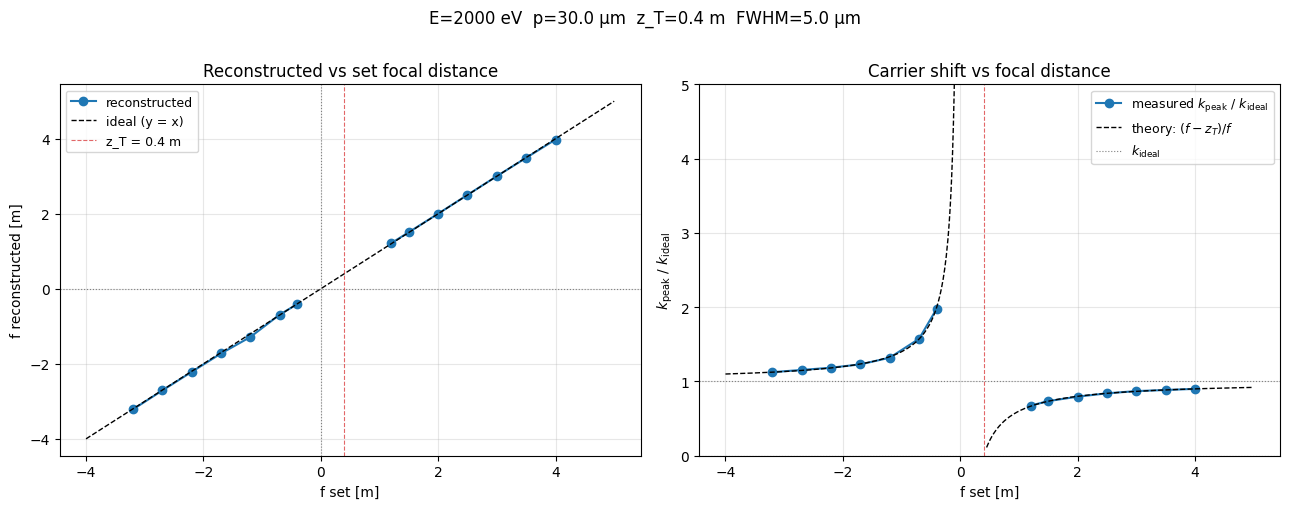

In [143]:
# ── Plot: f_pred and k_peak vs f_m (positive/negative split) ──────────────

f_pos = np.array(f_values_pos)
f_neg = np.array(f_values_neg)

def extract(flist, key, negate=False):
    arr = np.array([results[f]['result'][key] for f in flist])
    return -arr if negate else arr

f_pred_pos = extract(f_values_pos, 'f_pred', negate=True)
f_pred_neg = extract(f_values_neg, 'f_pred', negate=True)
k_peak_pos = extract(f_values_pos, 'k_peak') / (1/grating_pitch_m)
k_peak_neg = extract(f_values_neg, 'k_peak') / (1/grating_pitch_m)

# theory curve (dense)
f_dense_pos = np.linspace(z_T_m + 0.05, 5, 300)
f_dense_neg = np.linspace(-4, -0.01, 300)
k_th_pos    = (f_dense_pos - z_T_m) / f_dense_pos
k_th_neg    = (f_dense_neg - z_T_m) / f_dense_neg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: f_pred vs f set ───────────────────────────────────────────────
ax = axes[0]
ax.plot(f_pos, f_pred_pos, 'o-',  color='C0', lw=1.5, label='reconstructed')
ax.plot(f_neg, f_pred_neg, 'o-',  color='C0', lw=1.5)
ax.plot([-4, 5], [-4, 5],  'k--', lw=1,        label='ideal (y = x)')
ax.axvline(0,     color='gray', lw=0.8, ls=':')
ax.axhline(0,     color='gray', lw=0.8, ls=':')
ax.axvline(z_T_m, color='C3',  lw=0.8, ls='--', alpha=0.7, label=f'z_T = {z_T_m} m')
ax.set_xlabel('f set [m]'); ax.set_ylabel('f reconstructed [m]')
ax.set_title('Reconstructed vs set focal distance')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 2: k_peak vs f set ──────────────────────────────────────────────
ax = axes[1]
ax.plot(f_pos, k_peak_pos,  'o-',  color='C0', lw=1.5, label='measured $k_\mathrm{peak}$ / $k_\mathrm{ideal}$')
ax.plot(f_neg, k_peak_neg,  'o-',  color='C0', lw=1.5)
ax.plot(f_dense_pos, k_th_pos, 'k--', lw=1, label=r'theory: $(f-z_T)/f$')
ax.plot(f_dense_neg, k_th_neg, 'k--', lw=1)
ax.axhline(1,     color='gray', lw=0.8, ls=':', label='$k_\mathrm{ideal}$')
ax.axhline(0,     color='gray', lw=0.8, ls=':')
ax.axvline(z_T_m, color='C3',  lw=0.8, ls='--', alpha=0.7)
ax.set_ylim(0, 5)
ax.set_xlabel('f set [m]'); ax.set_ylabel('$k_\mathrm{peak}$ / $k_\mathrm{ideal}$')
ax.set_title('Carrier shift vs focal distance')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(f'E={energy_eV:.0f} eV  p={grating_pitch_m*1e6:.1f} µm  '
             f'z_T={z_T_m} m  FWHM={source_fwhm_m*1e6:.1f} µm', y=1.01)
plt.tight_layout(); plt.show()


============================================================  E = 200 eV  ============================================================
[good]  λ=6.20nm  k_peak=26.5 cyc/mm  r_DC=2.6  SNR=224.1  f_pred=-1.99m  RMS_W=74.8nm  RMS_resid=0.242nm


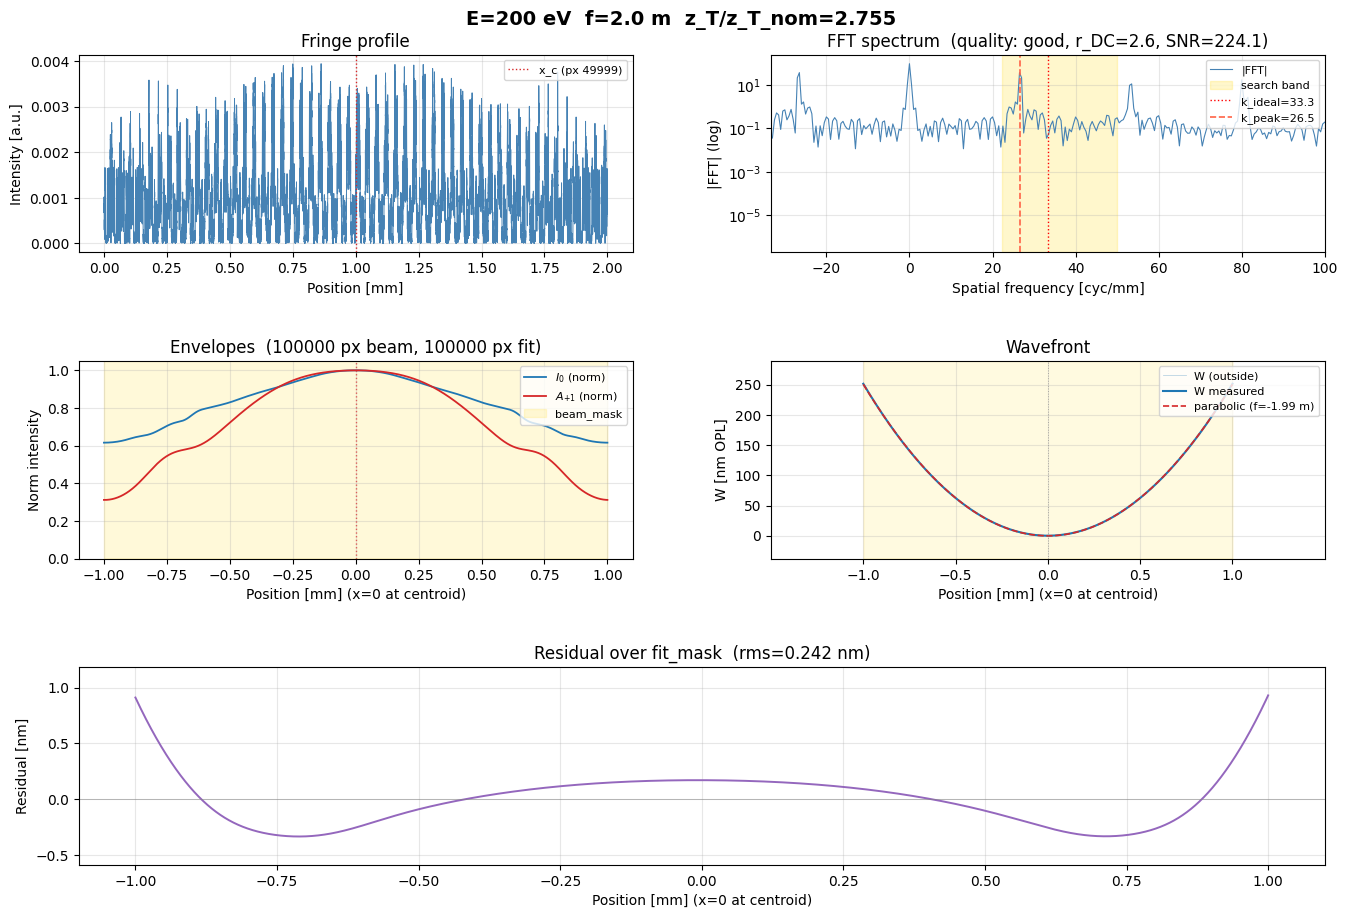


============================================================  E = 400 eV  ============================================================
[good]  λ=3.10nm  k_peak=26.5 cyc/mm  r_DC=1.7  SNR=32063.0  f_pred=-2.00m  RMS_W=34.8nm  RMS_resid=0.000nm


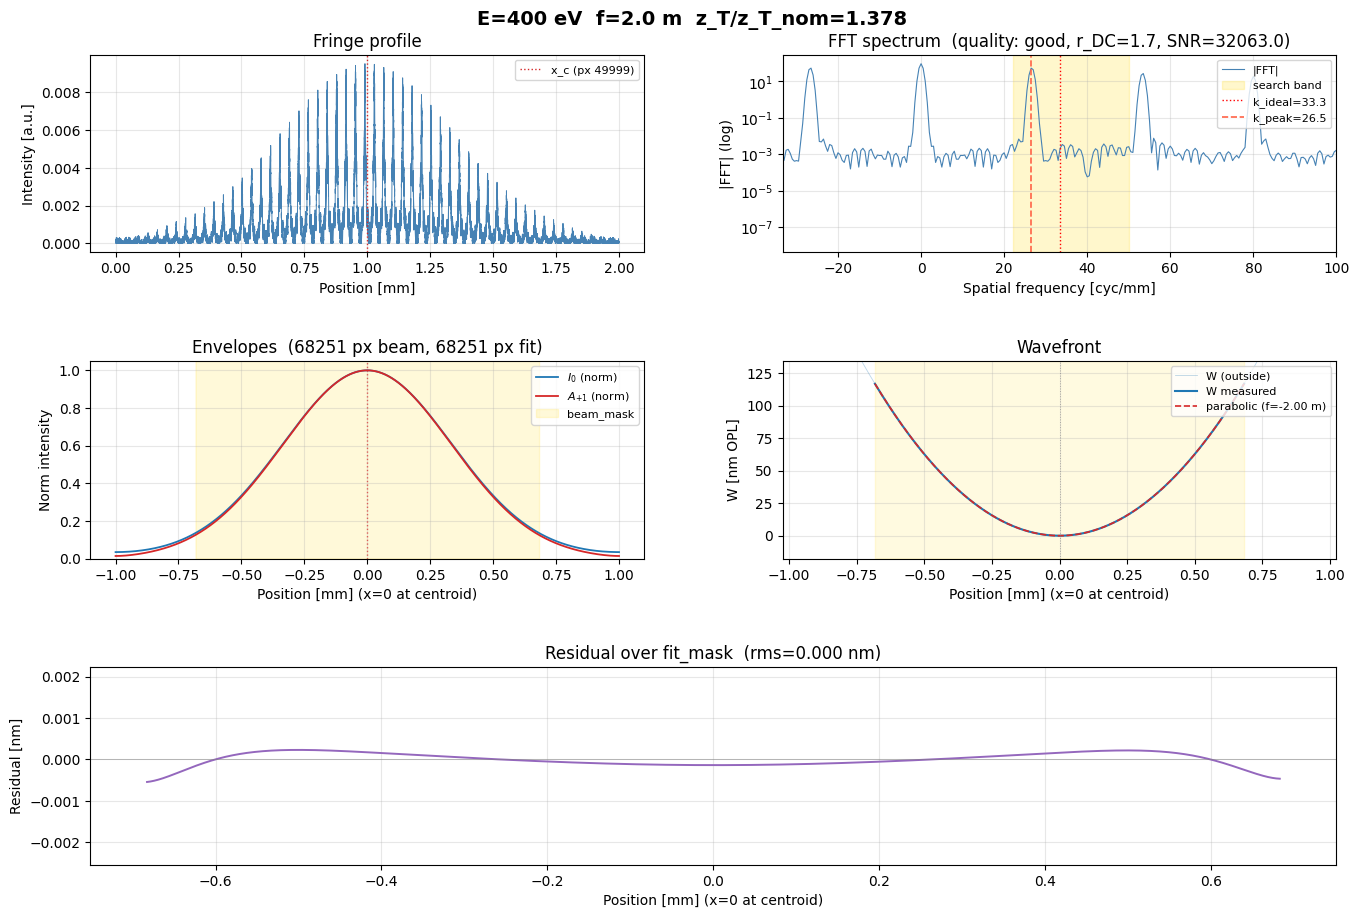


============================================================  E = 551 eV  ============================================================
[good]  λ=2.25nm  k_peak=26.5 cyc/mm  r_DC=2.0  SNR=9125659.3  f_pred=-2.01m  RMS_W=18.2nm  RMS_resid=0.000nm


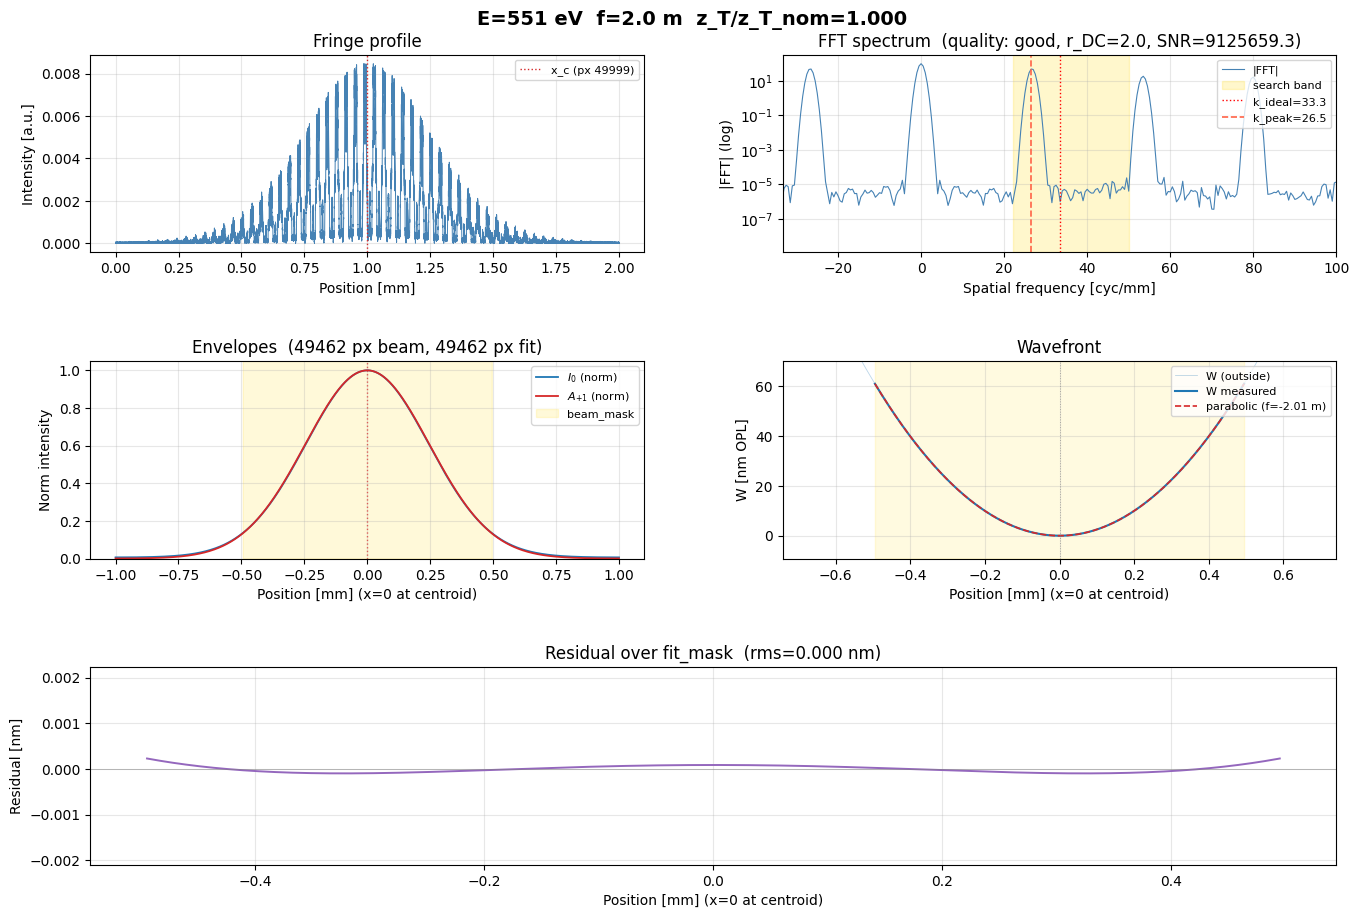


============================================================  E = 1000 eV  ============================================================
[good]  λ=1.24nm  k_peak=26.5 cyc/mm  r_DC=8.2  SNR=446512.6  f_pred=-1.90m  RMS_W=6.0nm  RMS_resid=0.004nm


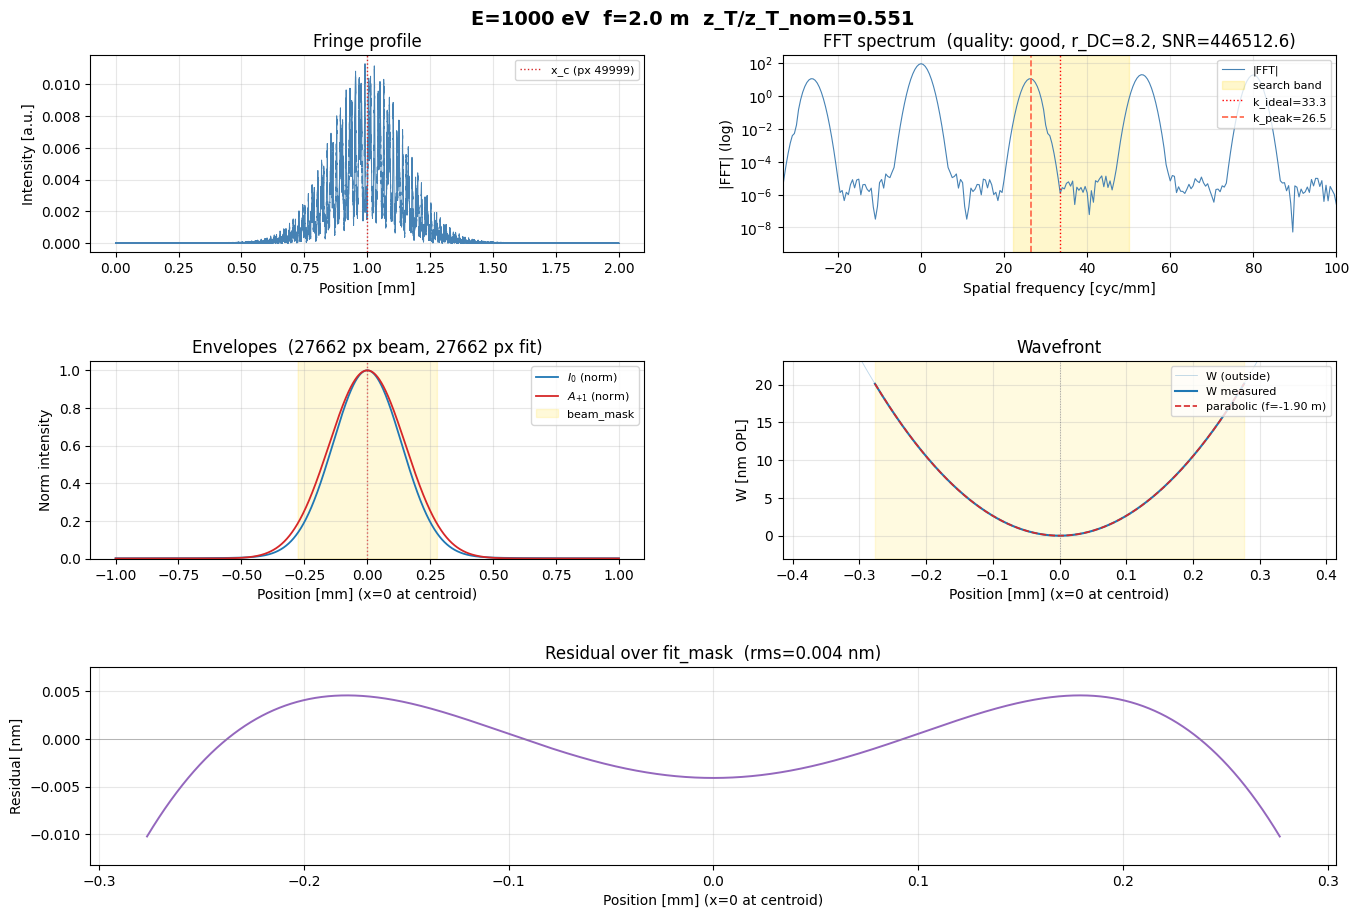


============================================================  E = 2000 eV  ============================================================
[good]  λ=0.62nm  k_peak=26.5 cyc/mm  r_DC=2.0  SNR=134.5  f_pred=-1.96m  RMS_W=1.7nm  RMS_resid=0.000nm


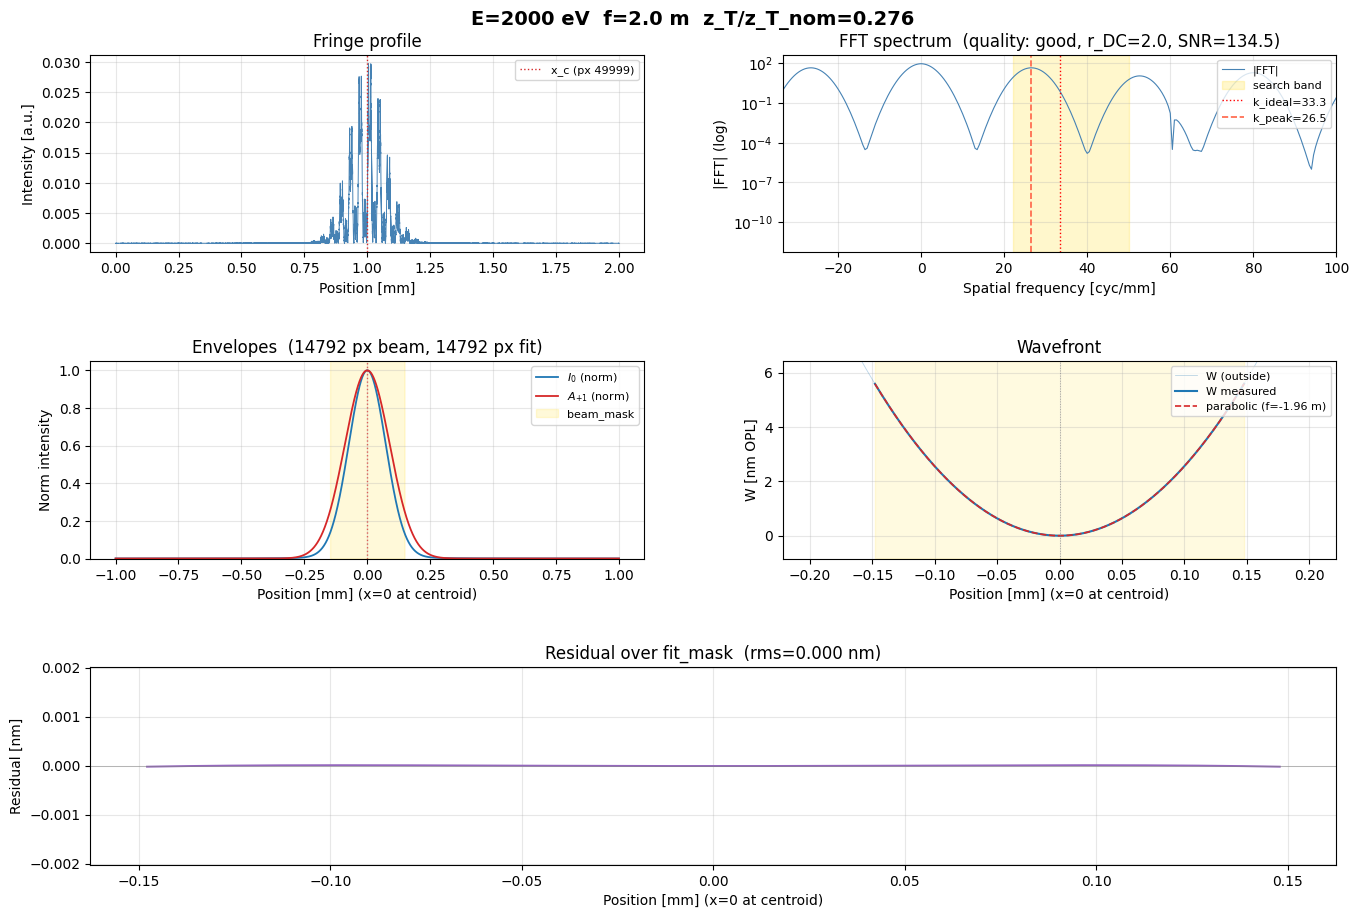

In [136]:
# ── Loop #2: quick_look for each energy ───────────────────────────────────

for energy_eV in e_values:
    print(f"\n{'='*60}  E = {energy_eV} eV  {'='*60}")
    sim = e_results[energy_eV]['sim']

    wfs.quick_look(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m,
        band_factor=1.5,
        title=f'E={energy_eV} eV  f={f_m} m  '
              f'z_T/z_T_nom={z_T_m / (grating_pitch_m**2 / sim["wavelength_m"]):.3f}',
    )

In [140]:
# ── Loop: vary energy_eV, fixed f_m ───────────────────────────────────────

f_m             = 2.0
grating_pitch_m = 30e-6
z_T_m           = 0.4
source_fwhm_m   = 5e-6

e_values = [200, 235, 277, 327, 385, 454, 535, 551, 631, 744, 877, 1033, 1218, 1435, 2000]
e_results = {}

for energy_eV in e_values:
    sim = sim_interferogram(energy_eV, f_m, grating_pitch_m,
                            source_fwhm_m=source_fwhm_m,
                            x_m=x_m, L_m=L_m, z_T_m=z_T_m, verbose=False)

    result = wfs.reconstruct_single(
        sim['I_sim'], dx_m, grating_pitch_m, sim['wavelength_m'], z_T_m,
        band_factor=1.5, verbose=True,
    )

    e_results[energy_eV] = dict(sim=sim, result=result)


[good]  λ=6.20nm  k_peak=26.5 cyc/mm  r_DC=2.6  SNR=224.1  f_pred=-1.99m  RMS_W=74.8nm  RMS_resid=0.242nm
[good]  λ=5.28nm  k_peak=26.5 cyc/mm  r_DC=2.1  SNR=373.5  f_pred=-2.00m  RMS_W=74.6nm  RMS_resid=0.216nm
[good]  λ=4.48nm  k_peak=26.5 cyc/mm  r_DC=7.2  SNR=248.6  f_pred=-2.02m  RMS_W=73.8nm  RMS_resid=0.029nm
[good]  λ=3.79nm  k_peak=26.5 cyc/mm  r_DC=3.6  SNR=1767.7  f_pred=-1.98m  RMS_W=58.2nm  RMS_resid=0.018nm
[good]  λ=3.22nm  k_peak=26.5 cyc/mm  r_DC=1.8  SNR=15527.2  f_pred=-1.99m  RMS_W=37.7nm  RMS_resid=0.000nm
[good]  λ=2.73nm  k_peak=26.5 cyc/mm  r_DC=1.7  SNR=231687.2  f_pred=-2.00m  RMS_W=26.9nm  RMS_resid=0.000nm
[good]  λ=2.32nm  k_peak=26.5 cyc/mm  r_DC=1.9  SNR=5321073.4  f_pred=-2.00m  RMS_W=19.3nm  RMS_resid=0.000nm
[good]  λ=2.25nm  k_peak=26.5 cyc/mm  r_DC=2.0  SNR=9125659.3  f_pred=-2.01m  RMS_W=18.2nm  RMS_resid=0.000nm
[good]  λ=1.96nm  k_peak=26.5 cyc/mm  r_DC=2.8  SNR=11247441.4  f_pred=-2.01m  RMS_W=13.8nm  RMS_resid=0.000nm
[good]  λ=1.67nm  k_peak=27

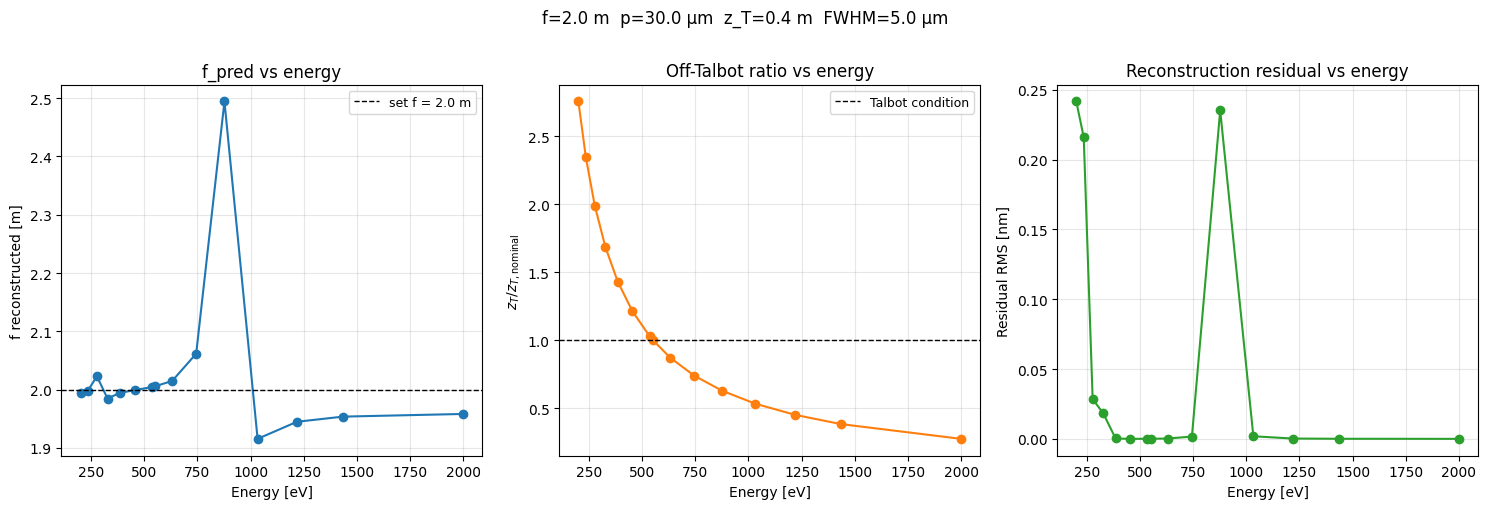

In [141]:
# ── Plot: f_pred, off-Talbot ratio, residual vs energy ────────────────────

e_arr        = np.array(e_values)
wavelength_e = 1.23984e-6 / e_arr
z_T_nominal  = grating_pitch_m**2 / wavelength_e
talbot_ratio = z_T_m / z_T_nominal

f_pred_e   = np.array([-e_results[e]['result']['f_pred']      for e in e_values])
rms_e      = np.array([ e_results[e]['result']['rms_resid_nm'] for e in e_values])
r_dc_e     = np.array([ e_results[e]['result']['dc_carrier_ratio'] for e in e_values])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: f_pred vs E ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(e_arr, f_pred_e, 'o-', lw=1.5)
ax.axhline(f_m, color='k', lw=1, ls='--', label=f'set f = {f_m} m')
ax.set_xlabel('Energy [eV]'); ax.set_ylabel('f reconstructed [m]')
ax.set_title('f_pred vs energy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 2: off-Talbot ratio vs E ───────────────────────────────────────
ax = axes[1]
ax.plot(e_arr, talbot_ratio, 'o-', lw=1.5, color='C1')
ax.axhline(1.0, color='k', lw=1, ls='--', label='Talbot condition')
ax.set_xlabel('Energy [eV]'); ax.set_ylabel(r'$z_T / z_{T,\mathrm{nominal}}$')
ax.set_title('Off-Talbot ratio vs energy')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Panel 3: residual RMS vs E ────────────────────────────────────────────
ax = axes[2]
ax.plot(e_arr, rms_e, 'o-', lw=1.5, color='C2')
ax.set_xlabel('Energy [eV]'); ax.set_ylabel('Residual RMS [nm]')
ax.set_title('Reconstruction residual vs energy')
ax.grid(True, alpha=0.3)

plt.suptitle(f'f={f_m} m  p={grating_pitch_m*1e6:.1f} µm  '
             f'z_T={z_T_m} m  FWHM={source_fwhm_m*1e6:.1f} µm', y=1.01)
plt.tight_layout(); plt.show()

In [152]:
mono_E_eV = 9600.0

z_T_m = 0.3    # grating → detector [m]

grating_pitch_ideal_m = np.sqrt(z_T_m * (1.23984e-6 / mono_E_eV))
print(f"Grating pitch for Talbot condition at {mono_E_eV:.0f} eV: ",
      f"{grating_pitch_ideal_m*1e6:.3f} µm")

Grating pitch for Talbot condition at 9600 eV:  6.225 µm


# CLOSING REMARKS

Trials for reconstructing the correct aberrations are still not successful. 

We kinda analyze it with math, but have not found a good way to overcome the barrier. 